In [1]:
import numpy as np
from sympy import var
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
from numba import jit
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
plt.rc('font', size=18) 

from scipy.interpolate import interp1d
from scipy.integrate import odeint

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

In [3]:
from classy import Class

#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

In [4]:
def get_avg_dist(obs_pos):
    """create x_c to integrate over - lets say it's a 1000 MPc/h (128x128x128) grid situated at (x,y,z)"""
    Nside_theory= 128
    conf_space = np.linspace(0,1000,Nside_theory)
    x_unorm , y_unorm , z_unorm = np.meshgrid(conf_space-obs_pos[0], conf_space-obs_pos[1], conf_space-obs_pos[2],indexing='ij') 
    conf_norm = np.sqrt(x_unorm**2 + y_unorm**2 + z_unorm**2) # make a unit vector - normalise
    ds = np.where(conf_norm==0,1,conf_norm)
    return 1/np.mean(1/ds**3)

print(get_avg_dist((500,500,200))**(1/3))


#table of b_e and Q from doppler paper
euclid_data = np.loadtxt('snr_surveyparams.txt')

255.01426105201142


## define all derivatives wrt to comoving distance

$\frac{df}{d ln(d)}=\frac{d d}{d ln(d)}\frac{dz}{dd}\frac{df}{dz}=d \times(1/\frac{dd}{dz})\frac{df}{dz}$

In [5]:
class CosmologicalFunctions:
    def __init__(self,cosmo,survey='EUCLID'):
        """
            take in Class and spit out stuff and create bunch of functions needed to compute bispectrum
        """
        self.cosmo = cosmo
        baLCDM = cosmo.get_background()

        f_cl = baLCDM['gr.fac. f']
        D_cl = baLCDM['gr.fac. D']
        z_cl = baLCDM['z']
        H_cl = baLCDM['H [1/Mpc]']
        xi_cl = baLCDM['comov. dist.']
        t_cl = baLCDM['conf. time [Mpc]']
        
        self.z_cl = z_cl#save for later
        self.Om_0 = cosmo.get_current_derived_parameters(['Omega_m'])['Omega_m']
        self.h = cosmo.get_current_derived_parameters(['h'])['h']
        
        #define functions and add in h
        self.H_c = interp1d(z_cl,H_cl*(1/(1+z_cl))/self.h,kind='cubic') # now in h/Mpc!
        self.dH_c = interp1d(z_cl,np.gradient(H_cl*(1/(1+z_cl))/self.h,z_cl),kind='cubic') # derivative wrt z
        self.ddH_c = interp1d(z_cl,np.gradient(self.dH_c(z_cl),z_cl),kind='cubic') # second derivative wrt z
        self.comoving_dist = interp1d(z_cl,xi_cl*self.h,kind='cubic') # just use class background as quick
        self.d_to_z = interp1d(xi_cl*self.h,z_cl,kind='cubic') # useful to map other way
        self.f_intp = interp1d(z_cl,f_cl,kind='cubic')#get f #omega_mz = Omega_m *(1+zt)**3 /(Omega_m *(1+zt)**3 + Omega_l)
        self.D_intp = interp1d(z_cl,D_cl,kind='cubic')
        self.dD_dz = interp1d(z_cl,np.gradient(D_cl,z_cl),kind='cubic')
        self.conf_time = interp1d(z_cl,self.h*t_cl,kind='cubic')#convert between the two
        #misc
        self.c = 2.99792*10**5 #km/s
        self.H0 = 100/self.c #[h/Mpc]
        self.Om = lambda xx: self.Om_0 * (self.H0**2 / self.H_c(xx)**2) * (1+xx)
        
        #define bias stuff
        if survey=='EUCLID':
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
        elif survey=='BGS':
            self.b_1 =  lambda xx: 1.34/self.D_intp(xx)
        else:
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
            
        self.g_2 = lambda xx: -(2/7)*(self.b_1(xx)-1)# 0.524-0.547*self.b_1(xx)+0.046*self.b_1(xx)**2#
        self.b_2 = lambda xx: 0.412 - 2.143*self.b_1(xx) +0.929*self.b_1(xx)**2 + 0.008*self.b_1(xx)**3 + 4/3 * self.g_2(xx)#-0.1*np.sqrt(1+xx)#
        
        self.z_samps = np.linspace(0.05, 10, 10000)#defined over appropiate range for numerical derivs
        
        #get derivs of these redshift dependent functions
        func_deriv_list = self.lnd_derivatives([self.b_1,self.b_2,self.g_2,self.f_intp,self.D_intp])
        self.b1_d,self.b2_d,self.g2_d,self.f_d,self.D_d = func_deriv_list
        func_second_deriv_list = self.lnd_derivatives(func_deriv_list)
        self.b1_dd,self.b2_dd,self.g2_dd,self.f_dd,self.D_dd = func_second_deriv_list
        
        if survey=='EUCLID':
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey= lambda xx: -7.29 + 0.470*xx + 1.17*xx**2 - 0.290*xx**3
            self.Q_survey = lambda xx: 0.583 + 2.02*xx - 0.568*xx**2 + 0.0411*xx**3
            #self.v_z = lambda zz: 8.85*zz**1.65 *np.exp(-0.777*zz)
            self.n_g = lambda zz: 0.0193*zz**(-0.0282) *np.exp(-2.81*zz)

        elif survey=='BGS':
            self.z_survey = np.linspace(0.05,0.6)
            #z_tab = [0.05,0.15,0.25,0.35,0.45,0.55] #not used as we just use bin_volume
            #v_tab = [0.04,0.23,0.58,1.04,1.55,2.08] #Gpc^3
            #self.v_z = interp1d(z_tab,v_tab)
            self.n_g = lambda zz: 0.023*zz**(-0.471)*np.exp(-5.17*zz)-0.002 #fitting from Maartens
            self.be_survey= lambda xx: -2.25 - 4.02*xx + 0.318*xx**2 - 14.6*xx**3
            self.Q_survey = lambda xx: 0.282 + 2.36*xx + 2.27*xx**2 + 11.1*xx**3
        elif survey == 'model1':
            self.z_survey = np.linspace(0.9,1.8) 
            z_euclid = euclid_data[:,0]
            self.be_survey = interp1d(z_euclid, euclid_data[:,1])
            self.Q_survey = interp1d(z_euclid,  euclid_data[:,2])
        else:
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey = lambda xx: 0*xx
            self.Q_survey = lambda xx:  0*xx #+ 2/5
            
    def get_class_powerspectrum(self,kk,zz=0): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk_lin(ki, zz) for ki in kk*self.h])*h**3
    
    def get_Pk_NL(self,zz=0): # for halofit non-linear power spectrum
        k = np.logspace(-5, np.log10(k_max), num=1000)
        pk_nl = interp1d(k,np.array([self.cosmo.pk(ki, zz) for ki in k*self.h])*h**3)
        return pk_nl
    
    def get_class_powerspectrumNL(self,kk,zz): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk(ki, zz) for ki in kk*self.h])*h**3

    def get_pkinfo_z(self,k,z):
        Plin = self.get_class_powerspectrum(k,0)#just always get present day power spectrum
        Pk = interp1d(k,Plin)#get linear power spectrum
        self.Pk = Pk
        Pk_d = interp1d(k,np.gradient(Plin,k))
        Pk_dd = interp1d(k,np.gradient(Pk_d(k),k))
        return Pk,Pk_d,Pk_dd
    
    def Pk_phi(self,k,cosmo=cosmo, k0=0.05, units=True):
        """Power spectrum of the Bardeen potential Phi in the matter-dominated era - k in units of h/Mpc.
        """
        k_pivot = k0/h
        resp = (9.0/25.0) * cosmo.get_current_derived_parameters(['A_s'])['A_s'] * (k/k_pivot)**(cosmo.get_current_derived_parameters(['n_s'])['n_s'] - 1.0)

        if units:
            resp *= 2*np.pi**2.0/k**3.0    #[Mpc/h]^3

        return resp

    def M(self,k, z):
        """The scaling factor between the primordial scalar power spectrum and the late-time matter power spectrum
        """
        return np.sqrt(self.D_intp(z)**2 *self.Pk(k) / self.Pk_phi(k) )

    def solve_second_order_KC(self):
        c = 2.99792*10**5 #km/s
        def F_func(u,zz): # so variables are F and H and D
            f,fd = u # unpack u vector
            D_zz = self.D_intp(zz)
            return [fd,(-self.H_c(zz)*self.dH_c(zz)*(1+zz)**2 *fd + ((3*(self.H0)**2 * self.Om_0 *(1+zz))/(2))*(f+D_zz**2))/(self.H_c(zz)**2 *(1+zz)**2)]
        
        odeint_zz = np.linspace(20,0.05,int(1e+5))# so z=20 should be pretty much matter dominated

        #set initial params for F
        F0 = [(3/7)*self.D_intp(odeint_zz[0])**2,(3/7)*2*self.D_intp(odeint_zz[0])*self.dD_dz(odeint_zz[0])]
        sol1 = odeint(F_func,F0,odeint_zz)
        K = (sol1[:,0]/self.D_intp(odeint_zz)**2)
        C = sol1[:,1]/(2*self.D_intp(odeint_zz)*self.dD_dz(odeint_zz))
        self.K_intp = interp1d(odeint_zz,K,kind='cubic')
        self.C_intp = interp1d(odeint_zz,C,kind='cubic')
    
    def lnd_derivatives(self,functions_to_differentiate,z_range= [0]):
        """
            calculates derivatives of a list of functions wrt log comoving dist numerically
        """
        if len(z_range) == 1:
            z_range= self.z_samps

        # Store first derivatives in a list
        function_derivatives = []

        for func in functions_to_differentiate:
            # Calculate numerical derivatives of the function with respect to ln(d)
            derivative_func = interp1d(z_range, np.gradient(func(z_range), np.log(self.comoving_dist(z_range))))
            function_derivatives.append(derivative_func)

        return function_derivatives

    def get_params(self,k1,k2,theta,zz,nonlinear=False):
        """
            return arrays of redshift and k dependent parameters
        """
        self.solve_second_order_KC()#get K and C
        
        k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))#get k3 from triangle condition
        k3 = np.where(k3==0,1e-3,k3)
        
        k = np.logspace(-5, np.log10(k_max), num=1000)
        Pk,Pk_d,Pk_dd = self.get_pkinfo_z(k,0)
        Pk1 = Pk(k1)
        Pk2 = Pk(k2)
        Pk3 = Pk(k3)

        Pkd1 = Pk_d(k1)
        Pkd2 = Pk_d(k2)
        Pkd3 = Pk_d(k3)

        Pkdd1= Pk_dd(k1)
        Pkdd2 = Pk_dd(k2)
        Pkdd3 = Pk_dd(k3)
        
        if nonlinear:
            Pk_NL = self.get_Pk_NL(zz=0)
            Pk1 = Pk_NL(k1)
            Pk2 = Pk_NL(k2)
            Pk3 = Pk_NL(k3)
        #redshift dependendent terms
        d = self.comoving_dist(zz)
        
        K = 3/7
        C = 3/7
        if False:
            K = self.K_intp(zz)
            C = self.C_intp(zz)

        f = self.f_intp(zz)
        D1 = self.D_intp(zz)
        b1 = self.b_1(zz)
        b2 = self.b_2(zz)
        g2 = self.g_2(zz)
        return k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2

    def get_derivs(self,zz):
        #1st deriv
        fd = self.f_d(zz)
        Dd = self.D_d(zz)
        gd2 = self.g2_d(zz)
        bd2 = self.b2_d(zz)
        bd1 = self.b1_d(zz)
        #2nd deriv
        fdd = self.f_dd(zz)
        Ddd = self.D_dd(zz)
        gdd2 = self.g2_dd(zz)
        bdd2 = self.b2_dd(zz)
        bdd1 = self.b1_dd(zz)
        return fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
    
    def get_PNGparams(self,fNL,zz,k1,k2,k3):
        delta_c = 1.686
        bL10 = lambda xx: self.b_1(xx) - 1
        bL20 = lambda xx: self.b_2(xx) - (8/21)*bL10(xx)

        bL01 = lambda xx: 2*delta_c*fNL*bL10(xx)
        bL11 = lambda xx: 2*fNL*(delta_c*bL20(xx)-bL10(xx))
        bL02 = lambda xx: 4*fNL**2 * delta_c*(delta_c*bL20(xx)-2*bL10(xx))

        bE01 = bL01
        bE11 = lambda xx: bL01(xx) + bL11(xx)
        bE02 = bL02

        alphak1 = self.M(k1, 0)
        alphak2 = self.M(k2, 0)
        alphak3 = self.M(k3, 0)
        return fNL,1*bE01(zz),1*bE11(zz),0*bE02(zz),alphak1,alphak2,alphak3
    
    def get_beta_funcs(self,zz):
        """
            Function that relies on biases and functions defined above to return beta coefficients
            from paper 1711.01812v4
        """
        #these derivs here are wrt to conformal time so we convert to derivs wrt to z
        #d/dt = d a/dt d/da = a H dz/da d/dz =  -(1+z) H d/dz # everything here is conformal both t and H
        #d^2/d^2 t = (1+z)^2 H^2 d^2/d z^2 + H(1+z)(H+(1+z)H')d/dz
        
        dQ_dz = interp1d(self.z_survey,np.gradient(self.Q_survey(self.z_survey),self.z_survey))
        dbe_dz = interp1d(self.z_survey,np.gradient(self.be_survey(self.z_survey),self.z_survey))
        db1_dz = interp1d(self.z_samps,np.gradient(self.b_1(self.z_samps),self.z_samps))
        
        dH_dt = lambda xx: -(1+xx)*self.H_c(xx)*self.dH_c(xx)
        dH_dt2 = lambda xx: (1+xx)**2 *self.H_c(xx)**2 *self.ddH_c(xx)+self.H_c(xx)*(1+xx)*(self.H_c(xx)+(1+xx)*self.dH_c(xx))*self.dH_c(xx)#should just check with doing it numerically as is easier
        #self.dH22 = interp1d(self.z_cl,np.gradient(dH_dt(self.z_cl),self.conf_time(self.z_cl)))
        self.dH_dt = dH_dt                   
        dQ_dt = lambda xx: -(1+xx)*self.H_c(xx)*dQ_dz(xx)
        dbe_dt = lambda xx: -(1+xx)*self.H_c(xx)*dbe_dz(xx)#0*xx-1.6*1e-4
        db1_dt = lambda xx: -(1+xx)*self.H_c(xx)*db1_dz(xx)  
        self.Q = self.Q_survey
        self.b_e = self.be_survey

        partdQ=0
        partdb1=0
        
        #from 1st order petrubation theory
        self.gr1 = lambda xx: self.H_c(xx)*self.f_intp(xx)*(self.b_e(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2)
        self.gr2 = lambda xx: self.H_c(xx)**2 *(self.f_intp(xx)*(3-self.b_e(xx))+ (3/2)*self.Om(xx)*(2+self.b_e(xx)-self.f_intp(xx)-4*self.Q(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2))
        self.grd1 = self.lnd_derivatives([self.gr1],self.z_survey)[0]#get derivative for 1st order coef
        
        beta = np.empty(20,dtype=object)
        beta[6] = lambda xx: self.H_c(xx)**2 * ((3 / 2) * self.Om(xx) * (2 - 2 * self.f_intp(xx)+ self.b_e(xx) - 4 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[7] = lambda xx: self.H_c(xx)**2 * (self.f_intp(xx)* (3 - self.b_e(xx)))
        beta[8] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx) * (2 - self.f_intp(xx) - 2 * self.Q(xx)) + self.f_intp(xx)**2 * (4 + self.b_e(xx) - self.b_e(xx)**2 + 4 * self.b_e(xx) * self.Q(xx) - 6 * self.Q(xx) - 4 * self.Q(xx)**2 + 4 * partdQ + 4 * (dQ_dt(xx) / self.H_c(xx)) -(dbe_dt(xx) / self.H_c(xx)) - (2 / (self.comoving_dist(xx)**2 * self.H_c(xx)**2)) * (1 - self.Q(xx) + 2 * self.Q(xx)**2 - 2 * partdQ) - (2 / (self.comoving_dist(xx) * self.H_c(xx))) * (3 - 2 * self.b_e(xx) + 2 * self.b_e(xx) * self.Q(xx) - self.Q(xx) - 4 * self.Q(xx)**2 + ((3 * dH_dt(xx)) / (self.H_c(xx)**2)) * (1 - self.Q(xx)) + 4 * partdQ + 2 * (dQ_dt(xx) / self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((3 * dH_dt(xx)) / (self.H_c(xx)**2))) + (dH_dt2(xx) / self.H_c(xx)**3)))
        beta[9] = lambda xx: self.H_c(xx)**2 * ( -(9 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[10] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx))
        beta[11] = lambda xx: self.H_c(xx)**2 * ( (3/2 ) * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) + 3 * self.Om(xx) * self.f_intp(xx)- self.f_intp(xx)**2 * (-1 + self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 + self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[12] = lambda xx: self.H_c(xx)**2 * ( -3 * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) - self.f_intp(xx)* ( self.b_1(xx) * (self.f_intp(xx)- 3 + self.b_e(xx)) + (db1_dt(xx) / self.H_c(xx)) ) + (3 / 2) * self.Om(xx) * (self.b_1(xx) * (2 + self.b_e(xx) - 4 * self.Q(xx) - 2 * ((1 - self.Q(xx))/(self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) ) + db1_dt(xx) /self.H_c(xx) + 2 * (2 - (1 / (self.comoving_dist(xx) * self.H_c(xx))) ) * partdb1 ) )    
        beta[13] = lambda xx: self.H_c(xx)**2 * (( (9 / 4) * self.Om(xx)**2 + (3 / 2) * self.Om(xx) * self.f_intp(xx)* (1 - (2 * self.f_intp(xx)) + 2 * self.b_e(xx) - 6 * self.Q(xx) - ((4 * (1 - self.Q(xx)))/(self.comoving_dist(xx) * self.H_c(xx))) - ((3 * dH_dt(xx)) / self.H_c(xx)**2) ) ) + ( self.f_intp(xx)**2 * (3 - self.b_e(xx)) ) )
        beta[14] = lambda xx: self.H_c(xx) * ( - (3 / 2) * self.Om(xx) * self.b_1(xx))
        beta[15] = lambda xx: self.H_c(xx) * 2 * self.f_intp(xx)**2
        beta[16] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_1(xx) * (self.f_intp(xx)+ self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)) + (db1_dt(xx) / self.H_c(xx)) + 2 * (1 - (1 / (self.comoving_dist(xx) * self.H_c(xx)))) * partdb1 ))
        beta[17] = lambda xx: self.H_c(xx) * (- (3 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[18] = lambda xx: self.H_c(xx) * ( (3 / 2) * self.Om(xx) * self.f_intp(xx) - self.f_intp(xx)**2 * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((4 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) + (3 * dH_dt(xx)/ self.H_c(xx)**2)) )
        beta[19] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))

        self.beta = beta
        
        #get betad - derivatives wrt to ln(d)        # these are limited in range to euclid currently
        betad = np.empty(20,dtype=object)
        betad[14:20] = np.array(self.lnd_derivatives(beta[14:20],self.z_survey),dtype=object)#14-19

        self.betad = betad
        all_betas = np.concatenate((np.array([self.gr1,self.gr2,self.grd1]),beta[6:],betad[14:20]))
        return [all_betas[i](zz) for i in range(len(all_betas))]


In [6]:
def index_tuple(tup,index_cmd):
    """index the array in a tuple"""
    indexed_list = []
    for i,item in enumerate(tup):
        if np.array(item).size>1:
            indexed_list.append(item[index_cmd])
        else:
            indexed_list.append(item)
    return indexed_list        
#index_tuple(params,(slice(1,4),3,3))

In [7]:
zz=1
k1=0.04#np.linspace(0.01,0.1)#
k2=k1/2
theta = 2*np.pi/3#np.pi#np.linspace(0,np.pi,200)#

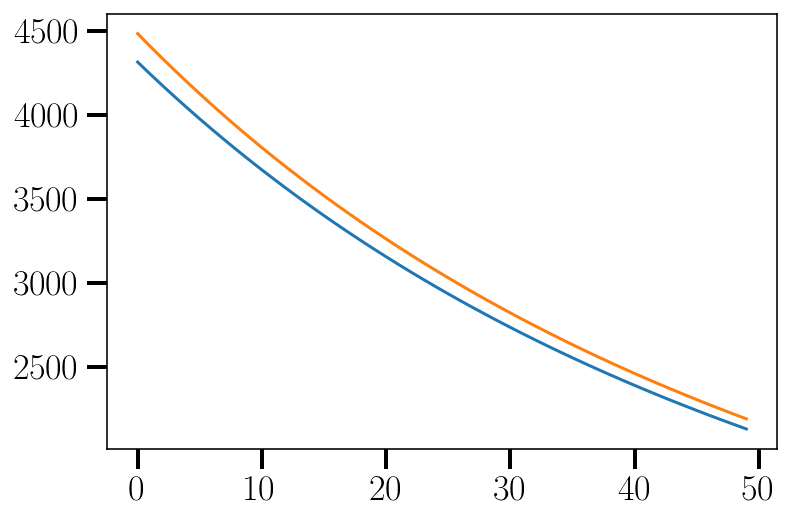

In [8]:
z_plot = np.linspace(0.9,1.8)
plt.plot(np.array([cosmo.pk_lin(0.1, zi) for zi in z_plot]))
plt.plot(np.array([cosmo.pk(0.1, zi) for zi in z_plot]))

In [9]:
cosmo_functions = CosmologicalFunctions(cosmo)
params = cosmo_functions.get_params(k1,k2,theta,zz)
k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
derivs = cosmo_functions.get_derivs(zz)


PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)
betas = cosmo_functions.get_beta_funcs(zz)
gr1,gr2,grd1,beta6,beta7,beta8,beta9,beta10,beta11,beta12,beta13,beta14,beta15,beta16,beta17,beta18,beta19,betad14,betad15,betad16,betad17,betad18,betad19 = betas

In [10]:
print(cosmo_functions.comoving_dist(0.5))
#print(cosmo_functions.d_to_z(1200))


1317.5841066352712


In [11]:
v_z = lambda zz: 8.85*zz**1.65 *np.exp(-0.777*zz)
n_g = lambda zz: 0.0193*zz**(-0.0282) *np.exp(-2.81*zz)
kmax = lambda zz: 0.1 *h*(1+zz)**(2/(2+n_s))

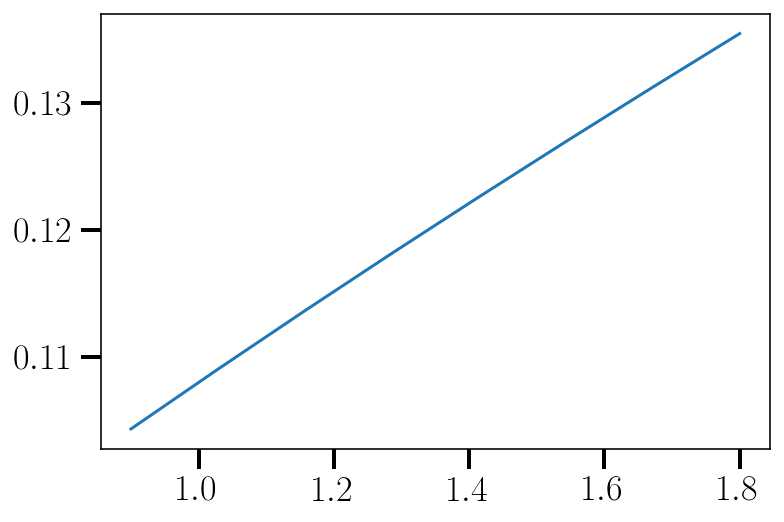

In [12]:
zz_arr = np.linspace(0.9,1.8,8)
plt.plot(zz_arr,kmax(zz_arr))

In [13]:
chi = 2*np.pi/0.005
print(cosmo_functions.d_to_z(chi))

0.4734293752731371


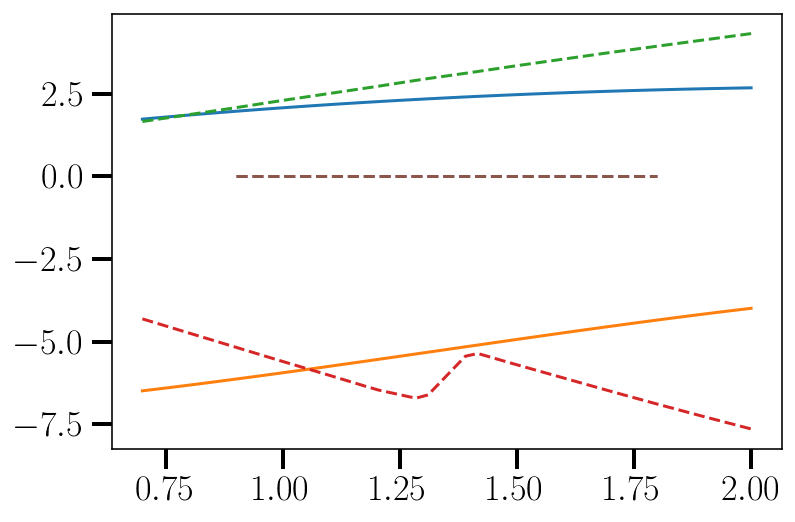

In [14]:
z_plot = np.linspace(0.7,2)
#plt.plot(z_plot,cosmo_functions.b_1(z_plot))
#plt.plot(z_plot,cosmo_functions.b_2(z_plot))
#plt.plot(z_plot,cosmo_functions.g_2(z_plot))

cosmo_functions = CosmologicalFunctions(cosmo)
plt.plot(z_plot,cosmo_functions.Q_survey(z_plot))
plt.plot(z_plot,cosmo_functions.be_survey(z_plot))
cosmo_functions = CosmologicalFunctions(cosmo,'model1')
plt.plot(z_plot,cosmo_functions.Q_survey(z_plot),'--')
plt.plot(z_plot,cosmo_functions.be_survey(z_plot),'--')
cosmo_functions = CosmologicalFunctions(cosmo,'DESI')
plt.plot(cosmo_functions.z_survey,cosmo_functions.Q_survey(cosmo_functions.z_survey),'--')
plt.plot(cosmo_functions.z_survey,cosmo_functions.be_survey(cosmo_functions.z_survey),'--')

if False:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    z_euclid = np.linspace(0.9,1.8,300)
    #axs[0].plot(z_euclid,cosmo_functions.beta[13](z_euclid))
    #axs[0].plot(z_euclid,cosmo_functions.beta[12](z_euclid))
    axs[0].plot(z_euclid,cosmo_functions.beta[11](z_euclid))
    #axs[0].plot(z_euclid,cosmo_functions.beta[10](z_euclid))
    #axs[0].plot(z_euclid,cosmo_functions.beta[9](z_euclid))
    axs[0].plot(z_euclid,cosmo_functions.beta[8](z_euclid))
    #axs[0].plot(z_euclid,cosmo_functions.beta[7](z_euclid))
    #axs[0].plot(z_euclid,cosmo_functions.beta[6](z_euclid))


    axs[1].plot(z_euclid,cosmo_functions.beta[14](z_euclid))
    axs[1].plot(z_euclid,cosmo_functions.beta[15](z_euclid))
    axs[1].plot(z_euclid,cosmo_functions.beta[16](z_euclid))
    axs[1].plot(z_euclid,cosmo_functions.beta[17](z_euclid))
    axs[1].plot(z_euclid,cosmo_functions.beta[18](z_euclid))
    axs[1].plot(z_euclid,cosmo_functions.beta[19](z_euclid))
    #axs[1].plot(z_euclid,cosmo_functions.betad[16](z_euclid))

    plt.tight_layout()
    plt.show()

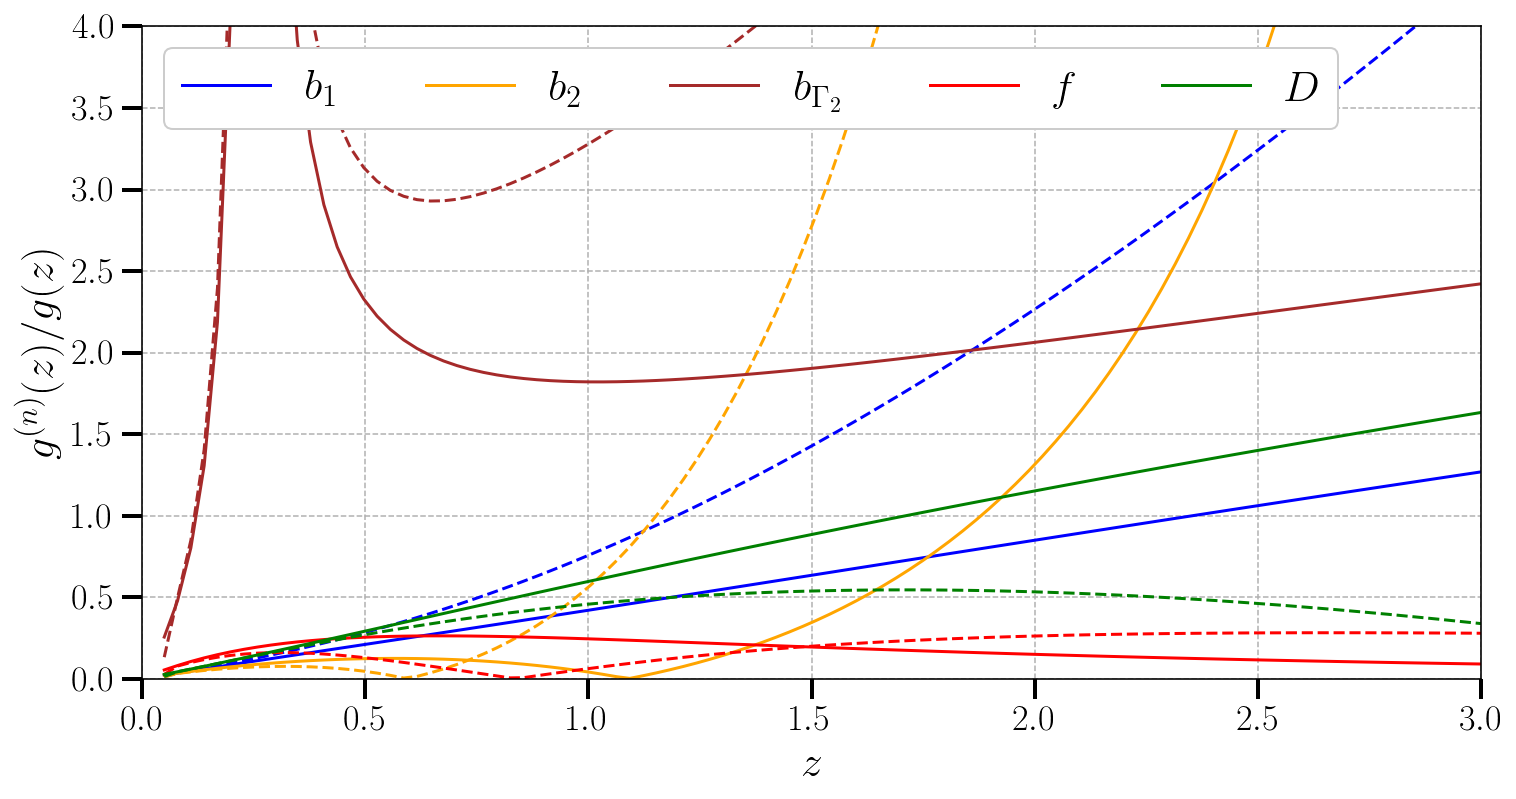

In [15]:
#plot ratio of derivates of biases to normal term which repersents the rough size of derivative terms to wide-angle terms
plt.figure(figsize=(12,6))
z_plot = np.linspace(0.05,3,100)

plt.plot(z_plot,np.abs(cosmo_functions.b1_d(z_plot)/cosmo_functions.b_1(z_plot)),color='blue',label='$b_1$')
plt.plot(z_plot,np.abs(cosmo_functions.b1_dd(z_plot)/cosmo_functions.b_1(z_plot)),'--',color='blue')

plt.plot(z_plot,np.abs(cosmo_functions.b2_d(z_plot)/cosmo_functions.b_2(z_plot)),color='orange',label='$b_2$')
plt.plot(z_plot,np.abs(cosmo_functions.b2_dd(z_plot)/cosmo_functions.b_2(z_plot)),'--',color='orange')

plt.plot(z_plot,np.abs(cosmo_functions.g2_d(z_plot)/cosmo_functions.g_2(z_plot)),color='brown',label='$b_{\Gamma_2}$')
plt.plot(z_plot,np.abs(cosmo_functions.g2_dd(z_plot)/cosmo_functions.g_2(z_plot)),'--',color='brown')

plt.plot(z_plot,np.abs(cosmo_functions.f_d(z_plot)/cosmo_functions.f_intp(z_plot)),color='red',label='$f$')
plt.plot(z_plot,np.abs(cosmo_functions.f_dd(z_plot)/cosmo_functions.f_intp(z_plot)),'--',color='red')

plt.plot(z_plot,np.abs(cosmo_functions.D_d(z_plot)/cosmo_functions.D_intp(z_plot)),color='green',label='$D$')
plt.plot(z_plot,np.abs(cosmo_functions.D_dd(z_plot)/cosmo_functions.D_intp(z_plot)),'--',color='green')

plt.grid(ls='--',lw=0.75)
plt.ylabel('$g^{(n)}(z)/g(z)$')
plt.xlabel('$z$')
plt.ylim(0,4)
plt.xlim(0,3)
plt.legend(ncol=5,framealpha=1)
plt.savefig('plots/derivs.png', bbox_inches='tight', dpi=400)

In [16]:
#lets define our set triangle configs

def equilateral():
    k1 = k2 = k3 = 0.01
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    return k1,k2,k3,theta

def equilateral_arr(kmin=1e-3,kmax=2e-1):
    k1 = k2 = k3 = np.linspace(kmin,kmax)
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    return k1,k2,k3,theta

def folded():
    k1 = 0.02
    k3 = k2 = k1/2
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    return k1,k2,k3,theta

def squeezed():
    k1 = k2 = 0.01
    k3 = k1/10
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    return k1,k2,k3,theta

cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'
zz = np.linspace(0.9,1.8)
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

## Import expression for each contributions

In [17]:
import sys
sys.path.append('bk_terms/')
from zeroth_order import *
from WA1 import *
from RR1 import *
from WA2_terms import *
from WA2_termstest import WA2 as WA2_
from RR2_terms import *
from RR2_terms13 import RR2 as RR2_
from WARR_terms import *
from GR_terms import *   
from GRmix_terms import *
from cov import *
from watest import *
from watest1 import *

In [18]:
from bk_terms_new.WA1 import WA1 as WA1_new
from bk_terms_new.RR1 import RR1 as RR1_new

In [19]:
from cov1 import COV as COV1 

ModuleNotFoundError: No module named 'cov1'

In [ ]:
k1=0.1
k2= 0.05
theta = np.linspace(0,np.pi,100)
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

k1,k2,k3,theta=equilateral_arr()

zz=1

#for cov
V_s = 1e+9
k_f = 2*np.pi*V_s**(-1/3)
delta_k =k_f
V123 = 8*np.pi**2*k1*k2*k3*delta_k**3
#print(V123)

cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
params_NL = cosmo_functions.get_params(k1,k2,theta,zz,nonlinear=True)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

In [ ]:
cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
zzz = np.linspace(0.05,0.6)
plt.plot(zzz,cosmo_functions.n_g(zzz))
z_tab = np.array([0.05,0.15,0.25,0.35,0.45])
N_tab = np.array([1165,3074,1909,732,120])
n_tab = N_tab*(cosmo_functions.comoving_dist(z_tab)**2 /((1+z_tab)*cosmo_functions.H_c(z_tab)))**(-1)
plt.plot(z_tab,((180/np.pi)**2 *n_tab))

In [ ]:
plt.plot(k3,np.sqrt(k_f**3 *COV.N00(params,1e+3,V123))/np.sqrt(k_f**3 *COV.N00(params_NL,1e+3,V123)))

In [ ]:
k1,k2,k3,theta = folded()
cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
zz = np.linspace(0.1,0.5)
params = cosmo_functions.get_params(k1,k2,theta,zz)

V_s = 1e+9
k_f = 2*np.pi*V_s**(-1/3)
V123 = 8*np.pi**2*k1*k2*k3

plt.plot(zz,np.sqrt(COV.N10(params,1e+3,V123)))
plt.plot(zz,np.sqrt(COV1.N10(params,1e+3,V123)))
#plt.plot(zz,10*np.sqrt(COV.N11(params,1e+3,V123)))
#plt.plot(zz,10*np.sqrt(COV1.N11(params,1e+3,V123)))


In [ ]:
k1,k2,k3,theta = equilateral_arr()
params = cosmo_functions.get_params(k1,k2,theta,zz)
#plt.plot(k3,np.sin(theta))
#plt.plot(k3,np.sqrt(COV.N00(params,1e+3,V123)))
#plt.plot(k3,np.sqrt(COV.N00(params,1e-2,V123)))
#plt.plot(k3,np.sqrt(COV1.N00(params,1e+3,V123)))
#plt.plot(k3,np.sqrt(COV.N10(params,1e+3,V123)))

#plt.plot(k3,GR0.l0(params),'--')
#plt.plot(k3,GR1.l1(params,betas).imag,'--')
#plt.plot(k3,WA1.l1(params).imag)
#plt.plot(k3,np.sqrt(COV.N10(params,1e+3,V123)/9))
#plt.plot(k3,np.sqrt(COV.N11(params,1e+3,V123)/9))
plt.yscale('log')
plt.xscale('log')

In [ ]:
class WA_RR:#for all wide separation
    def l1(params,derivs,r,s):
        return WA1.l1(params,r,s) +RR1.l1(params,derivs,r,s)
    
class WA_RR_GR:
    def l1(params,derivs,betas,r,s):
        return WA1.l1(params,r,s) +RR1.l1(params,derivs,r,s)+GR1.l1(params,betas)
    
class WA_RR_GR2:
    def l0(params,derivs,betas,r,s):
        return WA2.l0(params,r,s) +RR2.l0(params,derivs,r,s)+GR2.l0(params,betas)+WAGR.l0(params,betas,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
    
class WA_RR_GR_wa:
    def l0(params,derivs,betas,r,s):
        return WA2.l0(params,r,s) +WAGR.l0(params,betas,r,s)+WARR.l0(params,derivs,r,s)
    
class WA_RR_GR_rr:
    def l0(params,derivs,betas,r,s):
        return RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
    
class WA_RR_GR_gr:
    def l0(params,derivs,betas,r,s):
        return GR2.l0(params,betas)+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
    

In [ ]:
def tuple_bool(tup,bool_arr):
    """boolean the array in a tuple - when the array are n-dimensional"""
    indexed_list = []
    for i,item in enumerate(tup):
        if np.array(item).size>1:

            indexed_list.append(item.flatten()[bool_arr][...,None,None])
        else:
            indexed_list.append(item)
    return indexed_list

def get_args(func,params,derivs,betas,r,s):
    """
    get appropiate args for each function type
    """
    func_id = func.__name__ # get string name of func

    args = [params]
    if 'RR' in func_id:
        args.append(derivs)
    if 'GR' in func_id:
        args.append(betas)
    if 'RR' in func_id or 'WA' in func_id:
        args.append(r)
        args.append(s)
    return args

In [ ]:
com_dist = cosmo_functions.comoving_dist(0.9)
k_cut = 2*np.pi/com_dist
print(k_cut)

In [ ]:
def bin_volume(z,delta_z=0.01,f_sky=0.365): # get d volume/dz
    return f_sky*4*np.pi*cosmo_functions.comoving_dist(z)**2 *(cosmo_functions.comoving_dist(z+delta_z)-cosmo_functions.comoving_dist(z-delta_z))


#lets take average value integrated over redhsift bin 
def bin_average(func,zmin,zmax,fargs,l,V123=0,s123=0,cosmo_functions=cosmo_functions,func2=None,SN=True):
    """
    Returns average for a function over a redshift bin - uses gauss legendre integration
    could be sped up like numeric integration function by using numpy broadcasting and not using set scipy func
    """

    k1,k2,theta,r,s = fargs 
    k1 = k1[...,None]
    k2 = k2[...,None]
    theta = theta[...,None]
    
    funcl = getattr(func,"l"+str(l)) 
    if func2 != None:
        func2l = getattr(func2,"l"+str(l))
        
    def integrand(zz):
        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)
        args = get_args(func,params,derivs,betas,r,s)
        
        return bin_volume(zz)*funcl(*args)
    
    def integrandSN(zz,s123): # this doesnt really make sense tbh -look at the plot of the covariance

        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)
        args = get_args(func,params,derivs,betas,r,s)
        
        bk = funcl(*args)
        if func2 != None:  # for non-diagonal fisher terms
            args2 = get_args(func2,params,derivs,betas,r,s)
            bk2 = func2l(*args2)
        else:
            bk2 = bk
        
        bkbk = bk*np.conjugate(bk)
        nbar = cosmo_functions.n_g(zz)#get density [h/Mpc]^3

        s123 = s123[...,None]
        V123_ = V123[...,None]
        
        covbk = ((4*np.pi)**2 *s123*cov(params,nbar,V123_)/(2*l+1)**2)
        
        return bin_volume(zz)*bkbk/covbk
    
    def plotc(zz,s123):

        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)

        nbar = cosmo_functions.n_g(zz)#get density [h/Mpc]^3

        s123 = s123[...,None]
        V123_ = V123[...,None]
        
        covbk = cov(params,nbar,V123_)#((4*np.pi)**2 *s123*cov(params,nbar,V123_)/(2*l+1)**2)
        print(covbk.shape)
        plt.plot(zz,np.sum(1/covbk,axis=(0,1,2)))

        
    if SN:
        cov_lm = f'N{l}{m}'
        # Get the method from the class
        cov = getattr(COV, cov_lm)
        bk_bin_tmp, _ = scipy.integrate.fixed_quad(integrandSN,zmin,zmax,args=([s123]),n=10)
        ff = plotc(np.linspace(zmin,zmax,5),s123)
    else:
        bk_bin_tmp, _ = scipy.integrate.fixed_quad(integrand,zmin,zmax,n=10)
    
    norm, _ = scipy.integrate.fixed_quad(bin_volume,zmin,zmax,n=10)
    return bk_bin_tmp/norm

r=0;s=0;
fargs = k1,k2,theta,r,s

zz= 1.35
cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
#aas = bin_average(WA1,0.9,1.8,fargs,1,cosmo_functions=cosmo_functions,SN=False)
#test = WA1.l1(params,r,s)

#plot ratio of bin middle to bin averaged
#plt.plot(aas.imag/test.imag)
#plt.plot(aas.imag,'--')
#plt.yscale('log')

In [ ]:
if True:
    snr_GR1 = {}
    snr_dip = {}
    snr_dip_x1 = {}
    snr_dip_x2 = {}
    snr_dip_COM = {}

z_cen={}

In [89]:
# int lets compute
def SNR(z_bin,func,l,m,r=0,s=0,cosmo_functions=cosmo_functions,k_max=0.1,func2=None,numeric=False):
    
    z_mid = (z_bin[0]+z_bin[1])/2 + 0.0001
    delta_z = (z_bin[1]-z_bin[0])/2

    V_s = bin_volume(z_mid,delta_z)# in [Mpc/h]^3 used to get fundamental fequency

    k_f = 2*np.pi*V_s**(-1/3)
    
    delta_k = 2*k_f

    k_bin = np.arange(delta_k,k_max,delta_k)
    
    #so lets say we remove signal where WA expansion breaks... for endpoint this is at # only relevant for DESI
    #remove from low redshift point of bin
    com_dist = cosmo_functions.comoving_dist(z_mid)#k_bin[0]
    k_cut = 2*np.pi/com_dist
    k_cut_bool = np.where(k_bin>k_cut,True,False)
    
    #print(k_cut)
    #print('k_f=',k_f)

    k1,k2,k3 = np.meshgrid(k_bin,k_bin,k_bin,indexing='ij')
    V123 = 8*np.pi**2*k1*k2*k3*(delta_k/k_f)**3 #from thin bin limit
    
    # so k1,k2,k3 have shape (N,N,N) - and so to do all realted array until we sum at the end
    #create bool for closed traingles with k1>k2>k3...
    tri_bool = np.full_like(k1,False).astype(np.bool_)
    s123 = np.ones_like(k1)
    for i in range(k1.shape[0]+1):
        if np.logical_or(i == 0,k_cut_bool[i-1]==False):
            continue
        for j in range(i+1):#enforce k1>k2
            if np.logical_or(j == 0,k_cut_bool[j-1]==False):
                continue
            for k in range(i-j,j+1):# enforce k2>k3 and triangle condition |k1-k2|<k3
                if np.logical_or(k == 0,k_cut_bool[k-1]==False):
                    continue

                #for indexing-
                ii = i-1
                jj = j-1
                kk = k-1
                tri_bool[ii,jj,kk] = True
                    
                #get s123
                if i==j:
                    if j==k:
                        #tri_bool[ii,jj,kk] = False
                        s123[ii,jj,kk]=6
                    else:
                        #tri_bool[ii,jj,kk] = False
                        s123[ii,jj,kk]=2
                elif j==k:
                    #tri_bool[ii,jj,kk] = False
                    s123[ii,jj,kk]=2

    #get theta from triagle condition - this create warnings from non-closed triangles
    # Handle cases where floating-point errors might cause cos_theta to go slightly beyond [-1, 1]
    cos_theta = (k3**2 - k1**2 - k2**2)/(2*k1*k2)
    cos_theta = np.where(np.isclose(np.abs(cos_theta), 1), np.sign(cos_theta), cos_theta) #need to get rid of rounding errors
    
    #if we want to suprress warnings from invalid values we can reset cos(theta) these terms are ignored anyway
    cos_theta = np.where(np.logical_or(cos_theta < -1, cos_theta > 1), 0, cos_theta)
    theta = np.arccos(cos_theta)

    fargs = k1,k2,theta,r,s
    
    def snr_part(func,func2,l,m,s123):
        """
        returns snr contribution for given triangle
        """
        if False:
            return bin_average(func,z_bin[0],z_bin[1],fargs,l,V123=V123,s123=s123,cosmo_functions=cosmo_functions,func2=func2)
        elif False:
            cov_lm = f'N{l}{m}'
            # Get the method from the class
            cov = getattr(COV, cov_lm)
            nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3
            
            params = cosmo_functions.get_params(k1,k2,theta,z_mid)
            covar = (s123*cov(params,nbar,V123))
            bk = bin_average(func,z_bin[0],z_bin[1],fargs,l,cosmo_functions=cosmo_functions,SN=False)
            if func2 != None:  # for non-diagonal fisher terms
                bk2 = bin_average(func2,z_bin[0],z_bin[1],fargs,l,cosmo_functions=cosmo_functions,SN=False)
            else:
                bk2 = bk 
        else:
            cov_lm = f'N{l}{m}'
            # Get the method from the class
            cov = getattr(COV1, cov_lm)
            
            derivs = cosmo_functions.get_derivs(z_mid)
            betas = cosmo_functions.get_beta_funcs(z_mid)
            params = cosmo_functions.get_params(k1,k2,theta,z_mid)
            
            
            nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3

            covar = (s123*cov(params,nbar,V123))
            
            args = get_args(func,params,derivs,betas,r,s)
            
            funcl = getattr(func,"l"+str(l)) 
            if func2 != None:
                func2l = getattr(func2,"l"+str(l))

            bk = funcl(*args)
            if func2 != None:  # for non-diagonal fisher terms
                args2 = get_args(func2,params,derivs,betas,r,s)
                bk2 = func2l(*args2)
            else:
                bk2 = bk
            
            return bk*np.conjugate(bk2)/covar/(4*np.pi)**2
            
    def snr_part1(func,l,m,s123):
        """
        returns snr contribution for given triangle
        """
        cov_lm = f'N{l}{np.abs(m)}'
        # Get the method from the class
        cov = getattr(COV1, cov_lm)
        
        
        
        bk = numeric_ylm(WA.full_1,l,m,params=flat_params,dfog=False,type_=0)
        
        nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3
        covar = (s123*cov(params,nbar,V123)).flatten()[tri_bool.flatten()]

        return bk*np.conjugate(bk)/covar/(4*np.pi)**2
    
    #get snr  for all tri
    if numeric== False:
        tri_snr = snr_part(func,func2,l,m,s123)

        snr_tot = np.sum(tri_snr.flatten()[tri_bool.flatten()])
        
    else: #if we do numeric integrals - slightly more  cumbersome but work for single func
        params = cosmo_functions.get_params(k1,k2,theta,z_mid)
        flat_params = tuple_bool(params,tri_bool.flatten())
        
        tri_snr = snr_part1(func,l,m,s123)
        snr_tot = np.sum(tri_snr)

    return snr_tot

    
kmax = lambda zz: 0.1 *h*(1+zz)**(2/(2+n_s))
def get_SNR(func,l,m,cosmo_functions=cosmo_functions,r=0,s=0,func2=None,verbose=True,numeric=False,survey = 'EUCLID'):
    """
    Get SNR at several redshifts
    """
    if survey == 'EUCLID':
        z_lims=np.linspace(0.9,1.8,10)#z_lims=np.array([0.9,1.1,1.3,1.5,1.8])#
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2 
        k_max_arr = kmax(z_mid)
        cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
    else: # then DESI
        z_lims=np.linspace(0.0,0.6,7)
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2
        k_max_arr = np.ones_like(z_mid)*0.1
        cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
              
    snr = np.zeros((len(z_lims)-1),dtype=np.complex64)
    for i in tqdm(range(len(z_lims)-1)) if verbose else range(len(z_lims)-1):
        z_bin = [z_lims[i],z_lims[i+1]]
        
        snr[i] = SNR(z_bin,func,l,m,r,s,cosmo_functions=cosmo_functions,k_max=k_max_arr[i],func2=func2,numeric=numeric)
    return snr, z_mid

#snr = get_SNR(GR0,0,0)
#snr_GR2[i] =
r=0;s=0
survey = 'EUCLID'
snr_WA11_, z_mid = get_SNR(WA1,1,-1,r=r,s=s,survey=survey,numeric=True)
snr_WA1, z_mid = get_SNR(WA1,1,0,r=r,s=s,survey=survey)
#snr_GR1, z_mid = get_SNR(GR1,1,0)

#snr_WA11, z_mid = get_SNR(WA1,1,1,r=r,s=s,survey=survey)
#snr_WA1_x1, z_mid = get_SNR(WA1,1,0,r=1,s=0)
#snr_WA1_x2, z_mid = get_SNR(WA1,1,0,r=0,s=1)
#snr_WA1_COM, z_mid = get_SNR(WA1,1,0,r=1/3,s=1/3)


#snr_RR1, z_mid = get_SNR(RR1,1,0,r=r,s=s)
#snr_RR1_x1, z_mid = get_SNR(RR1,1,0,r=1,s=0)
#snr_RR1_x2, z_mid = get_SNR(RR1,1,0,r=0,s=1)
#snr_RR1_COM, z_mid = get_SNR(RR1,1,0,r=1/3,s=1/3)
                             

#snr_RR1, _ = get_SNR(RR1,1,0,r=r,s=s)


if False:
    snr_WA2 = np.sqrt(get_SNR(WA2,0,0,r=r,s=s))
    #snr_WA21 = get_SNR(WA2,0,0,r=1/3,s=1/3)
    #snr_GR2 = get_SNR(GR2,0,0)
    #snr_RR2 = get_SNR(RR2,0,0)
    
    #snr_WAGR = get_SNR(WAGR,0,0)
    #snr_RRGR = get_SNR(RRGR,0,0)
    #snr_WARR = get_SNR(WARR,0,0)
    
    #snr_all_mono = get_SNR(WA_RR_GR2,0,0)

#snr_WS1, _ = get_SNR(WA_RR,1,0,r=r,s=s)
if False:
    survey= 'EUCLID'
    survey1 = 'EUCLID'#2
    snr_GR1[survey1], z_cen[survey] = get_SNR(GR1,1,0,survey=survey)
    snr_dip[survey1], _ = get_SNR(WA_RR_GR,1,0,r=0,s=0,survey=survey)
    snr_dip_x1[survey1], _ = get_SNR(WA_RR_GR,1,0,r=1,s=0,survey=survey)
    snr_dip_x2[survey1], _ = get_SNR(WA_RR_GR,1,0,r=0,s=1,survey=survey)
    snr_dip_COM[survey1], _ = get_SNR(WA_RR_GR,1,0,r=1/3,s=1/3,survey=survey)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

In [91]:
print(np.sqrt(np.sum(snr_WA11)))
print(np.sqrt(np.sum(snr_WA1)))

(2.2221394+0j)
(2.6742384+0j)


In [78]:
print(np.sqrt(np.sum(snr_WA3)))

(1.7020417+0j)


Text(0, 0.5, 'SNR')

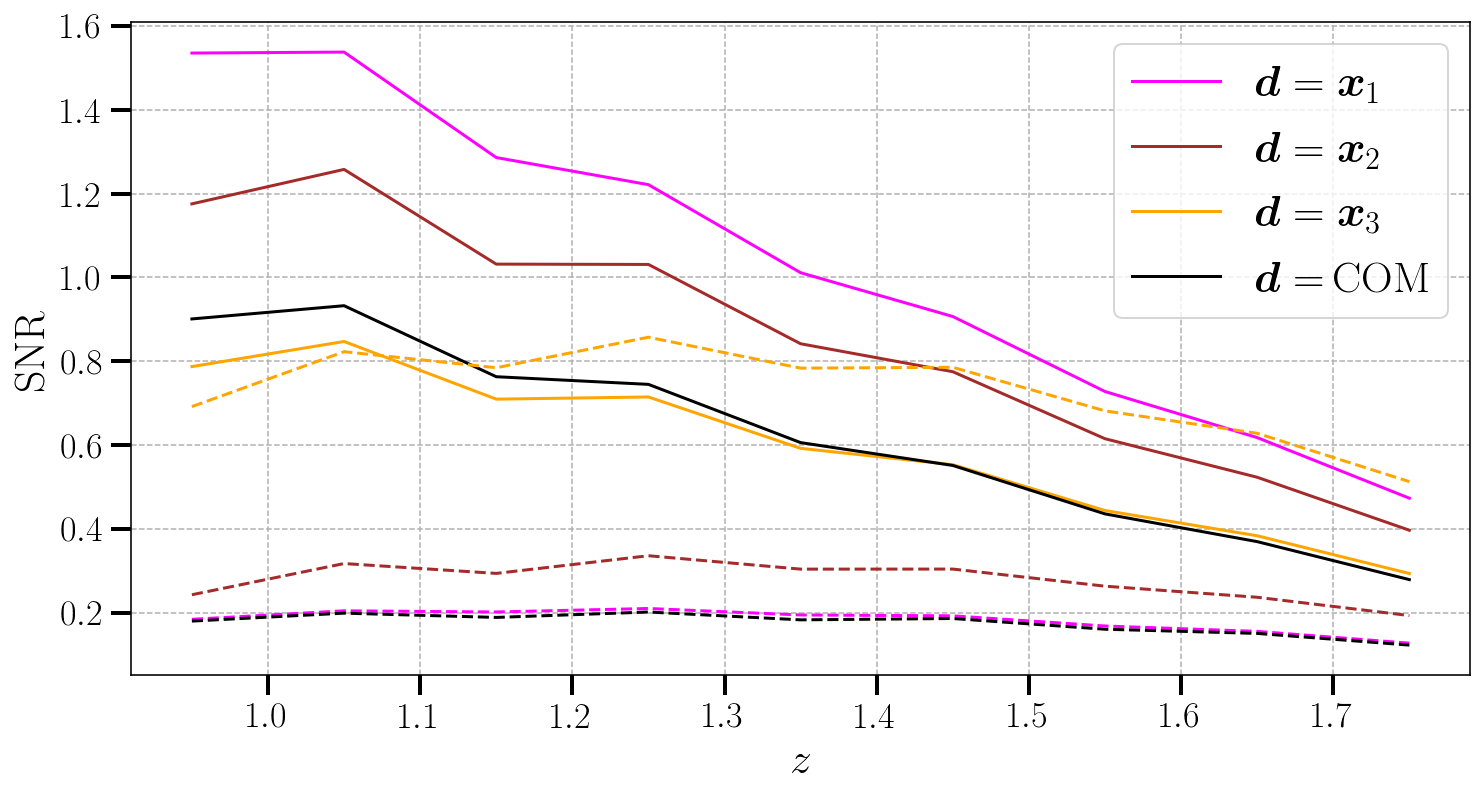

In [157]:
plt.figure(figsize=(12,6))
#plt.plot(zz,snr_GR2.real,'-',label='GR',color='green')
#plt.plot(zz,snr.real,'-',label='black',color='green')

if True:
    if True:
        #plt.plot(z_mid,np.sqrt(snr_GR1.real),'-',label='GR',color='green')
        #plt.plot(z_mid,snr_GR1_.real,'--',label='GR',color='green')
        plt.plot(z_mid,np.sqrt(snr_WA1_x1.real),'-',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$',color='magenta')
        plt.plot(z_mid,np.sqrt(snr_WA1_x2.real),'-',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$',color='brown')
        plt.plot(z_mid,np.sqrt(snr_WA1.real),'-',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$',color='orange')
        plt.plot(z_mid,np.sqrt(snr_WA1_COM.real),'-',label=r'$\boldsymbol{d}=\,$COM',color='black')
        
        
        plt.plot(z_mid,np.sqrt(snr_RR1.real),'--',color='orange')
        plt.plot(z_mid,np.sqrt(snr_RR1_x1.real),'--',color='magenta')
        plt.plot(z_mid,np.sqrt(snr_RR1_x2.real),'--',color='brown')
        plt.plot(z_mid,np.sqrt(snr_RR1_COM.real),'--',color='black')

        #plt.plot(z_mid,np.sqrt(snr_RR1.real),'-',label='RR',color='red')
        
        #plt.plot(z_mid,np.sqrt(snr_RR1_.real),'--',label='WA',color='blue')
        #plt.plot(z_mid,np.sqrt(snr_RR1_1.real),'-.',label='WA',color='blue')
        #plt.plot(z_mid,np.sqrt(snr_RR1_.real),'--',label='RR',color='red')

        #plt.plot(z_mid,np.sqrt(snr_WS1.real),'-',label='WS',color='grey')
        #plt.plot(z_mid,np.sqrt(snr_WS1_.real),'--',label='WS',color='grey')
        #plt.plot(z_mid,snr_all1.real,'--',label='all',color='black')
    
    else:
        #plt.plot(z_mid,snr_GR2.real,'-',label='GR',color='green')
        plt.plot(z_mid,snr_WA2.real,'-',label='WA',color='blue')
        plt.plot(z_mid,snr_WA21.real,'--',label='WA',color='blue')
        #plt.plot(z_mid,snr_RR2.real,'-',label='RR',color='red')
        
        #plt.plot(z_mid,snr_RRGR.real,'--',label='RRGR',color='pink')
        #plt.plot(z_mid,snr_WAGR.real,'--',label='WAGR',color='purple')
        #plt.plot(z_mid,snr_WARR.real,'--',label='WARR',color='orange')
        
        #plt.plot(z_mid,snr_all_mono.real,'--',label='all',color='black')
elif False:
    plt.plot(z_arr,snr_GR1_DESI.real,'-',label='GR',color='green')
    plt.plot(z_arr,snr_WA1_DESI.real,'-',label='WA',color='blue')
    plt.plot(z_arr,snr_RR1_DESI.real,'-',label='RR',color='red')

    plt.plot(z_arr,snr_WS1_DESI.real,'--',label='WS',color='black')
    plt.plot(z_arr,snr_all1_DESI.real,'--',label='all',color='black')

plt.xlabel('$z$')
plt.grid(ls='--',lw=0.75)
plt.legend()
#plt.xlim(0.05,0.10)
#plt.yscale('log')
plt.ylabel('SNR')
#plt.yscale('log')
#plt.ylim(0,20)

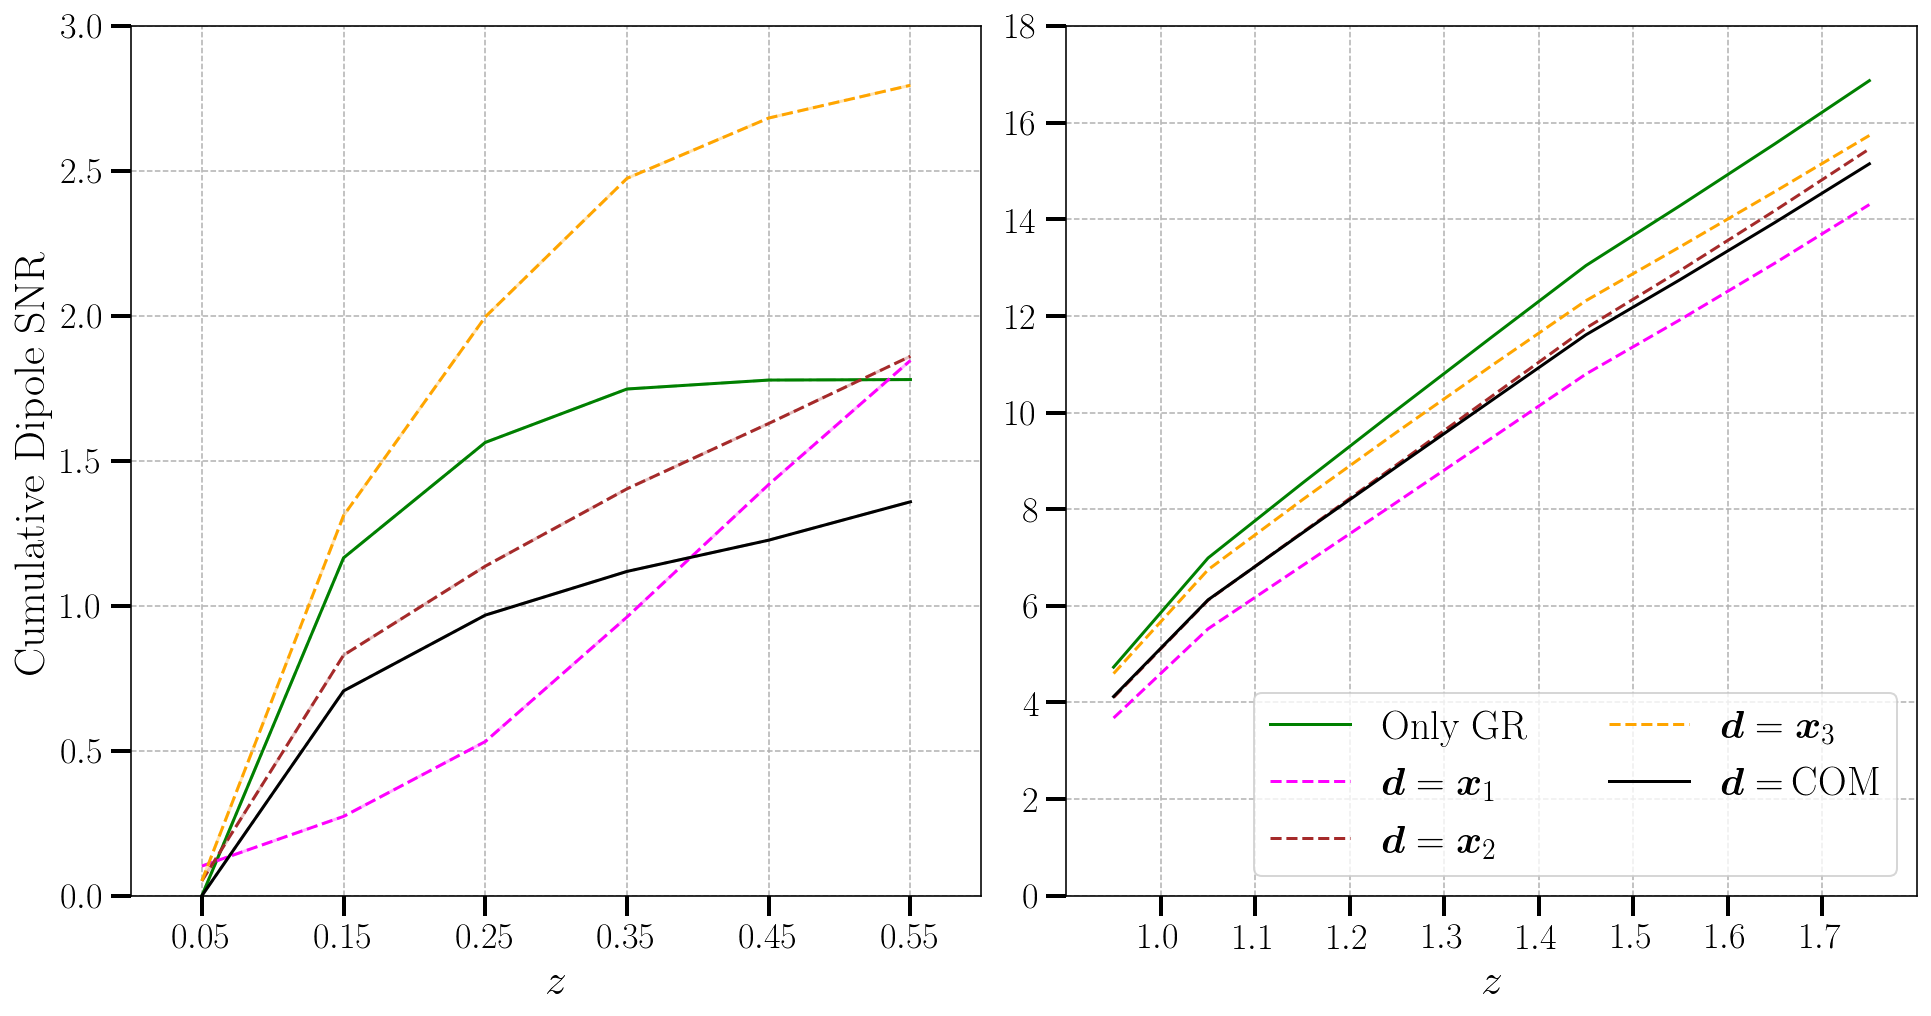

In [65]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,8))

survey='BGS'
survey1 = 'BGS'#2
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_GR1[survey].real)),'-',label='GR',color='green')
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_GR1[survey1].real)),'-.',color='green',alpha=0.3)

axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x1[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$',color='magenta')
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x1[survey1].real)),'-.',color='magenta',alpha=0.3)

axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x2[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$',color='brown')
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x2[survey1].real)),'-.',color='brown',alpha=0.3)

axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$',color='orange')
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip[survey1].real)),'-.',color='orange',alpha=0.3)

axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_COM[survey].real)),'-',label=r'$\boldsymbol{d}=\,$COM',color='black')
axs[0].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_COM[survey1].real)),'-.',color='black',alpha=0.3)


axs[0].set_xlabel('$z$')
axs[0].grid(ls='--',lw=0.75)
axs[0].set_xlim(0,0.6)
axs[0].set_xticks(np.linspace(0.05, 0.55, 6))
axs[0].set_ylabel('Cumulative Dipole SNR')


survey='EUCLID'
axs[1].plot(z_cen[survey],np.sqrt(np.cumsum(snr_GR1[survey].real)),'-',label='Only GR',color='green')
axs[1].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x1[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$',color='magenta')
axs[1].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_x2[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$',color='brown')
axs[1].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip[survey].real)),'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$',color='orange')
axs[1].plot(z_cen[survey],np.sqrt(np.cumsum(snr_dip_COM[survey].real)),'-',label=r'$\boldsymbol{d}=\,$COM',color='black')
axs[1].set_xlabel('$z$') 
axs[1].grid(ls='--',lw=0.75)
axs[1].set_xlim(0.9,1.8)
#axs[1].get_yaxis().set_tick_params(which='both', size=0, labelsize=0)
axs[1].set_xticks(np.linspace(1, 1.7, 8))
axs[1].legend(ncol=2,fontsize=20,markerscale=1)#

axs[0].set_ylim(0,3)
axs[1].set_ylim(0,18)

plt.subplots_adjust(wspace=0.1)
#plt.yscale('log')
plt.savefig('plots/SNR_los1.png', bbox_inches='tight', dpi=400)

In [233]:
snr_GR1

{'BGS': array([1.8485409e-33+0.j, 6.8540201e+00+0.j, 5.4924073e+00+0.j,
        3.0169883e+00+0.j, 4.8985735e-01+0.j, 9.1906823e-02+0.j],
       dtype=complex64),
 'EUCLID': array([26.814636 +0.j, 32.933136 +0.j, 26.301687 +0.j, 28.710896 +0.j,
        21.972075 +0.j, 20.827885 +0.j, 14.731789 +0.j, 12.0019655+0.j,
         7.6322775+0.j], dtype=complex64),
 'BGS2': array([8.390196  +0.j, 6.85402   +0.j, 5.4924073 +0.j, 3.0169883 +0.j,
        0.48985735+0.j, 0.09190682+0.j], dtype=complex64)}

In [240]:
print(np.sqrt(np.sum(snr_WA1)))
print(np.sqrt(np.sum(snr_GR1['EUCLID'])))
print(np.sqrt(np.sum(snr_RR1)))

(2.1116128+0j)
(13.853748+0j)
(2.204526+0j)


## Fisher


$$F_{ij} =\sum_k \frac{\partial B}{\partial \theta_i}C^{-1}\frac{\partial B}{\partial \theta_j}$$

In [67]:
def fisherij(func,func2,l,m,survey='EUCLID'):

    return np.sum(get_SNR(func,l,m,func2=func2,verbose=False,survey=survey)[0].real)
fish_dict = {}

In [69]:
def get_fish(l,m,survey='EUCLID'):
    """
    Add fisher matrix to dict for given l and survey
    """
    
    func_list = [WA1,RR1,GR1]
    func_list0 = [ WA_RR_GR_wa, WA_RR_GR_rr, WA_RR_GR_gr]

    N = len(func_list)#get size of matrix
    fish_mat = np.zeros((N,N))
    print("computing covariance martrix for {} ...".format(survey))
    for i in tqdm(range(N)):
        for j in range(N):
            if l == 0:
                fish_mat[i,j] =  fisherij(func_list0[i],func_list0[j],l,m,survey=survey)
            else:    
                fish_mat[i,j] =  fisherij(func_list[i],func_list[j],l,m,survey=survey)
                
    return fish_mat
    
    
#fish_mat_El1 = get_fish(1,0,survey='EUCLID')
fish_mat_Dl1 = get_fish(1,0,survey='BGS')

computing covariance martrix for BGS ...


  0%|          | 0/3 [00:00<?, ?it/s]

In [70]:
print(np.sqrt(np.abs(fish_mat_El1)))
cov_mat = np.linalg.inv(fish_mat_El1)
print(1/np.sqrt(cov_mat))

[[ 2.67423844  2.86048876  4.90056752]
 [ 2.86048876  3.41270381  6.61252326]
 [ 4.90056752  6.61252326 16.86897227]]
[[1.01470367 1.06275752 4.30011785]
 [1.06275752 0.99500808 3.52491763]
 [4.30011785 3.52491763 9.40017051]]


In [72]:
print(np.sqrt(np.abs(fish_mat_Dl1)))
cov_mat2 = np.linalg.inv(fish_mat_Dl1)
print(1/np.sqrt(np.abs(cov_mat2)))

[[1.86123564 0.6738459  1.05906768]
 [0.6738459  0.29059335 0.34566487]
 [1.05906768 0.34566487 1.78045945]]
[[0.97268513 0.42856602 2.43428027]
 [0.42856602 0.15702746 1.58550216]
 [2.43428027 1.58550216 1.66627483]]


[[0.97122877 0.88538391 0.05408032]
 [0.88538391 1.01005911 0.08048261]
 [0.05408032 0.08048261 0.01131693]]
[[ 1.05695245  5.44458174 -0.16875585]
 [ 5.44458174 40.55540965 -0.39780141]
 [-0.16875585 -0.39780141  0.36016933]]


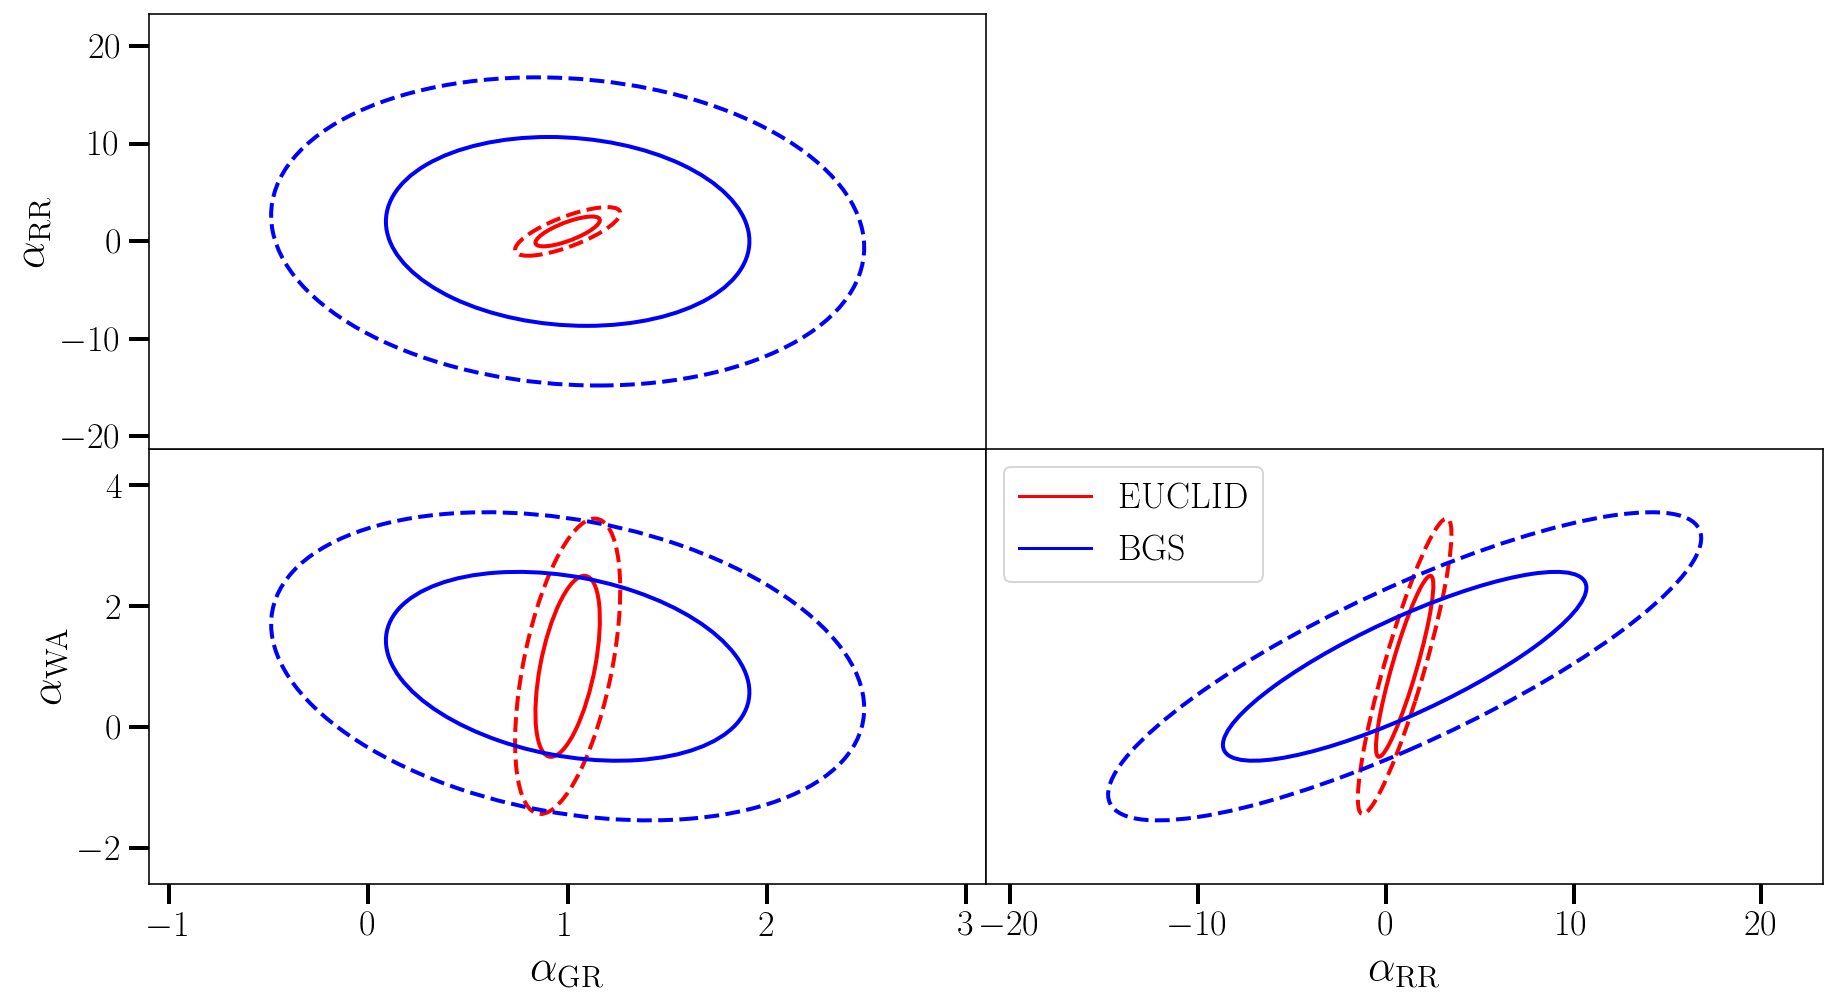

In [73]:
#from normal_corner import normal_corner
#from Library.normal_corner_adapted import *
from Library.normal_corner_ellipse import *


cov_mat = np.linalg.inv(fish_mat_El1)
cov_mat2 = np.linalg.inv(fish_mat_Dl1)
print(cov_mat)
print(cov_mat2)
#cov_matdesi = np.linalg.inv(fish_matdesi)/3
#cov_mat= np.flip(cov_mat)

# Variable labels for plotting, as a list of strings
varlabels = ['$\\alpha_{\\rm WA}$','$\\alpha_{\\rm RR}$','$\\alpha_{\\rm GR}$']

# Mean matrix, as a numpy array
mean = np.array([1, 1, 1])

# Make a corner plot
fig1,axs = normal_corner(cov_mat,mean,varlabels,covm2=cov_mat2,mean2=mean,figsize=(15,8),scale_factor=3.5)
axs[0].plot([], [],'-',color='red', label='EUCLID')
axs[0].plot([], [],'-',color='blue', label='BGS')
axs[0].legend(loc='upper left',fontsize=18,markerscale=0.8)
#fig1,axs = normal_corner(cov_mat,mean,varlabels,scale_factor=3)
#axs[0].axhline(1+1.52*np.sqrt(cov_matdesi[0,0]),linestyle='--')
#axs[1].axhline(1+1.52*np.sqrt(cov_matdesi[0,0]),linestyle='--')
#axs[0].axvline(1+1.52*np.sqrt(cov_matdesi[1,1]),linestyle='--')
#axs[1].axvline(1+1.52*np.sqrt(cov_matdesi[2,2]),linestyle='--')

#axs[2].axhline(1+1.52*np.sqrt(cov_matdesi[1,1]),linestyle='--')
#axs[2].axvline(1+1.52*np.sqrt(cov_matdesi[2,2]),linestyle='--')
plt.savefig('plots/fisher.png', bbox_inches='tight', dpi=400)
plt.show()




## PNG parts

In [20]:
class GR0PNG:
    def l0(params,paramsPNG):
        k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
        fNL,bE01,bE11,bE02,alphak1,alphak2,alphak3 = paramsPNG

        cos = lambda x: np.cos(x)
        sin = lambda x: np.sin(x)
        
        perm12 = D1**4*Pk1*Pk2*(420*C*alphak1**2*alphak2**2*b1**2*f*k1**3*k2 - 420*C*alphak1**2*alphak2**2*b1**2*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1**2*alphak2**2*b1**2*f*k1*k2**3 - 42*C*alphak1**2*alphak2**2*b1*f**2*k1**3*k2*cos(4*theta) + 378*C*alphak1**2*alphak2**2*b1*f**2*k1**3*k2 - 504*C*alphak1**2*alphak2**2*b1*f**2*k1**2*k2**2*cos(3*theta) - 42*C*alphak1**2*alphak2**2*b1*f**2*k1*k2**3*cos(4*theta) + 378*C*alphak1**2*alphak2**2*b1*f**2*k1*k2**3 - 36*C*alphak1**2*alphak2**2*f**3*k1**3*k2*cos(4*theta) + 72*C*alphak1**2*alphak2**2*f**3*k1**3*k2 - 126*C*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(3*theta) - 18*C*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(5*theta) - 36*C*alphak1**2*alphak2**2*f**3*k1*k2**3*cos(4*theta) + 72*C*alphak1**2*alphak2**2*f**3*k1*k2**3 + 420*C*alphak1**2*alphak2*b1*bE01*f*k1**3*k2 - 420*C*alphak1**2*alphak2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1**2*alphak2*b1*bE01*f*k1*k2**3 + 252*C*alphak1**2*alphak2*bE01*f**2*k1**3*k2 - 252*C*alphak1**2*alphak2*bE01*f**2*k1**2*k2**2*cos(3*theta) - 42*C*alphak1**2*alphak2*bE01*f**2*k1*k2**3*cos(4*theta) + 126*C*alphak1**2*alphak2*bE01*f**2*k1*k2**3 + 420*C*alphak1*alphak2**2*b1*bE01*f*k1**3*k2 - 420*C*alphak1*alphak2**2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1*alphak2**2*b1*bE01*f*k1*k2**3 - 42*C*alphak1*alphak2**2*bE01*f**2*k1**3*k2*cos(4*theta) + 126*C*alphak1*alphak2**2*bE01*f**2*k1**3*k2 - 252*C*alphak1*alphak2**2*bE01*f**2*k1**2*k2**2*cos(3*theta) + 252*C*alphak1*alphak2**2*bE01*f**2*k1*k2**3 + 420*C*alphak1*alphak2*bE01**2*f*k1**3*k2 - 420*C*alphak1*alphak2*bE01**2*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1*alphak2*bE01**2*f*k1*k2**3 + 630*K*alphak1**2*alphak2**2*b1**3*k1*k2*k3**2 + 420*K*alphak1**2*alphak2**2*b1**2*f*k1*k2*k3**2 - 21*K*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2*cos(4*theta) + 63*K*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2 + 630*K*alphak1**2*alphak2*b1**2*bE01*k1*k2*k3**2 + 210*K*alphak1**2*alphak2*b1*bE01*f*k1*k2*k3**2 + 630*K*alphak1*alphak2**2*b1**2*bE01*k1*k2*k3**2 + 210*K*alphak1*alphak2**2*b1*bE01*f*k1*k2*k3**2 + 630*K*alphak1*alphak2*b1*bE01**2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1**3*f*k1*k2*k3**2 + 1890*alphak1**2*alphak2**2*b1**3*k1*k2*k3**2 + 1260*alphak1**2*alphak2**2*b1**2*b2*k1*k2*k3**2 + 1176*alphak1**2*alphak2**2*b1**2*f**2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1**2*f*k1**3*k2 + 420*alphak1**2*alphak2**2*b1**2*f*k1**2*k2**2*cos(3*theta) + 840*alphak1**2*alphak2**2*b1**2*f*k1*k2**3 + 1260*alphak1**2*alphak2**2*b1**2*f*k1*k2*k3**2 - 1260*alphak1**2*alphak2**2*b1**2*g2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1*b2*f*k1*k2*k3**2 + 36*alphak1**2*alphak2**2*b1*f**3*k1**2*k3**2*cos(3*theta) + 648*alphak1**2*alphak2**2*b1*f**3*k1*k2*k3**2 + 36*alphak1**2*alphak2**2*b1*f**3*k2**2*k3**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**4*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**3*k2*cos(4*theta) + 966*alphak1**2*alphak2**2*b1*f**2*k1**3*k2 + 588*alphak1**2*alphak2**2*b1*f**2*k1**2*k2**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**2*k3**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1*k2**3*cos(4*theta) + 966*alphak1**2*alphak2**2*b1*f**2*k1*k2**3 + 21*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2*cos(4*theta) + 273*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2 + 42*alphak1**2*alphak2**2*b1*f**2*k2**4*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k2**2*k3**2*cos(3*theta) - 840*alphak1**2*alphak2**2*b1*f*g2*k1*k2*k3**2 + 168*alphak1**2*alphak2**2*b2*f**2*k1*k2*k3**2 + 20*alphak1**2*alphak2**2*f**4*k1**2*k3**2*cos(3*theta) + 8*alphak1**2*alphak2**2*f**4*k1*k2*k3**2*cos(4*theta) + 144*alphak1**2*alphak2**2*f**4*k1*k2*k3**2 + 20*alphak1**2*alphak2**2*f**4*k2**2*k3**2*cos(3*theta) + 36*alphak1**2*alphak2**2*f**3*k1**4*cos(3*theta) + 54*alphak1**2*alphak2**2*f**3*k1**3*k2*cos(4*theta) + 306*alphak1**2*alphak2**2*f**3*k1**3*k2 + 270*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(3*theta) + 18*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(5*theta) + 54*alphak1**2*alphak2**2*f**3*k1*k2**3*cos(4*theta) + 306*alphak1**2*alphak2**2*f**3*k1*k2**3 + 36*alphak1**2*alphak2**2*f**3*k2**4*cos(3*theta) + 42*alphak1**2*alphak2**2*f**2*g2*k1*k2*k3**2*cos(4*theta) - 126*alphak1**2*alphak2**2*f**2*g2*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1**2*bE01*f*k1*k2*k3**2 + 1890*alphak1**2*alphak2*b1**2*bE01*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1**2*bE11*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1*b2*bE01*k1*k2*k3**2 + 1176*alphak1**2*alphak2*b1*bE01*f**2*k1*k2*k3**2 + 840*alphak1**2*alphak2*b1*bE01*f*k1**3*k2 + 420*alphak1**2*alphak2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 840*alphak1**2*alphak2*b1*bE01*f*k1*k2**3 + 630*alphak1**2*alphak2*b1*bE01*f*k1*k2*k3**2 - 1260*alphak1**2*alphak2*b1*bE01*g2*k1*k2*k3**2 + 840*alphak1**2*alphak2*b1*bE11*f*k1*k2*k3**2 + 420*alphak1**2*alphak2*b2*bE01*f*k1*k2*k3**2 + 324*alphak1**2*alphak2*bE01*f**3*k1*k2*k3**2 + 36*alphak1**2*alphak2*bE01*f**3*k2**2*k3**2*cos(3*theta) + 504*alphak1**2*alphak2*bE01*f**2*k1**3*k2 + 294*alphak1**2*alphak2*bE01*f**2*k1**2*k2**2*cos(3*theta) + 42*alphak1**2*alphak2*bE01*f**2*k1*k2**3*cos(4*theta) + 462*alphak1**2*alphak2*bE01*f**2*k1*k2**3 + 42*alphak1**2*alphak2*bE01*f**2*k2**4*cos(3*theta) - 42*alphak1**2*alphak2*bE01*f**2*k2**2*k3**2*cos(3*theta) - 420*alphak1**2*alphak2*bE01*f*g2*k1*k2*k3**2 + 168*alphak1**2*alphak2*bE11*f**2*k1*k2*k3**2 + 420*alphak1**2*b1*bE01**2*f*k1*k2*k3**2 + 1260*alphak1**2*b1*bE01*bE11*k1*k2*k3**2 + 252*alphak1**2*bE01**2*f**2*k1*k2*k3**2 + 420*alphak1**2*bE01*bE11*f*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1**2*bE01*f*k1*k2*k3**2 + 1890*alphak1*alphak2**2*b1**2*bE01*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1**2*bE11*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1*b2*bE01*k1*k2*k3**2 + 1176*alphak1*alphak2**2*b1*bE01*f**2*k1*k2*k3**2 + 840*alphak1*alphak2**2*b1*bE01*f*k1**3*k2 + 420*alphak1*alphak2**2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 840*alphak1*alphak2**2*b1*bE01*f*k1*k2**3 + 630*alphak1*alphak2**2*b1*bE01*f*k1*k2*k3**2 - 1260*alphak1*alphak2**2*b1*bE01*g2*k1*k2*k3**2 + 840*alphak1*alphak2**2*b1*bE11*f*k1*k2*k3**2 + 420*alphak1*alphak2**2*b2*bE01*f*k1*k2*k3**2 + 36*alphak1*alphak2**2*bE01*f**3*k1**2*k3**2*cos(3*theta) + 324*alphak1*alphak2**2*bE01*f**3*k1*k2*k3**2 + 42*alphak1*alphak2**2*bE01*f**2*k1**4*cos(3*theta) + 42*alphak1*alphak2**2*bE01*f**2*k1**3*k2*cos(4*theta) + 462*alphak1*alphak2**2*bE01*f**2*k1**3*k2 + 294*alphak1*alphak2**2*bE01*f**2*k1**2*k2**2*cos(3*theta) - 42*alphak1*alphak2**2*bE01*f**2*k1**2*k3**2*cos(3*theta) + 504*alphak1*alphak2**2*bE01*f**2*k1*k2**3 - 420*alphak1*alphak2**2*bE01*f*g2*k1*k2*k3**2 + 168*alphak1*alphak2**2*bE11*f**2*k1*k2*k3**2 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k1*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**3*k2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2**3 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**3*k2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2**3 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2*k3**2 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**3*k2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**3 + 2520*alphak1*alphak2*b1**2*bE02*k1*k2*k3**2 + 1680*alphak1*alphak2*b1*bE01**2*f*k1*k2*k3**2 + 1890*alphak1*alphak2*b1*bE01**2*k1*k2*k3**2 + 2520*alphak1*alphak2*b1*bE01*bE11*k1*k2*k3**2 + 1680*alphak1*alphak2*b1*bE02*f*k1*k2*k3**2 + 1260*alphak1*alphak2*b2*bE01**2*k1*k2*k3**2 + 672*alphak1*alphak2*bE01**2*f**2*k1*k2*k3**2 + 840*alphak1*alphak2*bE01**2*f*k1**3*k2 + 420*alphak1*alphak2*bE01**2*f*k1**2*k2**2*cos(3*theta) + 840*alphak1*alphak2*bE01**2*f*k1*k2**3 - 1260*alphak1*alphak2*bE01**2*g2*k1*k2*k3**2 + 840*alphak1*alphak2*bE01*bE11*f*k1*k2*k3**2 + 336*alphak1*alphak2*bE02*f**2*k1*k2*k3**2 + 2520*alphak1*alphak3*b1**2*bE01*fNL*k1*k2*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1**3*k2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1*k2**3 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1*k2*k3**2 + 504*alphak1*alphak3*bE01*f**2*fNL*k1**3*k2 + 336*alphak1*alphak3*bE01*f**2*fNL*k1*k2**3 + 2520*alphak1*b1*bE01*bE02*k1*k2*k3**2 + 420*alphak1*bE01**3*f*k1*k2*k3**2 + 1260*alphak1*bE01**2*bE11*k1*k2*k3**2 + 840*alphak1*bE01*bE02*f*k1*k2*k3**2 + 420*alphak2**2*b1*bE01**2*f*k1*k2*k3**2 + 1260*alphak2**2*b1*bE01*bE11*k1*k2*k3**2 + 252*alphak2**2*bE01**2*f**2*k1*k2*k3**2 + 420*alphak2**2*bE01*bE11*f*k1*k2*k3**2 + 2520*alphak2*alphak3*b1**2*bE01*fNL*k1*k2*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1**3*k2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2**3 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2*k3**2 + 336*alphak2*alphak3*bE01*f**2*fNL*k1**3*k2 + 504*alphak2*alphak3*bE01*f**2*fNL*k1*k2**3 + 2520*alphak2*b1*bE01*bE02*k1*k2*k3**2 + 420*alphak2*bE01**3*f*k1*k2*k3**2 + 1260*alphak2*bE01**2*bE11*k1*k2*k3**2 + 840*alphak2*bE01*bE02*f*k1*k2*k3**2 + 2520*alphak3*b1*bE01**2*fNL*k1*k2*k3**2 + 840*alphak3*bE01**2*f*fNL*k1**3*k2 + 840*alphak3*bE01**2*f*fNL*k1*k2**3 + 2520*bE01**2*bE02*k1*k2*k3**2 - 2*k1*k2*(alphak1**2*alphak2*(alphak2*(315*b1**3*k3**2*(K - 1) - 42*b1**2*(4*f**2*k3**2 - 5*f*(k1**2*(C - 2) + k2**2*(C - 2) + k3**2*(K - 1)) + 15*g2*k3**2) - 3*b1*f*(72*f**2*k3**2 - 7*f*(k1**2*(8*C - 24) + k2**2*(8*C - 24) + k3**2*(K - 5)) + 140*g2*k3**2) - 2*f**2*(32*f**2*k3**2 + f*(90 - 9*C)*(k1**2 + k2**2) + k3**2*(21*b2 + 21*g2))) + 315*b1**2*bE01*k3**2*(K - 1) - 21*b1*bE01*(8*f**2*k3**2 - 5*f*(k1**2*(2*C - 4) + k2**2*(2*C - 4) + k3**2*(K - 1)) + 30*g2*k3**2) - 6*f*(bE01*(18*f**2*k3**2 - 7*f*(k1**2*(3*C - 6) + k2**2*(C - 6)) + 35*g2*k3**2) + 7*bE11*f*k3**2)) + 3*alphak1*(alphak2**2*(105*b1**2*bE01*k3**2*(K - 1) - 7*b1*bE01*(8*f**2*k3**2 - 5*f*(k1**2*(2*C - 4) + k2**2*(2*C - 4) + k3**2*(K - 1)) + 30*g2*k3**2) - 2*f*(bE01*(18*f**2*k3**2 - 7*f*(k1**2*(C - 6) + k2**2*(3*C - 6)) + 35*g2*k3**2) + 7*bE11*f*k3**2)) - alphak2*(7*bE01**2*(8*f**2*k3**2 + f*(20 - 10*C)*(k1**2 + k2**2) + k3**2*(-15*K*b1 + 15*b1 + 30*g2)) + 4*f**2*(alphak3*fNL*(7*b1*(k1**2 + k2**2 + k3**2) + 6*f*(k1**2 + k2**2)) + 7*bE02*k3**2)) - 28*alphak3*bE01*f**2*fNL*k2**2) - 84*alphak2*alphak3*bE01*f**2*fNL*k1**2)*cos(2*theta) + (6*alphak1**2*(alphak2**2*(70*b1**3*k3**2*(f + 3)*(k1**2 + k2**2) + 14*b1**2*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(9*f + 10)) + 5*k2**4 + k2**2*k3**2*(9*f + 10)) + 7*b1*f**2*(11*k1**4 + k1**2*(k2**2*(12*C + 58) + k3**2*(12*f + 5)) + 11*k2**4 + k2**2*k3**2*(12*f + 5)) + 4*f**3*(5*f*k2**2*k3**2 + 6*k1**4 + k1**2*(5*f*k3**2 + k2**2*(6*C + 33)) + 6*k2**4)) + alphak2*bE01*(70*b1**2*k3**2*(2*f*k2**2 + k1**2*(f + 3)) + 14*b1*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(6*f + 5)) + 5*k2**4 + k2**2*k3**2*(12*f - 5)) + f**2*(42*k1**4 + k1**2*(30*f*k3**2 + k2**2*(42*C + 203)) + 35*k2**4 + k2**2*k3**2*(54*f - 35))) + 14*bE01**2*k2**2*k3**2*(5*b1*(f - 3) + f*(3*f - 5))) + 6*alphak1*(alphak2**2*bE01*(70*b1**2*k3**2*(f*(2*k1**2 + k2**2) + 3*k2**2) + 14*b1*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(12*f - 5)) + 5*k2**4 + k2**2*k3**2*(6*f + 5)) + f**2*(35*k1**4 + k1**2*(k2**2*(42*C + 203) + k3**2*(54*f - 35)) + 6*k2**2*(5*f*k3**2 + 7*k2**2))) + 2*alphak2*f*(2*alphak3*fNL*k1**2*k2**2*(70*b1**2 + 84*b1*f + 27*f**2) + 7*bE01**2*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(10*b1 + 6*f - 5)) + 5*k2**4 + k2**2*k3**2*(10*b1 + 6*f - 5))) + 14*bE01*k2**2*(4*alphak3*f*fNL*k1**2*(5*b1 + 3*f) + 5*bE01**2*k3**2*(f - 3))) + 84*bE01*k1**2*(alphak2**2*bE01*k3**2*(5*b1*(f - 3) + f*(3*f - 5)) + alphak2*(4*alphak3*f*fNL*k2**2*(5*b1 + 3*f) + 5*bE01**2*k3**2*(f - 3)) + 20*alphak3*bE01*f*fNL*k2**2))*cos(theta))/(1260*alphak1**2*alphak2**2*k1*k2*k3**2)
        perm13 = D1**4*Pk1*Pk3*(-840*C*alphak1**2*alphak3**2*b1**2*f*k1**3*k3**2 - 420*C*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 + 840*C*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 - 336*C*alphak1**2*alphak3**2*b1*f**2*k1**5 - 168*C*alphak1**2*alphak3**2*b1*f**2*k1**4*k2*cos(3*theta) - 42*C*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(4*theta) - 1722*C*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 - 252*C*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) - 168*C*alphak1**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(3*theta) - 252*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 - 42*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(4*theta) + 294*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 + 336*C*alphak1**2*alphak3**2*b1*f**2*k1*k3**4 - 216*C*alphak1**2*alphak3**2*f**3*k1**5 - 216*C*alphak1**2*alphak3**2*f**3*k1**4*k2*cos(3*theta) - 108*C*alphak1**2*alphak3**2*f**3*k1**3*k2**2*cos(4*theta) - 1008*C*alphak1**2*alphak3**2*f**3*k1**3*k2**2 + 216*C*alphak1**2*alphak3**2*f**3*k1**3*k3**2 - 342*C*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(3*theta) - 18*C*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(5*theta) + 72*C*alphak1**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(3*theta) - 36*C*alphak1**2*alphak3**2*f**3*k1*k2**4*cos(4*theta) - 144*C*alphak1**2*alphak3**2*f**3*k1*k2**4 + 216*C*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2 - 840*C*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 - 420*C*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 840*C*alphak1**2*alphak3*b1*bE01*f*k1*k3**4 - 336*C*alphak1**2*alphak3*bE01*f**2*k1**3*k3**2 - 168*C*alphak1**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) - 42*C*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(4*theta) - 210*C*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2 + 336*C*alphak1**2*alphak3*bE01*f**2*k1*k3**4 - 840*C*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 - 420*C*alphak1*alphak3**2*b1*bE01*f*k1*k2**2*k3**2 + 840*C*alphak1*alphak3**2*b1*bE01*f*k1*k3**4 - 336*C*alphak1*alphak3**2*bE01*f**2*k1**5 - 168*C*alphak1*alphak3**2*bE01*f**2*k1**4*k2*cos(3*theta) - 42*C*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2*cos(4*theta) - 1722*C*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2 + 336*C*alphak1*alphak3**2*bE01*f**2*k1**3*k3**2 - 252*C*alphak1*alphak3**2*bE01*f**2*k1**2*k2**3*cos(3*theta) - 252*C*alphak1*alphak3**2*bE01*f**2*k1*k2**4 + 504*C*alphak1*alphak3**2*bE01*f**2*k1*k2**2*k3**2 - 840*C*alphak1*alphak3*bE01**2*f*k1**3*k3**2 - 420*C*alphak1*alphak3*bE01**2*f*k1*k2**2*k3**2 + 840*C*alphak1*alphak3*bE01**2*f*k1*k3**4 - 1260*K*alphak1**2*alphak3**2*b1**3*k1**3*k3**2 - 630*K*alphak1**2*alphak3**2*b1**3*k1*k2**2*k3**2 + 1260*K*alphak1**2*alphak3**2*b1**3*k1*k3**4 - 420*K*alphak1**2*alphak3**2*b1**2*f*k1**5 - 1470*K*alphak1**2*alphak3**2*b1**2*f*k1**3*k2**2 - 210*K*alphak1**2*alphak3**2*b1**2*f*k1**2*k2**3*cos(3*theta) - 210*K*alphak1**2*alphak3**2*b1**2*f*k1*k2**4 + 210*K*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 + 420*K*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 - 252*K*alphak1**2*alphak3**2*b1*f**2*k1**5 - 798*K*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 + 252*K*alphak1**2*alphak3**2*b1*f**2*k1**3*k3**2 - 210*K*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) - 21*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**4*cos(4*theta) - 105*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 + 168*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 - 1260*K*alphak1**2*alphak3*b1**2*bE01*k1**3*k3**2 - 630*K*alphak1**2*alphak3*b1**2*bE01*k1*k2**2*k3**2 + 1260*K*alphak1**2*alphak3*b1**2*bE01*k1*k3**4 - 420*K*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 - 210*K*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 420*K*alphak1**2*alphak3*b1*bE01*f*k1*k3**4 - 1260*K*alphak1*alphak3**2*b1**2*bE01*k1**3*k3**2 - 630*K*alphak1*alphak3**2*b1**2*bE01*k1*k2**2*k3**2 + 1260*K*alphak1*alphak3**2*b1**2*bE01*k1*k3**4 - 420*K*alphak1*alphak3**2*b1*bE01*f*k1**5 - 1470*K*alphak1*alphak3**2*b1*bE01*f*k1**3*k2**2 + 420*K*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 - 210*K*alphak1*alphak3**2*b1*bE01*f*k1**2*k2**3*cos(3*theta) - 210*K*alphak1*alphak3**2*b1*bE01*f*k1*k2**4 + 420*K*alphak1*alphak3**2*b1*bE01*f*k1*k2**2*k3**2 - 1260*K*alphak1*alphak3*b1*bE01**2*k1**3*k3**2 - 630*K*alphak1*alphak3*b1*bE01**2*k1*k2**2*k3**2 + 1260*K*alphak1*alphak3*b1*bE01**2*k1*k3**4 + 420*alphak1**2*alphak3**2*b1**3*f*k1*k2**2*k3**2 + 630*alphak1**2*alphak3**2*b1**3*k1*k2**2*k3**2 + 1260*alphak1**2*alphak3**2*b1**2*b2*k1*k3**4 + 504*alphak1**2*alphak3**2*b1**2*f**2*k1**3*k2**2 + 252*alphak1**2*alphak3**2*b1**2*f**2*k1*k2**4 - 336*alphak1**2*alphak3**2*b1**2*f**2*k1*k2**2*k3**2 + 630*alphak1**2*alphak3**2*b1**2*f*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1**2*f*k1**3*k3**2 + 210*alphak1**2*alphak3**2*b1**2*f*k1**2*k2**3*cos(3*theta) + 210*alphak1**2*alphak3**2*b1**2*f*k1*k2**4 + 210*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 - 420*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 + 2520*alphak1**2*alphak3**2*b1**2*g2*k1**3*k3**2 + 1260*alphak1**2*alphak3**2*b1**2*g2*k1*k2**2*k3**2 - 2520*alphak1**2*alphak3**2*b1**2*g2*k1*k3**4 + 420*alphak1**2*alphak3**2*b1*b2*f*k1**3*k3**2 + 420*alphak1**2*alphak3**2*b1*b2*f*k1*k2**2*k3**2 + 420*alphak1**2*alphak3**2*b1*b2*f*k1*k3**4 + 216*alphak1**2*alphak3**2*b1*f**3*k1**3*k2**2 - 216*alphak1**2*alphak3**2*b1*f**3*k1*k2**4 - 324*alphak1**2*alphak3**2*b1*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3**2*b1*f**3*k2**3*k3**2*cos(3*theta) + 168*alphak1**2*alphak3**2*b1*f**2*k1**5 + 126*alphak1**2*alphak3**2*b1*f**2*k1**4*k2*cos(3*theta) + 42*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(4*theta) + 1596*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) + 84*alphak1**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(3*theta) + 21*alphak1**2*alphak3**2*b1*f**2*k1*k2**4*cos(4*theta) + 357*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 + 42*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(4*theta) - 546*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 - 168*alphak1**2*alphak3**2*b1*f**2*k1*k3**4 - 42*alphak1**2*alphak3**2*b1*f**2*k2**3*k3**2*cos(3*theta) - 42*alphak1**2*alphak3**2*b1*f**2*k2*k3**4*cos(3*theta) + 840*alphak1**2*alphak3**2*b1*f*g2*k1**5 + 2940*alphak1**2*alphak3**2*b1*f*g2*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1*f*g2*k1**2*k2**3*cos(3*theta) + 420*alphak1**2*alphak3**2*b1*f*g2*k1*k2**4 - 420*alphak1**2*alphak3**2*b1*f*g2*k1*k2**2*k3**2 - 840*alphak1**2*alphak3**2*b1*f*g2*k1*k3**4 + 252*alphak1**2*alphak3**2*b2*f**2*k1**3*k3**2 + 168*alphak1**2*alphak3**2*b2*f**2*k1*k2**2*k3**2 - 80*alphak1**2*alphak3**2*f**4*k1**3*k2**2 - 60*alphak1**2*alphak3**2*f**4*k1**2*k2**3*cos(3*theta) - 12*alphak1**2*alphak3**2*f**4*k1*k2**4*cos(4*theta) - 216*alphak1**2*alphak3**2*f**4*k1*k2**4 - 20*alphak1**2*alphak3**2*f**4*k2**5*cos(3*theta) + 108*alphak1**2*alphak3**2*f**3*k1**5 + 144*alphak1**2*alphak3**2*f**3*k1**4*k2*cos(3*theta) + 90*alphak1**2*alphak3**2*f**3*k1**3*k2**2*cos(4*theta) + 738*alphak1**2*alphak3**2*f**3*k1**3*k2**2 - 108*alphak1**2*alphak3**2*f**3*k1**3*k3**2 + 306*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(3*theta) + 18*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(5*theta) - 72*alphak1**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(3*theta) + 36*alphak1**2*alphak3**2*f**3*k1*k2**4*cos(4*theta) + 144*alphak1**2*alphak3**2*f**3*k1*k2**4 - 18*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(4*theta) - 270*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3**2*f**3*k2**3*k3**2*cos(3*theta) + 504*alphak1**2*alphak3**2*f**2*g2*k1**5 + 1596*alphak1**2*alphak3**2*f**2*g2*k1**3*k2**2 - 504*alphak1**2*alphak3**2*f**2*g2*k1**3*k3**2 + 420*alphak1**2*alphak3**2*f**2*g2*k1**2*k2**3*cos(3*theta) + 42*alphak1**2*alphak3**2*f**2*g2*k1*k2**4*cos(4*theta) + 210*alphak1**2*alphak3**2*f**2*g2*k1*k2**4 - 336*alphak1**2*alphak3**2*f**2*g2*k1*k2**2*k3**2 + 420*alphak1**2*alphak3*b1**2*bE01*f*k1*k2**2*k3**2 + 630*alphak1**2*alphak3*b1**2*bE01*k1*k2**2*k3**2 + 1260*alphak1**2*alphak3*b1**2*bE01*k1*k3**4 + 1260*alphak1**2*alphak3*b1**2*bE11*k1*k3**4 + 1260*alphak1**2*alphak3*b1*b2*bE01*k1*k3**4 - 336*alphak1**2*alphak3*b1*bE01*f**2*k1*k2**2*k3**2 + 840*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 + 1470*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 2520*alphak1**2*alphak3*b1*bE01*g2*k1**3*k3**2 + 1260*alphak1**2*alphak3*b1*bE01*g2*k1*k2**2*k3**2 - 2520*alphak1**2*alphak3*b1*bE01*g2*k1*k3**4 + 420*alphak1**2*alphak3*b1*bE11*f*k1**3*k3**2 + 420*alphak1**2*alphak3*b1*bE11*f*k1*k2**2*k3**2 + 420*alphak1**2*alphak3*b1*bE11*f*k1*k3**4 + 420*alphak1**2*alphak3*b2*bE01*f*k1*k3**4 - 324*alphak1**2*alphak3*bE01*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3*bE01*f**3*k2**3*k3**2*cos(3*theta) + 420*alphak1**2*alphak3*bE01*f**2*k1**3*k3**2 + 126*alphak1**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) + 42*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(4*theta) + 630*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2 - 168*alphak1**2*alphak3*bE01*f**2*k1*k3**4 + 42*alphak1**2*alphak3*bE01*f**2*k2**3*k3**2*cos(3*theta) - 42*alphak1**2*alphak3*bE01*f**2*k2*k3**4*cos(3*theta) + 840*alphak1**2*alphak3*bE01*f*g2*k1**3*k3**2 + 420*alphak1**2*alphak3*bE01*f*g2*k1*k2**2*k3**2 - 840*alphak1**2*alphak3*bE01*f*g2*k1*k3**4 + 252*alphak1**2*alphak3*bE11*f**2*k1**3*k3**2 + 168*alphak1**2*alphak3*bE11*f**2*k1*k2**2*k3**2 + 1260*alphak1**2*b1*bE01**2*k1*k3**4 + 1260*alphak1**2*b1*bE01*bE11*k1*k3**4 + 420*alphak1**2*bE01**2*f*k1*k3**4 + 420*alphak1**2*bE01*bE11*f*k1*k3**4 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k1*k3**4 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**3*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2**2*k3**2 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k3**4 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**3*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2**2*k3**2 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k3**4 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**3*k3**2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2*k3**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**2*k3**2 + 2520*alphak1*alphak2*b1**2*bE01*fNL*k1*k3**4 + 1680*alphak1*alphak2*b1*bE01*f*fNL*k1*k3**4 + 336*alphak1*alphak2*bE01*f**2*fNL*k1*k3**4 + 840*alphak1*alphak3**2*b1**2*bE01*f*k1*k2**2*k3**2 + 1260*alphak1*alphak3**2*b1**2*bE01*k1**3*k3**2 + 630*alphak1*alphak3**2*b1**2*bE01*k1*k2**2*k3**2 + 1260*alphak1*alphak3**2*b1**2*bE11*k1*k3**4 + 1260*alphak1*alphak3**2*b1*b2*bE01*k1*k3**4 + 1008*alphak1*alphak3**2*b1*bE01*f**2*k1**3*k2**2 + 504*alphak1*alphak3**2*b1*bE01*f**2*k1*k2**4 - 336*alphak1*alphak3**2*b1*bE01*f**2*k1*k2**2*k3**2 + 420*alphak1*alphak3**2*b1*bE01*f*k1**5 + 1470*alphak1*alphak3**2*b1*bE01*f*k1**3*k2**2 + 840*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 + 210*alphak1*alphak3**2*b1*bE01*f*k1**2*k2**3*cos(3*theta) + 210*alphak1*alphak3**2*b1*bE01*f*k1*k2**4 - 420*alphak1*alphak3**2*b1*bE01*f*k1*k3**4 + 2520*alphak1*alphak3**2*b1*bE01*g2*k1**3*k3**2 + 1260*alphak1*alphak3**2*b1*bE01*g2*k1*k2**2*k3**2 - 2520*alphak1*alphak3**2*b1*bE01*g2*k1*k3**4 + 420*alphak1*alphak3**2*b1*bE11*f*k1**3*k3**2 + 420*alphak1*alphak3**2*b1*bE11*f*k1*k2**2*k3**2 + 420*alphak1*alphak3**2*b1*bE11*f*k1*k3**4 + 420*alphak1*alphak3**2*b2*bE01*f*k1**3*k3**2 + 420*alphak1*alphak3**2*b2*bE01*f*k1*k2**2*k3**2 + 216*alphak1*alphak3**2*bE01*f**3*k1**3*k2**2 - 216*alphak1*alphak3**2*bE01*f**3*k1*k2**4 + 420*alphak1*alphak3**2*bE01*f**2*k1**5 + 126*alphak1*alphak3**2*bE01*f**2*k1**4*k2*cos(3*theta) + 42*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2*cos(4*theta) + 1638*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2 - 168*alphak1*alphak3**2*bE01*f**2*k1**3*k3**2 + 294*alphak1*alphak3**2*bE01*f**2*k1**2*k2**3*cos(3*theta) - 42*alphak1*alphak3**2*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) + 252*alphak1*alphak3**2*bE01*f**2*k1*k2**4 - 504*alphak1*alphak3**2*bE01*f**2*k1*k2**2*k3**2 + 840*alphak1*alphak3**2*bE01*f*g2*k1**5 + 2940*alphak1*alphak3**2*bE01*f*g2*k1**3*k2**2 - 840*alphak1*alphak3**2*bE01*f*g2*k1**3*k3**2 + 420*alphak1*alphak3**2*bE01*f*g2*k1**2*k2**3*cos(3*theta) + 420*alphak1*alphak3**2*bE01*f*g2*k1*k2**4 - 840*alphak1*alphak3**2*bE01*f*g2*k1*k2**2*k3**2 + 252*alphak1*alphak3**2*bE11*f**2*k1**3*k3**2 + 168*alphak1*alphak3**2*bE11*f**2*k1*k2**2*k3**2 + 2520*alphak1*alphak3*b1**2*bE02*k1*k3**4 + 840*alphak1*alphak3*b1*bE01**2*f*k1*k2**2*k3**2 + 1260*alphak1*alphak3*b1*bE01**2*k1**3*k3**2 + 630*alphak1*alphak3*b1*bE01**2*k1*k2**2*k3**2 + 1260*alphak1*alphak3*b1*bE01**2*k1*k3**4 + 2520*alphak1*alphak3*b1*bE01*bE11*k1*k3**4 + 840*alphak1*alphak3*b1*bE02*f*k1**3*k3**2 + 840*alphak1*alphak3*b1*bE02*f*k1*k2**2*k3**2 + 840*alphak1*alphak3*b1*bE02*f*k1*k3**4 + 1260*alphak1*alphak3*b2*bE01**2*k1*k3**4 - 336*alphak1*alphak3*bE01**2*f**2*k1*k2**2*k3**2 + 1260*alphak1*alphak3*bE01**2*f*k1**3*k3**2 + 1260*alphak1*alphak3*bE01**2*f*k1*k2**2*k3**2 - 420*alphak1*alphak3*bE01**2*f*k1*k3**4 + 2520*alphak1*alphak3*bE01**2*g2*k1**3*k3**2 + 1260*alphak1*alphak3*bE01**2*g2*k1*k2**2*k3**2 - 2520*alphak1*alphak3*bE01**2*g2*k1*k3**4 + 420*alphak1*alphak3*bE01*bE11*f*k1**3*k3**2 + 420*alphak1*alphak3*bE01*bE11*f*k1*k2**2*k3**2 + 420*alphak1*alphak3*bE01*bE11*f*k1*k3**4 + 504*alphak1*alphak3*bE02*f**2*k1**3*k3**2 + 336*alphak1*alphak3*bE02*f**2*k1*k2**2*k3**2 + 2520*alphak1*b1*bE01*bE02*k1*k3**4 + 1260*alphak1*bE01**3*k1*k3**4 + 1260*alphak1*bE01**2*bE11*k1*k3**4 + 840*alphak1*bE01*bE02*f*k1*k3**4 + 2520*alphak2*alphak3*b1**2*bE01*fNL*k1*k3**4 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1**3*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2**2*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k3**4 + 336*alphak2*alphak3*bE01*f**2*fNL*k1**3*k3**2 + 504*alphak2*alphak3*bE01*f**2*fNL*k1*k2**2*k3**2 + 2520*alphak2*b1*bE01**2*fNL*k1*k3**4 + 840*alphak2*bE01**2*f*fNL*k1*k3**4 + 420*alphak3**2*b1*bE01**2*f*k1*k2**2*k3**2 + 1260*alphak3**2*b1*bE01**2*k1**3*k3**2 + 1260*alphak3**2*b1*bE01*bE11*k1*k3**4 + 504*alphak3**2*bE01**2*f**2*k1**3*k2**2 + 252*alphak3**2*bE01**2*f**2*k1*k2**4 + 420*alphak3**2*bE01**2*f*k1**5 + 840*alphak3**2*bE01**2*f*k1**3*k2**2 + 420*alphak3**2*bE01*bE11*f*k1**3*k3**2 + 420*alphak3**2*bE01*bE11*f*k1*k2**2*k3**2 + 2520*alphak3*b1*bE01*bE02*k1*k3**4 + 420*alphak3*bE01**3*f*k1*k2**2*k3**2 + 1260*alphak3*bE01**3*k1**3*k3**2 + 1260*alphak3*bE01**2*bE11*k1*k3**4 + 840*alphak3*bE01*bE02*f*k1**3*k3**2 + 840*alphak3*bE01*bE02*f*k1*k2**2*k3**2 + 2520*bE01**2*bE02*k1*k3**4 - 6*k1*(alphak1**2*alphak3*(alphak3*(105*b1**3*k2**2*k3**2*(K - 1) + 7*b1**2*k2**2*(f**2*(-6*k1**2 + 4*k3**2) + 5*f*(k1**2*(5*K - 3) + k2**2*(K - 1) + k3**2*(2*C + K - 1)) - 30*g2*k3**2) + b1*f*(12*f**2*k2**2*(-2*k1**2 + 2*k2**2 + 3*k3**2) + 7*f*(k1**4*(4*C - 2) + k1**2*k2**2*(30*C + 17*K - 33) + k2**4*(6*C + 3*K - 9) + k2**2*k3**2*(6*C - 2*K + 6) + k3**4*(2 - 4*C)) - 70*g2*k2**2*(5*k1**2 + k2**2 + k3**2)) + 2*f**2*(f**2*(5*k1**2*k2**2 + 16*k2**4) + 3*f*(k1**4*(4*C - 2) + k1**2*(k2**2*(29*C - 22) + k3**2*(2 - 4*C)) + k2**4*(5*C - 5) + k2**2*k3**2*(7 - 4*C)) - 7*k2**2*(b2*k3**2 + g2*(17*k1**2 + 3*k2**2 - 2*k3**2)))) + k3**2*(bE01*(105*b1*k2**2*(b1*(K - 1) - 2*g2) + 36*f**3*k2**2 + 14*f**2*(k1**2*(2*C - 1) + k2**2*(3*C + 2*b1 - 7) + k3**2*(1 - 2*C)) + 35*f*k2**2*(b1*(2*C + K - 5) - 2*g2)) - 14*bE11*f**2*k2**2)) - alphak1*(28*alphak2*bE01*f**2*fNL*k3**4 + alphak3**2*(bE01*(-105*b1*k2**2*k3**2*(b1*(K - 1) - 2*g2) + 24*f**3*k2**2*(k1**2 - k2**2) - 14*f**2*(k1**4*(2*C - 1) + k1**2*(k2**2*(15*C - 6*b1 - 16) + k3**2*(1 - 2*C)) + k2**4*(3*C - 3) + k2**2*k3**2*(2*b1 + 3)) - 35*f*k2**2*(b1*(2*C*k3**2 + k1**2*(5*K - 5) + k2**2*(K - 1)) - 2*g2*(5*k1**2 + k2**2))) + 14*bE11*f**2*k2**2*k3**2) + alphak3*k3**2*(4*alphak2*f**2*fNL*(7*b1*(k1**2 + k2**2 + k3**2) + 6*f*(k1**2 + k2**2)) + k2**2*(-105*b1*bE01**2*(K - 1) - 14*bE01**2*(2*f**2 + f*(5*C - 10) - 15*g2) + 28*bE02*f**2))) - 14*alphak3*bE01*f*k1**2*(2*alphak2*f*fNL*k3**2 + alphak3*bE01*k2**2*(3*f + 5)))*cos(2*theta) + 6*k2*(alphak1**2*(alphak3**2*(70*b1**3*(k1**2*k3**2*(-6*K + f + 3) - k3**4*(f + 3)) + 7*b1**2*(6*f**2*(k1**4 + 3*k1**2*k2**2 - k3**2*(2*k2**2 + k3**2)) - 5*f*(k1**4*(8*K - 2) + k1**2*(k2**2*(7*K - 5) + k3**2*(8*C - 6)) + 2*k3**2*(k2**2 + 2*k3**2)) + 120*g2*k1**2*k3**2) + b1*f*(6*f**2*(5*k1**4 - 5*k1**2*k3**2 - 5*k2**4 - 9*k2**2*k3**2) - 7*f*(k1**4*(44*C + 24*K - 33) + k1**2*(k2**2*(42*C + 19*K - 50) - k3**2*(4*C + 12*K - 8)) + 11*k2**2*k3**2 + 5*k3**4) + 70*k1**2*(2*b2*k3**2 + 8*g2*k1**2 + 7*g2*k2**2)) + 2*f**2*(-10*f**2*(3*k1**2*k2**2 + k2**4) - 3*f*(k1**4*(34*C - 21) + k1**2*(k2**2*(30*C - 26) + k3**2*(13 - 18*C)) + 4*k2**2*k3**2) + 7*k1**2*(6*b2*k3**2 + g2*(24*k1**2 + 19*k2**2 - 12*k3**2)))) + alphak3*k3**2*(70*b1**2*bE01*(-2*f*k3**2 + k1**2*(-6*K + f + 3)) - 14*b1*(bE01*(6*f**2*(k2**2 + k3**2) + 5*f*(k1**2*(4*C + 2*K - 7) - k2**2 + k3**2) - 60*g2*k1**2) - 10*bE11*f*k1**2) + f*(bE01*(-6*f**2*(5*k1**2 + 9*k2**2) - 7*f*(k1**2*(20*C - 33) - 5*k2**2 + 5*k3**2) + 280*g2*k1**2) + 84*bE11*f*k1**2)) + 14*bE01**2*k3**4*(-5*b1*(f - 3) + f*(5 - 3*f))) + alphak1*(alphak3**2*(-70*b1**2*bE01*k3**2*(k1**2*(6*K - 2*f - 6) + k3**2*(f + 3)) + 7*b1*(bE01*(12*f**2*(k1**4 + 3*k1**2*k2**2 - k2**2*k3**2) - 5*f*(k1**4*(8*K - 8) + k1**2*(k2**2*(7*K - 7) + k3**2*(8*C - 4*K - 6)) + 2*k3**2*(k2**2 + k3**2)) + 120*g2*k1**2*k3**2) + 20*bE11*f*k1**2*k3**2) + f*(bE01*(30*f**2*(k1**4 - k2**4) - 7*f*(k1**4*(44*C - 45) + k1**2*(k2**2*(42*C - 41) + k3**2*(17 - 24*C)) + 6*k2**2*k3**2) + 70*k1**2*(2*b2*k3**2 + g2*(8*k1**2 + 7*k2**2 - 4*k3**2))) + 84*bE11*f*k1**2*k3**2)) + 2*alphak3*k3**2*(140*alphak2*b1**2*f*fNL*k1**2 + 14*b1*(5*bE01**2*(-f*k3**2 + k1**2*(-3*K + f + 3)) + 2*f*k1**2*(6*alphak2*f*fNL + 5*bE02)) - 7*bE01**2*(6*f**2*k2**2 + 5*f*(k1**2*(4*C - 7) - k2**2 + k3**2) - 60*g2*k1**2) + 70*bE01*bE11*f*k1**2 + 6*f**2*k1**2*(9*alphak2*f*fNL + 14*bE02)) - 70*bE01**3*k3**4*(f - 3)) + 14*alphak3*bE01*k1**2*(alphak3*(bE01*(15*b1*k3**2 + 3*f**2*(k1**2 + 3*k2**2) + 5*f*(b1*k3**2 + 3*k1**2 + k2**2)) + 10*bE11*f*k3**2) + k3**2*(5*bE01**2*(f + 3) + 4*f*(5*alphak2*b1*fNL + 3*alphak2*f*fNL + 5*bE02))))*cos(theta))/(1260*alphak1**2*alphak3**2*k1*k3**4)
        perm23 = D1**4*Pk2*Pk3*(-420*C*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 - 840*C*alphak2**2*alphak3**2*b1**2*f*k2**3*k3**2 + 840*C*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 - 252*C*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 - 252*C*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 42*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(4*theta) - 1722*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 - 42*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(4*theta) + 294*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 - 168*C*alphak2**2*alphak3**2*b1*f**2*k1*k2**4*cos(3*theta) - 168*C*alphak2**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(3*theta) - 336*C*alphak2**2*alphak3**2*b1*f**2*k2**5 + 336*C*alphak2**2*alphak3**2*b1*f**2*k2*k3**4 - 36*C*alphak2**2*alphak3**2*f**3*k1**4*k2*cos(4*theta) - 144*C*alphak2**2*alphak3**2*f**3*k1**4*k2 - 342*C*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(3*theta) - 18*C*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(5*theta) - 108*C*alphak2**2*alphak3**2*f**3*k1**2*k2**3*cos(4*theta) - 1008*C*alphak2**2*alphak3**2*f**3*k1**2*k2**3 + 216*C*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2 - 216*C*alphak2**2*alphak3**2*f**3*k1*k2**4*cos(3*theta) + 72*C*alphak2**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(3*theta) - 216*C*alphak2**2*alphak3**2*f**3*k2**5 + 216*C*alphak2**2*alphak3**2*f**3*k2**3*k3**2 - 420*C*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 - 840*C*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 840*C*alphak2**2*alphak3*b1*bE01*f*k2*k3**4 - 42*C*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(4*theta) - 210*C*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2 - 168*C*alphak2**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) - 336*C*alphak2**2*alphak3*bE01*f**2*k2**3*k3**2 + 336*C*alphak2**2*alphak3*bE01*f**2*k2*k3**4 - 420*C*alphak2*alphak3**2*b1*bE01*f*k1**2*k2*k3**2 - 840*C*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 + 840*C*alphak2*alphak3**2*b1*bE01*f*k2*k3**4 - 252*C*alphak2*alphak3**2*bE01*f**2*k1**4*k2 - 252*C*alphak2*alphak3**2*bE01*f**2*k1**3*k2**2*cos(3*theta) - 42*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3*cos(4*theta) - 1722*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3 + 504*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2*k3**2 - 168*C*alphak2*alphak3**2*bE01*f**2*k1*k2**4*cos(3*theta) - 336*C*alphak2*alphak3**2*bE01*f**2*k2**5 + 336*C*alphak2*alphak3**2*bE01*f**2*k2**3*k3**2 - 420*C*alphak2*alphak3*bE01**2*f*k1**2*k2*k3**2 - 840*C*alphak2*alphak3*bE01**2*f*k2**3*k3**2 + 840*C*alphak2*alphak3*bE01**2*f*k2*k3**4 - 630*K*alphak2**2*alphak3**2*b1**3*k1**2*k2*k3**2 - 1260*K*alphak2**2*alphak3**2*b1**3*k2**3*k3**2 + 1260*K*alphak2**2*alphak3**2*b1**3*k2*k3**4 - 210*K*alphak2**2*alphak3**2*b1**2*f*k1**4*k2 - 210*K*alphak2**2*alphak3**2*b1**2*f*k1**3*k2**2*cos(3*theta) - 1470*K*alphak2**2*alphak3**2*b1**2*f*k1**2*k2**3 + 210*K*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 - 420*K*alphak2**2*alphak3**2*b1**2*f*k2**5 + 420*K*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 - 21*K*alphak2**2*alphak3**2*b1*f**2*k1**4*k2*cos(4*theta) - 105*K*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 - 210*K*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 798*K*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 + 168*K*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 - 252*K*alphak2**2*alphak3**2*b1*f**2*k2**5 + 252*K*alphak2**2*alphak3**2*b1*f**2*k2**3*k3**2 - 630*K*alphak2**2*alphak3*b1**2*bE01*k1**2*k2*k3**2 - 1260*K*alphak2**2*alphak3*b1**2*bE01*k2**3*k3**2 + 1260*K*alphak2**2*alphak3*b1**2*bE01*k2*k3**4 - 210*K*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 - 420*K*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 420*K*alphak2**2*alphak3*b1*bE01*f*k2*k3**4 - 630*K*alphak2*alphak3**2*b1**2*bE01*k1**2*k2*k3**2 - 1260*K*alphak2*alphak3**2*b1**2*bE01*k2**3*k3**2 + 1260*K*alphak2*alphak3**2*b1**2*bE01*k2*k3**4 - 210*K*alphak2*alphak3**2*b1*bE01*f*k1**4*k2 - 210*K*alphak2*alphak3**2*b1*bE01*f*k1**3*k2**2*cos(3*theta) - 1470*K*alphak2*alphak3**2*b1*bE01*f*k1**2*k2**3 + 420*K*alphak2*alphak3**2*b1*bE01*f*k1**2*k2*k3**2 - 420*K*alphak2*alphak3**2*b1*bE01*f*k2**5 + 420*K*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 - 630*K*alphak2*alphak3*b1*bE01**2*k1**2*k2*k3**2 - 1260*K*alphak2*alphak3*b1*bE01**2*k2**3*k3**2 + 1260*K*alphak2*alphak3*b1*bE01**2*k2*k3**4 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k2*k3**4 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k2**3*k3**2 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k2*k3**4 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k2**3*k3**2 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k2*k3**4 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2*k3**2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**2*k3**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k2**3*k3**2 + 2520*alphak1*alphak2*b1**2*bE01*fNL*k2*k3**4 + 1680*alphak1*alphak2*b1*bE01*f*fNL*k2*k3**4 + 336*alphak1*alphak2*bE01*f**2*fNL*k2*k3**4 + 2520*alphak1*alphak3*b1**2*bE01*fNL*k2*k3**4 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k2**3*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k2*k3**4 + 504*alphak1*alphak3*bE01*f**2*fNL*k1**2*k2*k3**2 + 336*alphak1*alphak3*bE01*f**2*fNL*k2**3*k3**2 + 2520*alphak1*b1*bE01**2*fNL*k2*k3**4 + 840*alphak1*bE01**2*f*fNL*k2*k3**4 + 420*alphak2**2*alphak3**2*b1**3*f*k1**2*k2*k3**2 + 630*alphak2**2*alphak3**2*b1**3*k1**2*k2*k3**2 + 1260*alphak2**2*alphak3**2*b1**2*b2*k2*k3**4 + 252*alphak2**2*alphak3**2*b1**2*f**2*k1**4*k2 + 504*alphak2**2*alphak3**2*b1**2*f**2*k1**2*k2**3 - 336*alphak2**2*alphak3**2*b1**2*f**2*k1**2*k2*k3**2 + 210*alphak2**2*alphak3**2*b1**2*f*k1**4*k2 + 210*alphak2**2*alphak3**2*b1**2*f*k1**3*k2**2*cos(3*theta) + 630*alphak2**2*alphak3**2*b1**2*f*k1**2*k2**3 + 210*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3**2*b1**2*f*k2**3*k3**2 - 420*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 + 1260*alphak2**2*alphak3**2*b1**2*g2*k1**2*k2*k3**2 + 2520*alphak2**2*alphak3**2*b1**2*g2*k2**3*k3**2 - 2520*alphak2**2*alphak3**2*b1**2*g2*k2*k3**4 + 420*alphak2**2*alphak3**2*b1*b2*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3**2*b1*b2*f*k2**3*k3**2 + 420*alphak2**2*alphak3**2*b1*b2*f*k2*k3**4 - 216*alphak2**2*alphak3**2*b1*f**3*k1**4*k2 - 36*alphak2**2*alphak3**2*b1*f**3*k1**3*k3**2*cos(3*theta) + 216*alphak2**2*alphak3**2*b1*f**3*k1**2*k2**3 - 324*alphak2**2*alphak3**2*b1*f**3*k1**2*k2*k3**2 + 21*alphak2**2*alphak3**2*b1*f**2*k1**4*k2*cos(4*theta) + 357*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 + 420*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 42*alphak2**2*alphak3**2*b1*f**2*k1**3*k3**2*cos(3*theta) + 42*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(4*theta) + 1596*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 + 42*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(4*theta) - 546*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 + 126*alphak2**2*alphak3**2*b1*f**2*k1*k2**4*cos(3*theta) + 84*alphak2**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(3*theta) - 42*alphak2**2*alphak3**2*b1*f**2*k1*k3**4*cos(3*theta) + 168*alphak2**2*alphak3**2*b1*f**2*k2**5 - 168*alphak2**2*alphak3**2*b1*f**2*k2*k3**4 + 420*alphak2**2*alphak3**2*b1*f*g2*k1**4*k2 + 420*alphak2**2*alphak3**2*b1*f*g2*k1**3*k2**2*cos(3*theta) + 2940*alphak2**2*alphak3**2*b1*f*g2*k1**2*k2**3 - 420*alphak2**2*alphak3**2*b1*f*g2*k1**2*k2*k3**2 + 840*alphak2**2*alphak3**2*b1*f*g2*k2**5 - 840*alphak2**2*alphak3**2*b1*f*g2*k2*k3**4 + 168*alphak2**2*alphak3**2*b2*f**2*k1**2*k2*k3**2 + 252*alphak2**2*alphak3**2*b2*f**2*k2**3*k3**2 - 20*alphak2**2*alphak3**2*f**4*k1**5*cos(3*theta) - 12*alphak2**2*alphak3**2*f**4*k1**4*k2*cos(4*theta) - 216*alphak2**2*alphak3**2*f**4*k1**4*k2 - 60*alphak2**2*alphak3**2*f**4*k1**3*k2**2*cos(3*theta) - 80*alphak2**2*alphak3**2*f**4*k1**2*k2**3 + 36*alphak2**2*alphak3**2*f**3*k1**4*k2*cos(4*theta) + 144*alphak2**2*alphak3**2*f**3*k1**4*k2 + 306*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(3*theta) + 18*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(5*theta) - 36*alphak2**2*alphak3**2*f**3*k1**3*k3**2*cos(3*theta) + 90*alphak2**2*alphak3**2*f**3*k1**2*k2**3*cos(4*theta) + 738*alphak2**2*alphak3**2*f**3*k1**2*k2**3 - 18*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(4*theta) - 270*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2 + 144*alphak2**2*alphak3**2*f**3*k1*k2**4*cos(3*theta) - 72*alphak2**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(3*theta) + 108*alphak2**2*alphak3**2*f**3*k2**5 - 108*alphak2**2*alphak3**2*f**3*k2**3*k3**2 + 42*alphak2**2*alphak3**2*f**2*g2*k1**4*k2*cos(4*theta) + 210*alphak2**2*alphak3**2*f**2*g2*k1**4*k2 + 420*alphak2**2*alphak3**2*f**2*g2*k1**3*k2**2*cos(3*theta) + 1596*alphak2**2*alphak3**2*f**2*g2*k1**2*k2**3 - 336*alphak2**2*alphak3**2*f**2*g2*k1**2*k2*k3**2 + 504*alphak2**2*alphak3**2*f**2*g2*k2**5 - 504*alphak2**2*alphak3**2*f**2*g2*k2**3*k3**2 + 420*alphak2**2*alphak3*b1**2*bE01*f*k1**2*k2*k3**2 + 630*alphak2**2*alphak3*b1**2*bE01*k1**2*k2*k3**2 + 1260*alphak2**2*alphak3*b1**2*bE01*k2*k3**4 + 1260*alphak2**2*alphak3*b1**2*bE11*k2*k3**4 + 1260*alphak2**2*alphak3*b1*b2*bE01*k2*k3**4 - 336*alphak2**2*alphak3*b1*bE01*f**2*k1**2*k2*k3**2 + 1470*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 + 840*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 1260*alphak2**2*alphak3*b1*bE01*g2*k1**2*k2*k3**2 + 2520*alphak2**2*alphak3*b1*bE01*g2*k2**3*k3**2 - 2520*alphak2**2*alphak3*b1*bE01*g2*k2*k3**4 + 420*alphak2**2*alphak3*b1*bE11*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3*b1*bE11*f*k2**3*k3**2 + 420*alphak2**2*alphak3*b1*bE11*f*k2*k3**4 + 420*alphak2**2*alphak3*b2*bE01*f*k2*k3**4 - 36*alphak2**2*alphak3*bE01*f**3*k1**3*k3**2*cos(3*theta) - 324*alphak2**2*alphak3*bE01*f**3*k1**2*k2*k3**2 + 42*alphak2**2*alphak3*bE01*f**2*k1**3*k3**2*cos(3*theta) + 42*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(4*theta) + 630*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2 + 126*alphak2**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) - 42*alphak2**2*alphak3*bE01*f**2*k1*k3**4*cos(3*theta) + 420*alphak2**2*alphak3*bE01*f**2*k2**3*k3**2 - 168*alphak2**2*alphak3*bE01*f**2*k2*k3**4 + 420*alphak2**2*alphak3*bE01*f*g2*k1**2*k2*k3**2 + 840*alphak2**2*alphak3*bE01*f*g2*k2**3*k3**2 - 840*alphak2**2*alphak3*bE01*f*g2*k2*k3**4 + 168*alphak2**2*alphak3*bE11*f**2*k1**2*k2*k3**2 + 252*alphak2**2*alphak3*bE11*f**2*k2**3*k3**2 + 1260*alphak2**2*b1*bE01**2*k2*k3**4 + 1260*alphak2**2*b1*bE01*bE11*k2*k3**4 + 420*alphak2**2*bE01**2*f*k2*k3**4 + 420*alphak2**2*bE01*bE11*f*k2*k3**4 + 840*alphak2*alphak3**2*b1**2*bE01*f*k1**2*k2*k3**2 + 630*alphak2*alphak3**2*b1**2*bE01*k1**2*k2*k3**2 + 1260*alphak2*alphak3**2*b1**2*bE01*k2**3*k3**2 + 1260*alphak2*alphak3**2*b1**2*bE11*k2*k3**4 + 1260*alphak2*alphak3**2*b1*b2*bE01*k2*k3**4 + 504*alphak2*alphak3**2*b1*bE01*f**2*k1**4*k2 + 1008*alphak2*alphak3**2*b1*bE01*f**2*k1**2*k2**3 - 336*alphak2*alphak3**2*b1*bE01*f**2*k1**2*k2*k3**2 + 210*alphak2*alphak3**2*b1*bE01*f*k1**4*k2 + 210*alphak2*alphak3**2*b1*bE01*f*k1**3*k2**2*cos(3*theta) + 1470*alphak2*alphak3**2*b1*bE01*f*k1**2*k2**3 + 420*alphak2*alphak3**2*b1*bE01*f*k2**5 + 840*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 - 420*alphak2*alphak3**2*b1*bE01*f*k2*k3**4 + 1260*alphak2*alphak3**2*b1*bE01*g2*k1**2*k2*k3**2 + 2520*alphak2*alphak3**2*b1*bE01*g2*k2**3*k3**2 - 2520*alphak2*alphak3**2*b1*bE01*g2*k2*k3**4 + 420*alphak2*alphak3**2*b1*bE11*f*k1**2*k2*k3**2 + 420*alphak2*alphak3**2*b1*bE11*f*k2**3*k3**2 + 420*alphak2*alphak3**2*b1*bE11*f*k2*k3**4 + 420*alphak2*alphak3**2*b2*bE01*f*k1**2*k2*k3**2 + 420*alphak2*alphak3**2*b2*bE01*f*k2**3*k3**2 - 216*alphak2*alphak3**2*bE01*f**3*k1**4*k2 + 216*alphak2*alphak3**2*bE01*f**3*k1**2*k2**3 + 252*alphak2*alphak3**2*bE01*f**2*k1**4*k2 + 294*alphak2*alphak3**2*bE01*f**2*k1**3*k2**2*cos(3*theta) + 42*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3*cos(4*theta) + 1638*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3 - 504*alphak2*alphak3**2*bE01*f**2*k1**2*k2*k3**2 + 126*alphak2*alphak3**2*bE01*f**2*k1*k2**4*cos(3*theta) - 42*alphak2*alphak3**2*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) + 420*alphak2*alphak3**2*bE01*f**2*k2**5 - 168*alphak2*alphak3**2*bE01*f**2*k2**3*k3**2 + 420*alphak2*alphak3**2*bE01*f*g2*k1**4*k2 + 420*alphak2*alphak3**2*bE01*f*g2*k1**3*k2**2*cos(3*theta) + 2940*alphak2*alphak3**2*bE01*f*g2*k1**2*k2**3 - 840*alphak2*alphak3**2*bE01*f*g2*k1**2*k2*k3**2 + 840*alphak2*alphak3**2*bE01*f*g2*k2**5 - 840*alphak2*alphak3**2*bE01*f*g2*k2**3*k3**2 + 168*alphak2*alphak3**2*bE11*f**2*k1**2*k2*k3**2 + 252*alphak2*alphak3**2*bE11*f**2*k2**3*k3**2 + 2520*alphak2*alphak3*b1**2*bE02*k2*k3**4 + 840*alphak2*alphak3*b1*bE01**2*f*k1**2*k2*k3**2 + 630*alphak2*alphak3*b1*bE01**2*k1**2*k2*k3**2 + 1260*alphak2*alphak3*b1*bE01**2*k2**3*k3**2 + 1260*alphak2*alphak3*b1*bE01**2*k2*k3**4 + 2520*alphak2*alphak3*b1*bE01*bE11*k2*k3**4 + 840*alphak2*alphak3*b1*bE02*f*k1**2*k2*k3**2 + 840*alphak2*alphak3*b1*bE02*f*k2**3*k3**2 + 840*alphak2*alphak3*b1*bE02*f*k2*k3**4 + 1260*alphak2*alphak3*b2*bE01**2*k2*k3**4 - 336*alphak2*alphak3*bE01**2*f**2*k1**2*k2*k3**2 + 1260*alphak2*alphak3*bE01**2*f*k1**2*k2*k3**2 + 1260*alphak2*alphak3*bE01**2*f*k2**3*k3**2 - 420*alphak2*alphak3*bE01**2*f*k2*k3**4 + 1260*alphak2*alphak3*bE01**2*g2*k1**2*k2*k3**2 + 2520*alphak2*alphak3*bE01**2*g2*k2**3*k3**2 - 2520*alphak2*alphak3*bE01**2*g2*k2*k3**4 + 420*alphak2*alphak3*bE01*bE11*f*k1**2*k2*k3**2 + 420*alphak2*alphak3*bE01*bE11*f*k2**3*k3**2 + 420*alphak2*alphak3*bE01*bE11*f*k2*k3**4 + 336*alphak2*alphak3*bE02*f**2*k1**2*k2*k3**2 + 504*alphak2*alphak3*bE02*f**2*k2**3*k3**2 + 2520*alphak2*b1*bE01*bE02*k2*k3**4 + 1260*alphak2*bE01**3*k2*k3**4 + 1260*alphak2*bE01**2*bE11*k2*k3**4 + 840*alphak2*bE01*bE02*f*k2*k3**4 + 420*alphak3**2*b1*bE01**2*f*k1**2*k2*k3**2 + 1260*alphak3**2*b1*bE01**2*k2**3*k3**2 + 1260*alphak3**2*b1*bE01*bE11*k2*k3**4 + 252*alphak3**2*bE01**2*f**2*k1**4*k2 + 504*alphak3**2*bE01**2*f**2*k1**2*k2**3 + 840*alphak3**2*bE01**2*f*k1**2*k2**3 + 420*alphak3**2*bE01**2*f*k2**5 + 420*alphak3**2*bE01*bE11*f*k1**2*k2*k3**2 + 420*alphak3**2*bE01*bE11*f*k2**3*k3**2 + 2520*alphak3*b1*bE01*bE02*k2*k3**4 + 420*alphak3*bE01**3*f*k1**2*k2*k3**2 + 1260*alphak3*bE01**3*k2**3*k3**2 + 1260*alphak3*bE01**2*bE11*k2*k3**4 + 840*alphak3*bE01*bE02*f*k1**2*k2*k3**2 + 840*alphak3*bE01*bE02*f*k2**3*k3**2 + 2520*bE01**2*bE02*k2*k3**4 + 6*k1*(alphak2**2*(alphak3**2*(-70*b1**3*k3**2*(-k2**2*(-6*K + f + 3) + k3**2*(f + 3)) + 7*b1**2*(6*f**2*(k1**2*(3*k2**2 - 2*k3**2) + k2**4 - k3**4) - 5*f*(k1**2*(k2**2*(7*K - 5) + 2*k3**2) + k2**4*(8*K - 2) + k2**2*k3**2*(8*C - 6) + 4*k3**4) + 120*g2*k2**2*k3**2) - b1*f*(6*f**2*(5*k1**4 + 9*k1**2*k3**2 - 5*k2**4 + 5*k2**2*k3**2) + 7*f*(k1**2*(k2**2*(42*C + 19*K - 50) + 11*k3**2) + k2**4*(44*C + 24*K - 33) - k2**2*k3**2*(4*C + 12*K - 8) + 5*k3**4) - 70*k2**2*(2*b2*k3**2 + 7*g2*k1**2 + 8*g2*k2**2)) - 2*f**2*(10*f**2*(k1**4 + 3*k1**2*k2**2) + 3*f*(k1**2*(k2**2*(30*C - 26) + 4*k3**2) + k2**4*(34*C - 21) + k2**2*k3**2*(13 - 18*C)) - 7*k2**2*(6*b2*k3**2 + g2*(19*k1**2 + 24*k2**2 - 12*k3**2)))) + alphak3*k3**2*(70*b1**2*bE01*(-2*f*k3**2 + k2**2*(-6*K + f + 3)) - 14*b1*(bE01*(6*f**2*(k1**2 + k3**2) - 5*f*(k1**2 + k2**2*(-4*C - 2*K + 7) - k3**2) - 60*g2*k2**2) - 10*bE11*f*k2**2) + f*(bE01*(-6*f**2*(9*k1**2 + 5*k2**2) + 7*f*(5*k1**2 + k2**2*(33 - 20*C) - 5*k3**2) + 280*g2*k2**2) + 84*bE11*f*k2**2)) + 14*bE01**2*k3**4*(-5*b1*(f - 3) + f*(5 - 3*f))) + alphak2*(alphak3**2*(bE01*(-210*b1*k3**2*(b1*(k2**2*(2*K - 2) + k3**2) - 4*g2*k2**2) - 30*f**3*(k1**4 - k2**4) + 7*f**2*(k1**2*(k2**2*(-42*C + 36*b1 + 41) - k3**2*(12*b1 + 6)) + k2**4*(-44*C + 12*b1 + 45) + k2**2*k3**2*(24*C - 17)) + 35*f*(b1**2*(4*k2**2*k3**2 - 2*k3**4) + b1*(k1**2*(k2**2*(7 - 7*K) - 2*k3**2) + k2**4*(8 - 8*K) + k2**2*k3**2*(-8*C + 4*K + 6) - 2*k3**4) + 2*k2**2*(2*b2*k3**2 + g2*(7*k1**2 + 8*k2**2 - 4*k3**2)))) + 28*bE11*f*k2**2*k3**2*(5*b1 + 3*f)) + 2*alphak3*k3**2*(-7*bE01**2*(6*f**2*k1**2 - 5*f*(k1**2 + k2**2*(-4*C + 2*b1 + 7) - k3**2*(2*b1 + 1)) - k2**2*(-30*K*b1 + 30*b1 + 60*g2)) + 70*bE01*bE11*f*k2**2 + 2*f*k2**2*(70*alphak1*b1**2*fNL + 84*alphak1*b1*f*fNL + 27*alphak1*f**2*fNL + 70*b1*bE02 + 42*bE02*f)) - 70*bE01**3*k3**4*(f - 3)) + 14*alphak3*bE01*k2**2*(alphak3*(bE01*(15*b1*k3**2 + 3*f**2*(3*k1**2 + k2**2) + 5*f*(b1*k3**2 + k1**2 + 3*k2**2)) + 10*bE11*f*k3**2) + k3**2*(5*bE01**2*(f + 3) + 4*f*(5*alphak1*b1*fNL + 3*alphak1*f*fNL + 5*bE02))))*cos(theta) - 6*k2*(alphak2**2*alphak3*(alphak3*(105*b1**3*k1**2*k3**2*(K - 1) + 7*b1**2*k1**2*(f**2*(-6*k2**2 + 4*k3**2) + 5*f*(k1**2*(K - 1) + k2**2*(5*K - 3) + k3**2*(2*C + K - 1)) - 30*g2*k3**2) + b1*f*(12*f**2*k1**2*(2*k1**2 - 2*k2**2 + 3*k3**2) + 7*f*(k1**4*(6*C + 3*K - 9) + k1**2*(k2**2*(30*C + 17*K - 33) + k3**2*(6*C - 2*K + 6)) + (4*C - 2)*(k2**4 - k3**4)) - 70*g2*k1**2*(k1**2 + 5*k2**2 + k3**2)) + 2*f**2*(f**2*(16*k1**4 + 5*k1**2*k2**2) + 3*f*(k1**4*(5*C - 5) + k1**2*(k2**2*(29*C - 22) + k3**2*(7 - 4*C)) + k2**2*(4*C - 2)*(k2**2 - k3**2)) - 7*k1**2*(b2*k3**2 + g2*(3*k1**2 + 17*k2**2 - 2*k3**2)))) + k3**2*(105*b1**2*bE01*k1**2*(K - 1) + 7*b1*bE01*k1**2*(4*f**2 + 5*f*(2*C + K - 5) - 30*g2) + 2*f*(bE01*(18*f**2*k1**2 + 7*f*(k1**2*(3*C - 7) + (2*C - 1)*(k2**2 - k3**2)) - 35*g2*k1**2) - 7*bE11*f*k1**2))) + alphak2*(-28*alphak1*bE01*f**2*fNL*k3**4 + alphak3**2*(105*b1**2*bE01*k1**2*k3**2*(K - 1) + 7*b1*bE01*k1**2*(4*f**2*(-3*k2**2 + k3**2) + 5*f*(2*C*k3**2 + k1**2*(K - 1) + k2**2*(5*K - 5)) - 30*g2*k3**2) + 2*f*(bE01*(12*f**2*(k1**4 - k1**2*k2**2) + 7*f*(k1**4*(3*C - 3) + k1**2*(k2**2*(15*C - 16) + 3*k3**2) + k2**2*(2*C - 1)*(k2**2 - k3**2)) - 35*g2*k1**2*(k1**2 + 5*k2**2)) - 7*bE11*f*k1**2*k3**2)) - alphak3*k3**2*(-7*b1*(-4*alphak1*f**2*fNL*(k1**2 + k2**2 + k3**2) + 15*bE01**2*k1**2*(K - 1)) - 14*bE01**2*k1**2*(2*f**2 + f*(5*C - 10) - 15*g2) + 4*f**2*(6*alphak1*f*fNL*(k1**2 + k2**2) + 7*bE02*k1**2))) - 14*alphak3*bE01*f*k2**2*(2*alphak1*f*fNL*k3**2 + alphak3*bE01*k1**2*(3*f + 5)))*cos(2*theta))/(1260*alphak2**2*alphak3**2*k2*k3**4)
        return np.sqrt((4*np.pi))*(perm12+perm13+perm23)
    
    def l2(params,paramsPNG):
        k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
        fNL,bE01,bE11,bE02,alphak1,alphak2,alphak3 = paramsPNG
        
        cos = lambda x: np.cos(x)
        sin = lambda x: np.sin(x)
        
        perm12 = 1
        perm13 = 1
        perm23 = 1
        return perm12+perm13+perm23

In [21]:
from bk_ws_1 import *
from RR import *
from WA import *
from RR_x1 import RR as RR_x1

In [22]:
def numeric_ylm(func,l,m,r=0,s=0,params=params,derivs=derivs,betas=betas,dfog=False,type_ = 0):
    """
    does numerical integration with double legendre guass integration implemented in int_gl_dbl()
    is vectorised just last two axes need to be dimension 1 
    """

    def int_gl_dbl(func,*args):
        """
        implements double legendre guass integral for mu and phi integrals - extension and specialiation
        of integrate.fixed_quad()
        """
        n=20

        nodes, weights = np.polynomial.legendre.leggauss(n)#legendre gauss - get nodes and weights for given n
        nodes = np.real(nodes)
        mesh_nodes1,mesh_nodes2 = np.meshgrid(nodes,nodes,indexing ='ij')        #mesh gridding as 2d
        mesh_weights1,mesh_weights2 = np.meshgrid(weights,weights,indexing ='ij')

        phi_nodes = (2*np.pi)*(mesh_nodes1+1)/2.0 #sample phi range [0,2*np.pi]
        mu_nodes = (2)*(mesh_nodes2+1)/2.0 - 1 # sample mu range [-1,1] - so this is the natural gauss legendre range!

        return (2*np.pi)/2.0 * np.sum(mesh_weights1*mesh_weights2*func(phi_nodes, mu_nodes, *args), axis=(-2,-1)) #sum over last two axes (mu and phi)
    
    k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
    def integrand(phi,mu,*args):
        ylm = scipy.special.sph_harm(m, l, phi, np.arccos(mu))
        expression = func(*args,mu,phi,r=r,s=s)
        
        if dfog:
            sigma = 5
            mu2 = mu*np.cos(theta)+ (1-mu**2)**(1/2) *np.sin(theta)*np.cos(phi)
            mu3 = -(mu*k1+mu2*k2)/k3
            dfog_val = np.exp(-(1/2)*((k1*mu)**2+(k2 *mu2)**2+(k3 *mu3)**2)*sigma**2)
        else:
            dfog_val = 1
        return np.conjugate(ylm)*expression*dfog_val
    
    if type_ == 0:
        result = int_gl_dbl(integrand,params)
    elif type_ == 1:
        result = int_gl_dbl(integrand,params,derivs)
    elif type_ == 2:
        result = int_gl_dbl(integrand,params,betas)
    elif type_ == 3:
        result = int_gl_dbl(integrand,params,derivs,betas)
        
    return result

In [23]:
%%time
#k1=0.1
#k2= 0.05
#theta = np.linspace(0,np.pi,100)
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
k2 = np.linspace(0.01,0.04)
k1 = k3 = 0.04
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

zz=1
theta_= theta[..., None, None]
k1_= k1#[..., None, None]
k2_= k2[..., None, None]

cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'
params = cosmo_functions.get_params(k1_,k2_,theta_,zz)
derivs = cosmo_functions.get_derivs(zz)
fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1 = derivs
#derivs = 0*fd,0*Dd,0*gd2,0*bd2,0*bd1,fdd,Ddd,gdd2,bdd2,bdd1
betas = cosmo_functions.get_beta_funcs(zz)
    
l=0
m=0
#test = numeric_ylm(WA.full_1,l,m,params=params,dfog=True,type_=0)
#test1 = numeric_ylm(RR.full_2,l,m,params=params,derivs=derivs,dfog=False,type_=1)
#test2 = numeric_ylm(RR_x1.full_2,l,m,params=params,derivs=derivs,dfog=False,type_=1)

testwa_x1 = numeric_ylm(WA_2,l,m,r=1,s=0,params=params,dfog=False,type_=0)

testwa = numeric_ylm(WA_2,l,m,r=0,s=0,params=params,dfog=False,type_=0)

params = cosmo_functions.get_params(k1,k2,theta,zz)

CPU times: user 4.45 s, sys: 0 ns, total: 4.45 s
Wall time: 6.44 s


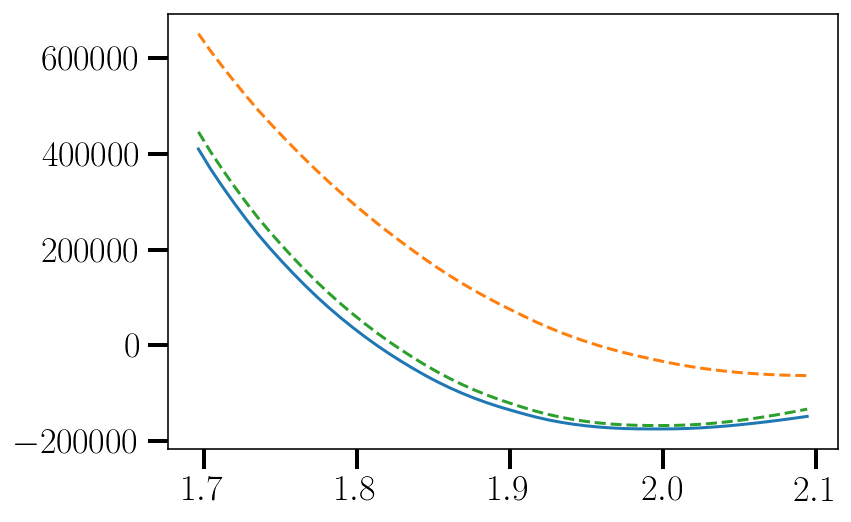

In [24]:
#%%time
#plt.plot(theta,RR2.l0(params,derivs,r=0,s=0).real/RR2_.l0(params,derivs,r=0,s=0).real,'--')
#plt.plot(theta,test2.real/RR2_.l0(params,derivs,r=1,s=0).real,'--')
#plt.plot(theta,test1.real/test2.real)

plt.plot(theta,testwa.real,'-')
#plt.plot(theta,testwa_x1.real,'-')
plt.plot(theta,WA2.l0(params,r=0,s=0).real,'--')
plt.plot(theta,WA2_.l0(params,r=0,s=0).real,'--')
#plt.plot(theta,WA2.l0(params,r=1,s=0).real,'--')


#plt.plot(theta,RR2_.l0(params,derivs,r=0,s=0).real,'--')
#plt.plot(theta,test1.real)
#plt.plot(theta,test2.real)
#plt.ylim(-2,2)
#plt.plot(theta,np.zeros_like(theta))

In [24]:
# so lets plot effective fNL
zz=1

r=s=1/3

k1 = np.linspace(0.05,0.1,1000)
k2= k1
k3 = 0.005

theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'fuck')#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)

PNG_term = GR0PNG.l0(params,PNGparams)-GR0.l0(params)
#total WS terms
tot = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)

NameError: name 'GR0PNG' is not defined

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,8))

r=1/3;s=1/3

axs[0].plot(k1,WA2.l0(params,r,s)/PNG_term,'-',label='WA',color='blue',linewidth=2)
axs[0].plot(k1,RR2.l0(params,derivs,r,s)/PNG_term,'-',label='RR',color='red',linewidth=2)
axs[0].plot(k1,WARR.l0(params,derivs,r,s)/PNG_term,'--',label='WA/RR',color='orange',linewidth=2)
axs[0].plot(k1,WAGR.l0(params,betas,r,s)/PNG_term,'-.',label='WA/GR',color='purple',linewidth=2)
axs[0].plot(k1,RRGR.l0(params,derivs,betas,r,s)/PNG_term,'-.',label='RR/GR',color='magenta',linewidth=2)

axs[1].plot(k1,GR2.l0(params,betas)/PNG_term,'-',label='GR',color='green',linewidth=2)
axs[1].plot(k1,tot/PNG_term,'-.',label='WS Total',color='black',linewidth=2)

for i in range(2):
    axs[i].set_xlabel('$ k_1=k_2 \,\,[h/\mathrm{Mpc}]$')
    axs[i].plot(k3,np.zeros_like(k3),'--', color='black')
    axs[i].grid(ls='--',lw=0.75)
    axs[i].set_xlim(0.05,0.10)

axs[0].set_ylabel('effective $f_{NL}$')
axs[0].set_ylim(-12,6)

fig.legend(loc=[0.03,0.9],ncol=7,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=1, borderpad=0.5)

#plt.plot(k1,np.zeros_like(k1),'--', color='black')

plt.savefig('plots/effective_fNL.png', bbox_inches='tight', dpi=400)
plt.show()

## General plots

Text(0, 0.5, '$ \\text{Imag}[B_{\\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

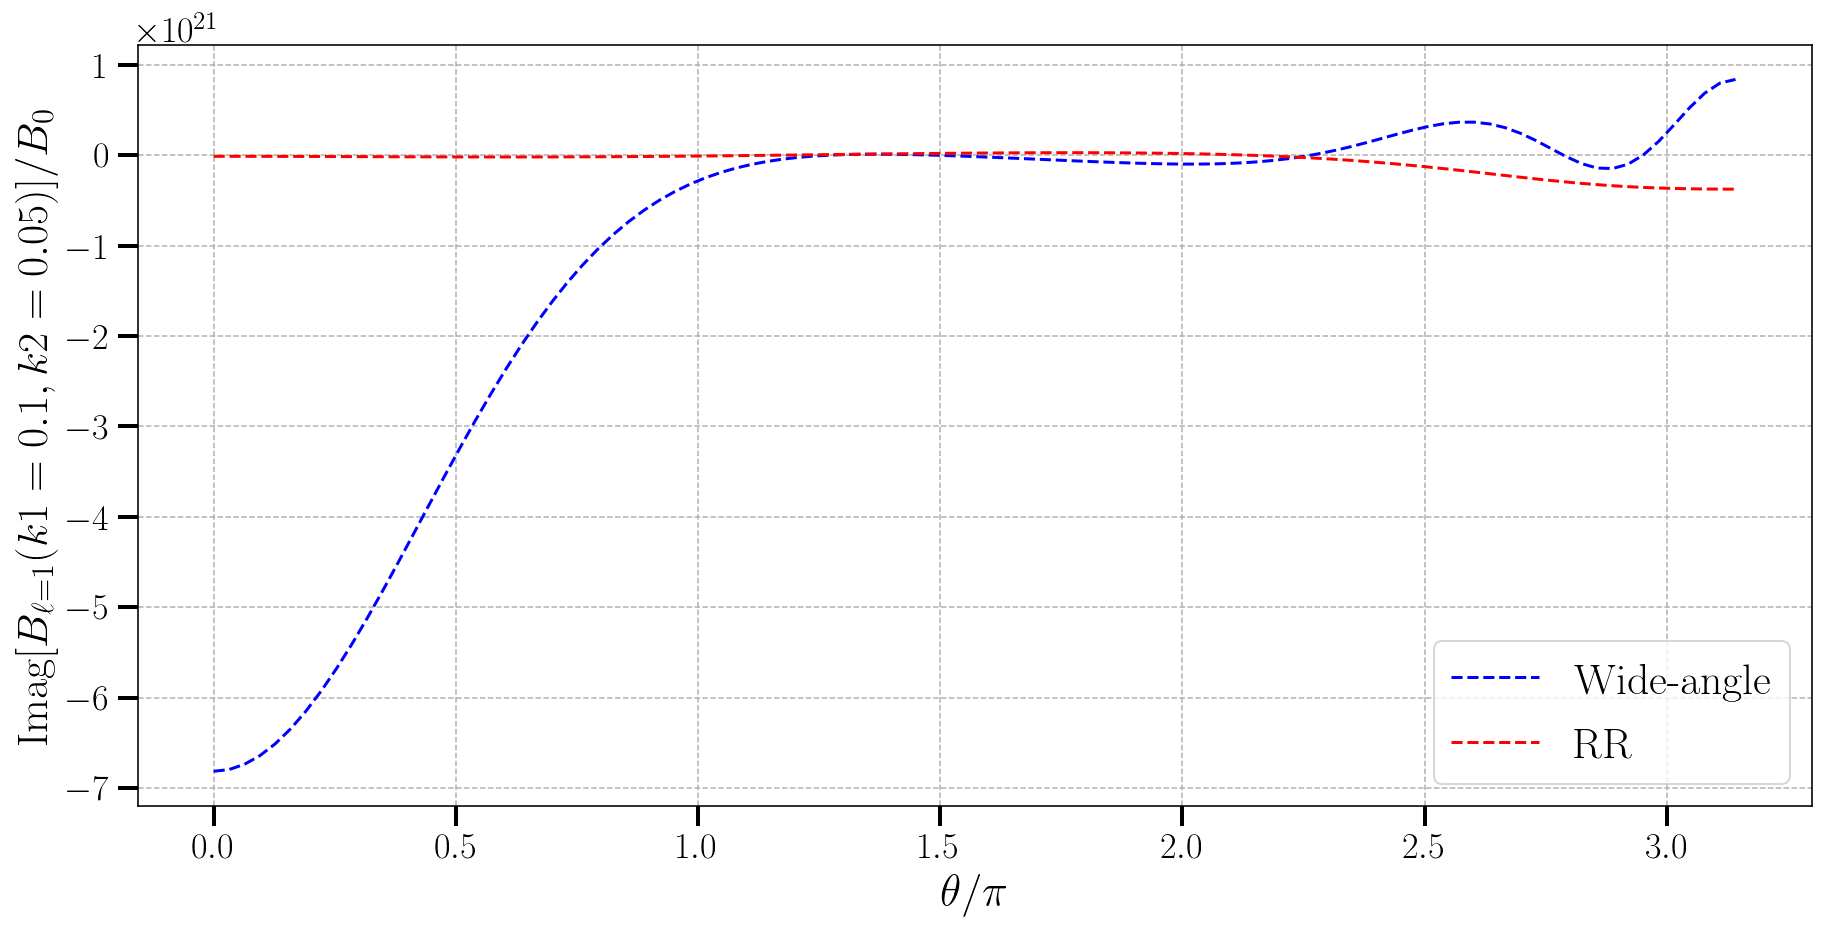

In [25]:
plt.figure(figsize=(15,7))

#ok get some equilateral triangles...
if False:
    k1 = np.geomspace(1e-4,1,1000)
    k2 = 0.9*k1
    k3 = 0.5*k1
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
else:
    k1=0.04;k2=k1/2
    theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))


zz=1

cosmo_functions = CosmologicalFunctions(cosmo)#'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

r=0;s=0
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')
plt.plot(theta,WA1_new.l1(params,r,s).imag,'--',color='blue',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'--',color='blue',label='Wide-angle')
#plt.plot(theta,WA1test1.l1(params,r,s).imag/GR0.l0(params),'-.',color='blue',label='Wide-angle')
#plt.plot(theta,(WA1test1.l1(params,r,s)+WA1test.l1(params,r,s)).imag/GR0.l0(params),'-.',color='black',label='Wide-angle')

r=1;s=0
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'--',color='red',label='RR')
plt.plot(theta,(RR1_new.l1(params,derivs,r,s).imag),'--',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='orange',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'--',color='orange',label='Wide-angle')
#plt.plot(theta,WA1test1.l1(params,r,s).imag/GR0.l0(params),'--',color='orange',label='Wide-angle')


r=0;s=1
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-.',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='grey',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'-.',color='grey',label='Wide-angle')
#plt.plot(theta,WA1test1.l1(params,r,s).imag/GR0.l0(params),'-.',color='grey',label='Wide-angle')


r=1/3;s=1/3;
#plt.plot(k3,WAGR.l0(params,betas,r,s).real/GR0.l0(params))
#plt.plot(k3,(r*WAGR.l0(params,betas,1,0)+s*WAGR.l0(params,betas,0,1)+(1-r-s)*WAGR.l0(params,betas,0,0)).real/GR0.l0(params))
#plt.plot(k3,RRGR.l0(params,derivs,betas,r,s).real/GR0.l0(params))
#plt.plot(k3,(r*RRGR.l0(params,derivs,betas,1,0)+s*RRGR.l0(params,derivs,betas,0,1)+(1-r-s)*RRGR.l0(params,derivs,betas,0,0)).real/GR0.l0(params))

#plt.plot(theta/np.pi,RR2.l0(params,derivs,1/3,1/3)/GR0.l0(params))
#plt.plot(theta/np.pi,WARR.l0(params,derivs,1/3,1/3)/GR0.l0(params))
#plt.plot(theta/np.pi,np.zeros_like(theta),color='grey',linestyle='--')

#plt.ylim(-1,1)
#plt.xlim(0,1)
plt.grid(ls='--',lw=0.75)

plt.legend()
plt.xlabel(r'$\theta/ \pi\,$')
plt.ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

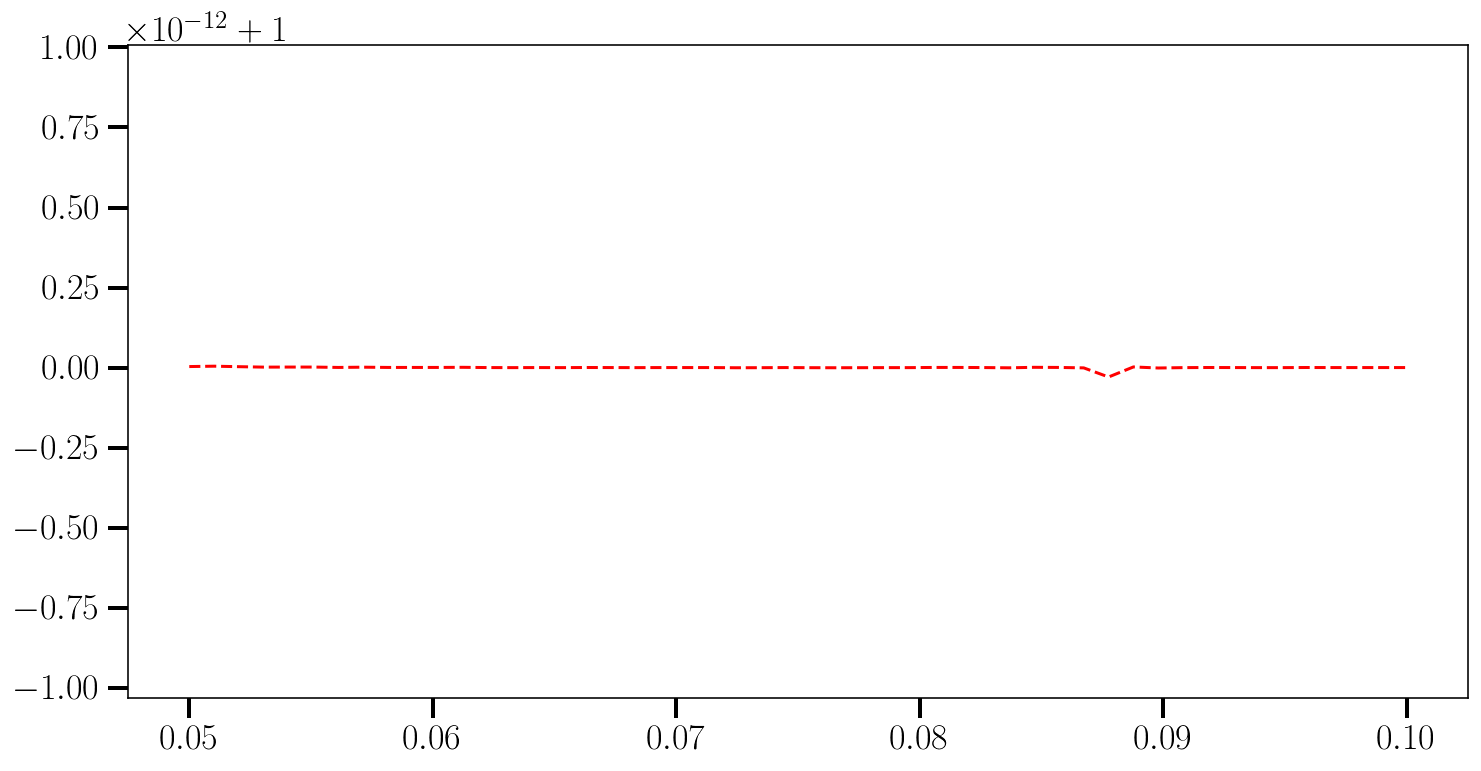

In [25]:
zz=1.0
k_fix = 0.01

if False:
    k1=0.08#np.linspace(0.01,0.1)#
    k2=k1/2
    theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
else:#squeeze
    k3 = np.linspace(0.05,0.1)
    k2= 0.05
    k1 = k2
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))


cosmo_functions = CosmologicalFunctions(cosmo)#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

plt.figure(figsize=(12,6))


r=0;s=0
#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='blue')
#plt.plot(k3,(RR2_.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-',label='WA/RR',color='orange')
r=1;s=0
#plt.plot(k3,(WA2.l0(params,r,s)),'--',label='WA',color='blue')
plt.plot(k3,(RR2_.l0(params,derivs,r,s))/(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'--',label='WA/RR',color='orange')
r=0;s=1
#plt.plot(k3,(WA2.l0(params,r,s)),'-.',label='WA',color='blue')
#plt.plot(k3,(RR2_.l0(params,derivs,r,s)),'-.',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')
r=1/3;s=1/3
#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='black')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')

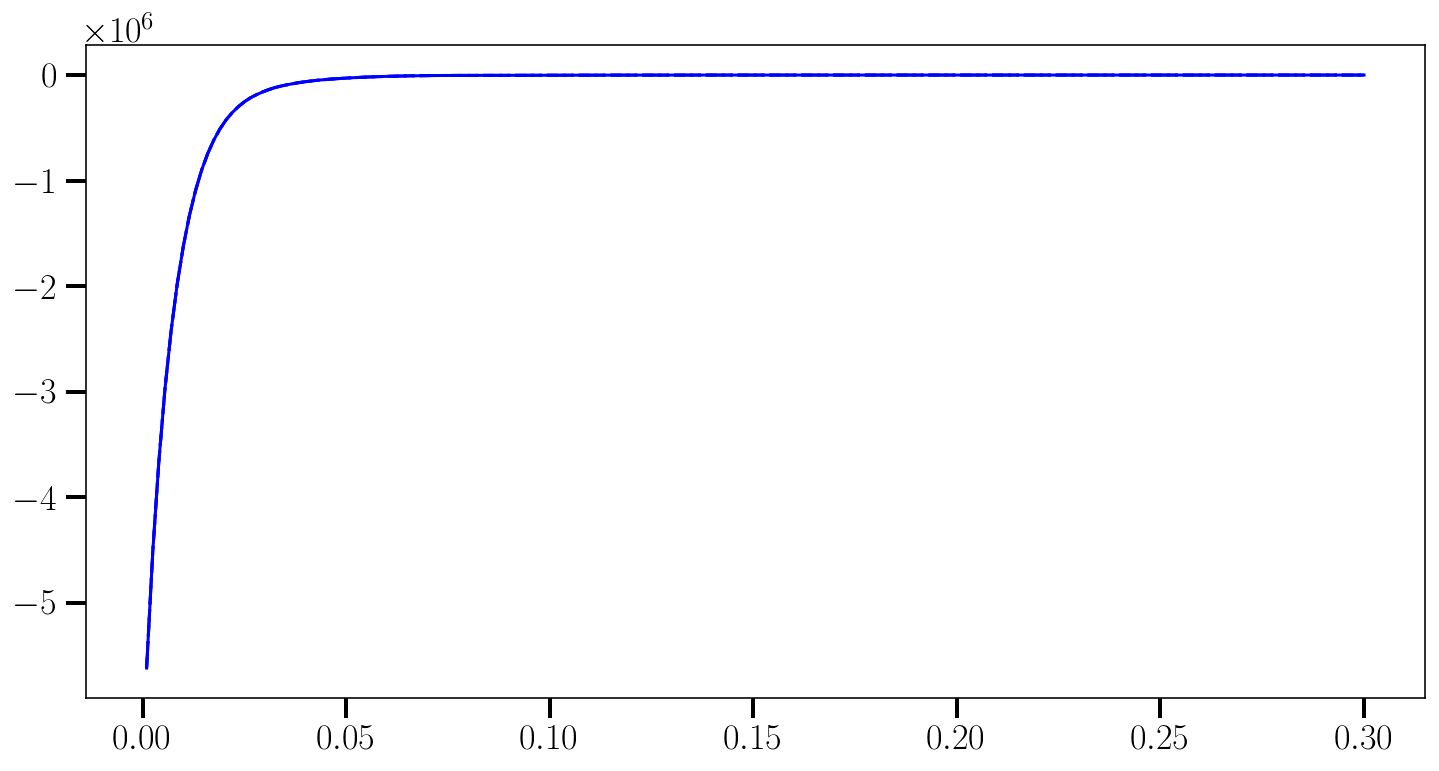

In [26]:
#zz=1.8

if False:
    k1=0.08#np.linspace(0.01,0.1)#
    k2=k1/2
    theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
elif False:#squeeze
    k1 = 0.05
    k2= 3*np.linspace(0.05,0.1)
    k3 = k2
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
else:
    k1 = k2 = k3 = np.linspace(0.001,0.3,200)
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

cosmo_functions = CosmologicalFunctions(cosmo)#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

plt.figure(figsize=(12,6))


r=0;s=0
plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-',label='WA/RR',color='orange')
r=1;s=0
plt.plot(k3,(WA2.l0(params,r,s)),'--',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'--',label='WA/RR',color='orange')
r=0;s=1
plt.plot(k3,(WA2.l0(params,r,s)),'-.',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')
r=1/3;s=1/3
#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='black')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='black')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')



In [27]:
zz=0.5

k1 = np.linspace(0.05,0.1)
k3 = k1
k2= 0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(100,zz,k1,k2,k3)


NameError: name 'GR0PNG' is not defined

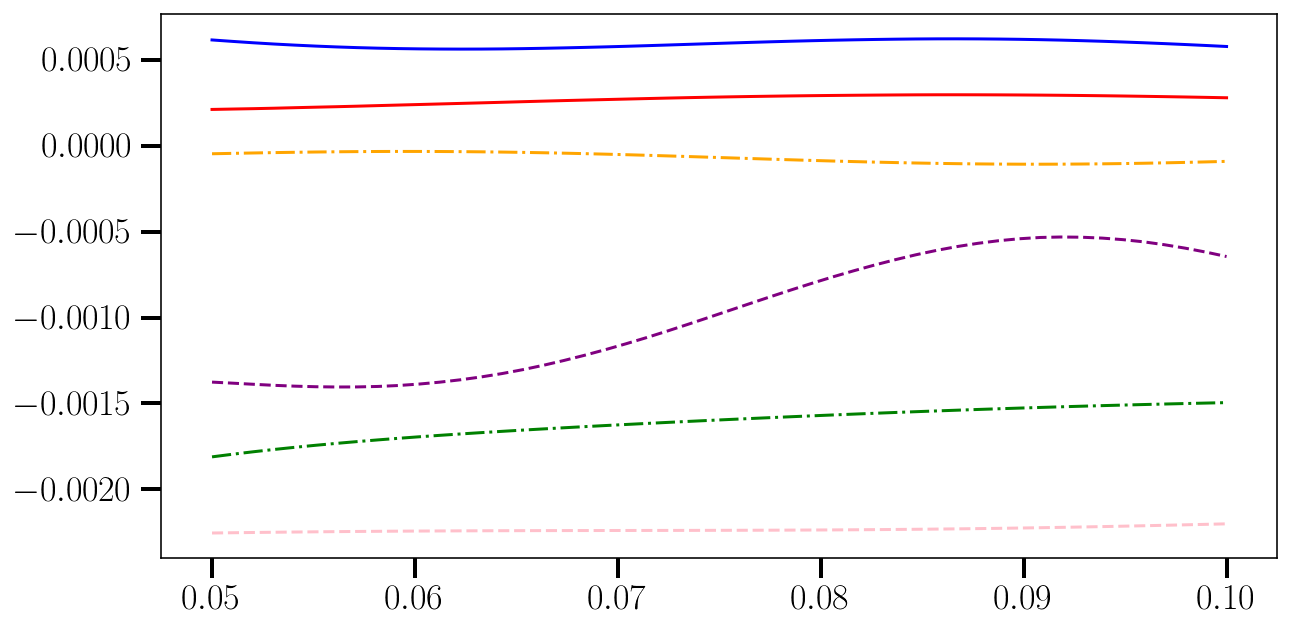

In [28]:
#so lets plot monopole...
plt.figure(figsize=(10,5))
r=0;s=0

justWS=WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)
#totalws = justwaRR+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
plt.plot(k3,GR2.l0(params,betas)/2/GR0.l0(params),'-.',label='GR',color='green')

plt.plot(k3,WA2.l0(params,r,s)/GR0.l0(params),'-',label='WA',color='blue')
plt.plot(k3,RR2.l0(params,derivs,r,s)/GR0.l0(params),'-',label='RR',color='red')
plt.plot(k3,WARR.l0(params,derivs,r,s)/GR0.l0(params),'-.',label='WA-RR',color='orange')

plt.plot(k3,WAGR.l0(params,betas,r,s)/GR0.l0(params),'--',label='WA-GR',color='purple')
plt.plot(k3,RRGR.l0(params,derivs,betas,r,s)/GR0.l0(params),'--',label='RR-GR',color='pink')

for i in [0.5,1.0,2.0]:
    PNGparams = cosmo_functions.get_PNGparams(i,zz,k1,k2,k3)
    plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='blue',alpha=0.8,label='fNL=%.1f'%i)#
    #plt.plot(k3,(GR0PNGtest.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='lime')

#plt.plot(k3,totalwa/GR0.l0(params),'--',color='black',label='RR+WA')
#plt.plot(k3,justwaRR/GR0.l0(params),'-',color='red',label='RR+WA')
#plt.plot(k3,total/GR0.l0(params),label='RR+WA+GR',color='black')
plt.xlabel('$ k_1=k_3 \,\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$\Delta B_{\ell=0}(k_1=k_3,k_2=0.01)|/B^N_{\ell=0}$')
#plt.plot(k3,np.zeros_like(k3),'--', color='black')
#plt.text(0.1,0.6,r"z=0.4 - DESI-like")
plt.xlim(0.05,0.10)
plt.legend(bbox_to_anchor=(0.85, 0.35, 0.5, 0.5))
plt.grid(ls='--',lw=0.75)
#plt.ylim(0,0.003)
plt.savefig('plots/second_order_lots.png', bbox_inches='tight', dpi=400)
plt.show()

In [ ]:
#test GR:
zz=1
k1 = np.linspace(0.0006,0.5,1000)
k3 = k1/2
k2= k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo)
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)

plt.figure(figsize=(10,6))
r=0;s=0

#totalwa = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
#total = totalwa+GR2.l0(params,betas)

#plt.plot(k3,np.abs(GR2.l0(params,betas)),'-.',label='GR',color='green')
#plt.plot(k3,np.abs(WA2.l0(params,r,s)),'--',label='Wide-angle',color='blue')
plt.plot(k3,np.abs(RR2.l0(params,derivs,r,s)),'--',label='redshift derivative',color='red')
#plt.plot(k3,np.abs(WARR.l0(params,derivs,r,s)),'-.',label='Mixed',color='orange')
#plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params)),'--',color='grey')
#plt.plot(k3,np.abs(WAGR.l0(params,betas,r,s)),'--',label='Wide-angle',color='purple')
#plt.plot(k3,np.abs(RRGR.l0(params,derivs,betas,r,s)),'--',label='Wide-angle',color='lime')

#plt.plot(k3,np.abs(totalwa),'--',label='Total',color='black')
#plt.plot(k3,np.abs(total),label='Total',color='black')

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)
plt.legend()
plt.show()

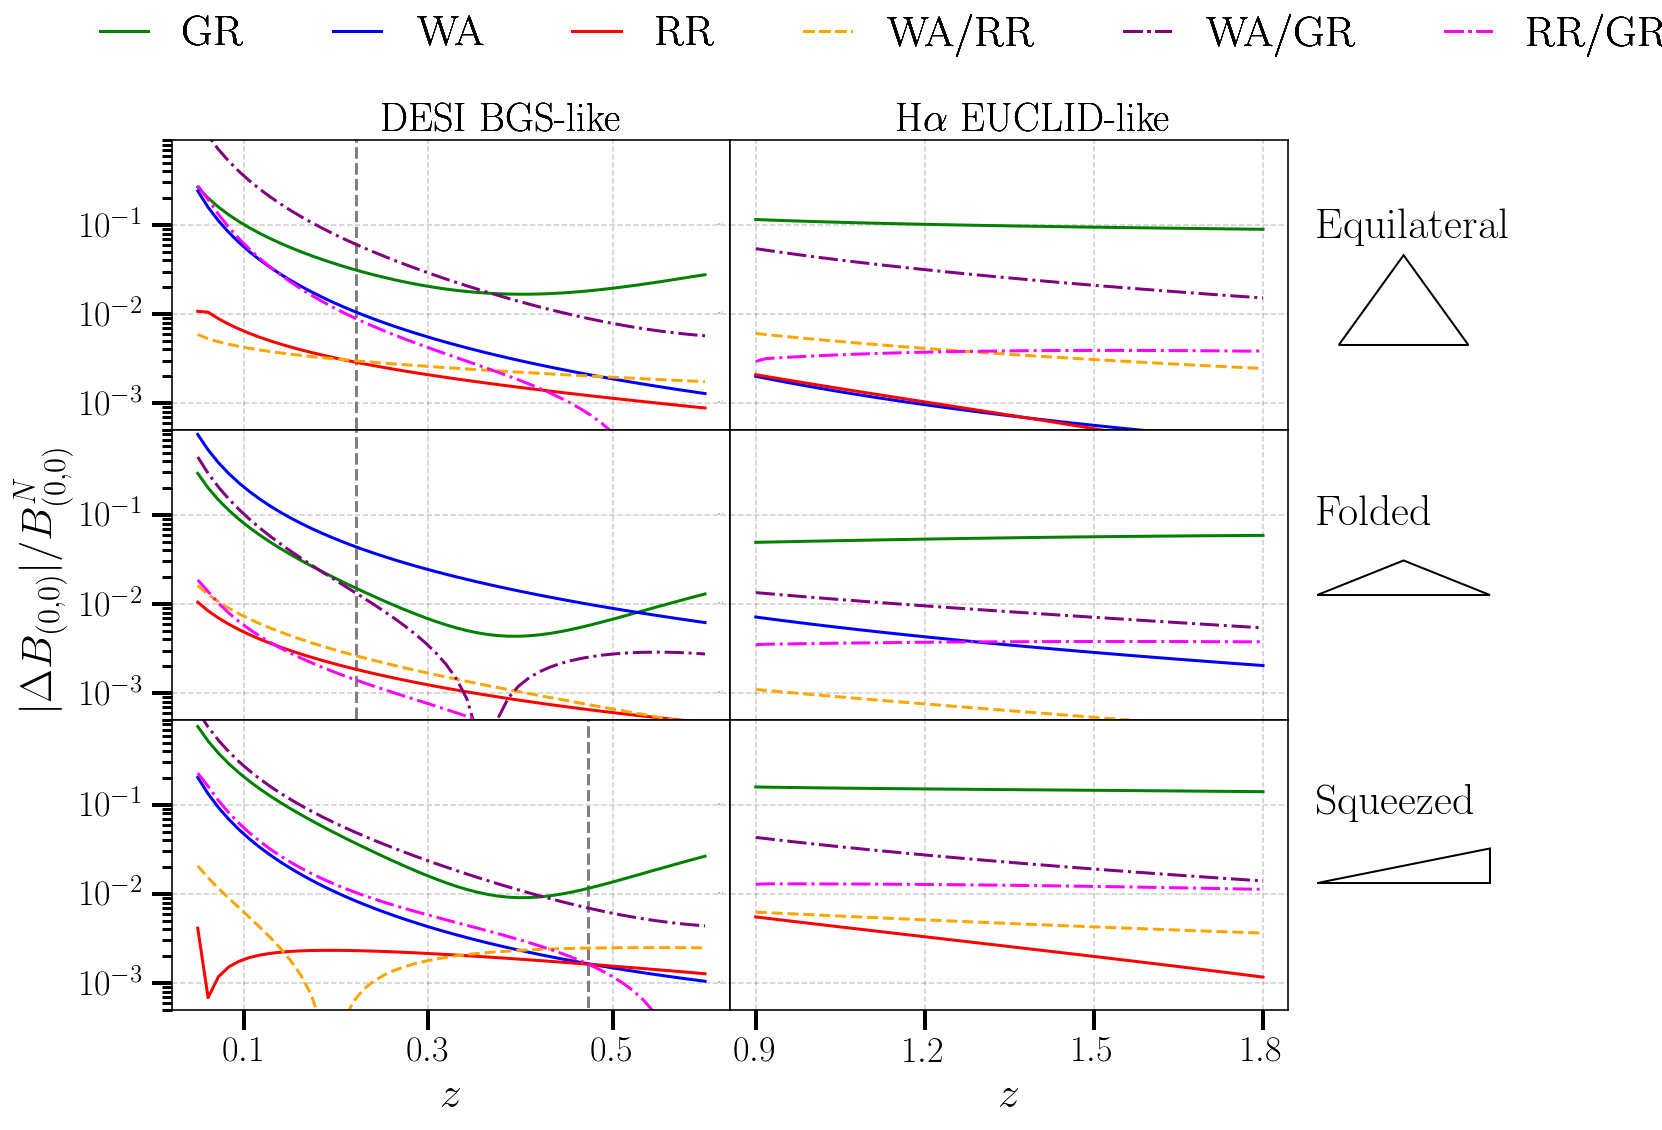

In [285]:
from matplotlib.patches import Polygon
def plot_3x2(first=True):
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

    # Create subplots with custom aspect ratios
    #axs = [fig.add_subplot(gs[0, i], aspect='10') for i in range(2)]  # Subplots in the first row

    #horizonatally
    for i in range(2):
        axs[0,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)
        axs[1,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)

    #vertically
    for i in range(3):
        axs[i,0].set_xticks(np.arange(0.1, 0.59, 0.2))
        axs[i,1].set_xticks(np.arange(0.9, 1.81, 0.3))

        #set triangle
        if i ==0: #
            k1 = 0.01
            k2 = k3 = k1
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        elif i==1: # folded
            k1 = 0.02
            k2 = k3 = 0.01
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        else: #squeezed
            k1 = k2 = 0.05
            k3 = 0.005
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

        for j in range(2):
            #choose which survey
            if j ==0:
                cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
                axs[0,j].text(0.25,1.1,'DESI BGS-like',fontsize=20)
            else:
                cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
                axs[0,j].text(1.15,1.1,r' H$\alpha$ EUCLID-like',fontsize=20)
            z_plot = cosmo_functions.z_survey

            params = cosmo_functions.get_params(k1,k2,theta,z_plot)
            derivs = cosmo_functions.get_derivs(z_plot)
            betas = cosmo_functions.get_beta_funcs(z_plot)

            norm = GR0.l0(params)
            
            #plot different contributions
            if first:#for first order stuff
                r=1;s=0
                axs[i,j].set_ylim(1.0001e-3,.9)
                axs[i,j].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',label='GR',color='green')
                axs[i,j].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'-',label='WA',color='blue')
                axs[i,j].plot(z_plot,np.abs(RR1.l1(params,derivs,r,s)/norm),'-',label='RR',color='red')
                axs[1,0].set_ylabel('$|B_{(1,0)}|/B^N_{(0,0)}$')
                axs[0,1].legend(ncol=3,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=0.5, borderpad=0)

            else:#for second order stuff
                r=s=1/3
                axs[i,j].set_ylim(5e-4,.9)
                #axs[i,j].plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
                #axs[i,j].plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
                if i ==0 and j ==0:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',label='GR',color='green')

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',label='WA',color='blue')
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',label='RR',color='red')
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',label='WA/RR',color='orange')

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',label='WA/GR',color='purple')
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',label='RR/GR',color='magenta')
                else:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',color='green')

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',color='blue')
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',color='red')
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',color='orange')

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',color='purple')
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',color='magenta')

                axs[1,0].set_ylabel('$|\Delta B_{(0,0)}|/B^N_{(0,0)}$')
                fig.legend(loc=[0.06,0.95],ncol=6,frameon=False,title_fontsize=13,handlelength=1.1, handleheight=0.5, borderpad=0)
                #xs[0,1].legend(ncol=1,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=0.5, borderpad=0)

            
            #we plot scale where it breaks down
            chi = 2*np.pi/k3
            axs[i,0].vlines(cosmo_functions.d_to_z(chi),0,1e+10,linestyles='--',color='grey',alpha=1)
            
            axs[i,j].set_yscale('log')
            
            axs[i, j].grid(ls='--', lw=0.75, color='k', alpha=0.2)
            
            axs[2,j].set_xlabel('$z$')
                        
            axs[i,1].get_yaxis().set_tick_params(which='both', size=0, labelsize=0)
            
    
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    base_x,base_y = 0.4,0.5
    # Plot the triangles on the additional axis
    for i in range(3):
        
        # Create an additional axis for the triangles
        ax_triangles = fig.add_axes([0.8, 0.6-0.25*i, 0.3, 0.3], frameon=False)
        ax_triangles.set_xticks([])
        ax_triangles.set_yticks([])
    
        triangle = Polygon(triple_triangle_coords(0.4,0.5)[i], closed=True, fill=None, edgecolor='black')
        ax_triangles.add_patch(triangle)
        ax_triangles.text(base_x, base_y+0.15, triangle_labels[i])

    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)
    if first:
        plt.savefig('plots/redshift_first.png', bbox_inches='tight', dpi=400)
    else:
        plt.savefig('plots/redshift_second.png', bbox_inches='tight', dpi=400)

plot_3x2(False)


In [ ]:
#x3
plot_3x2(True)

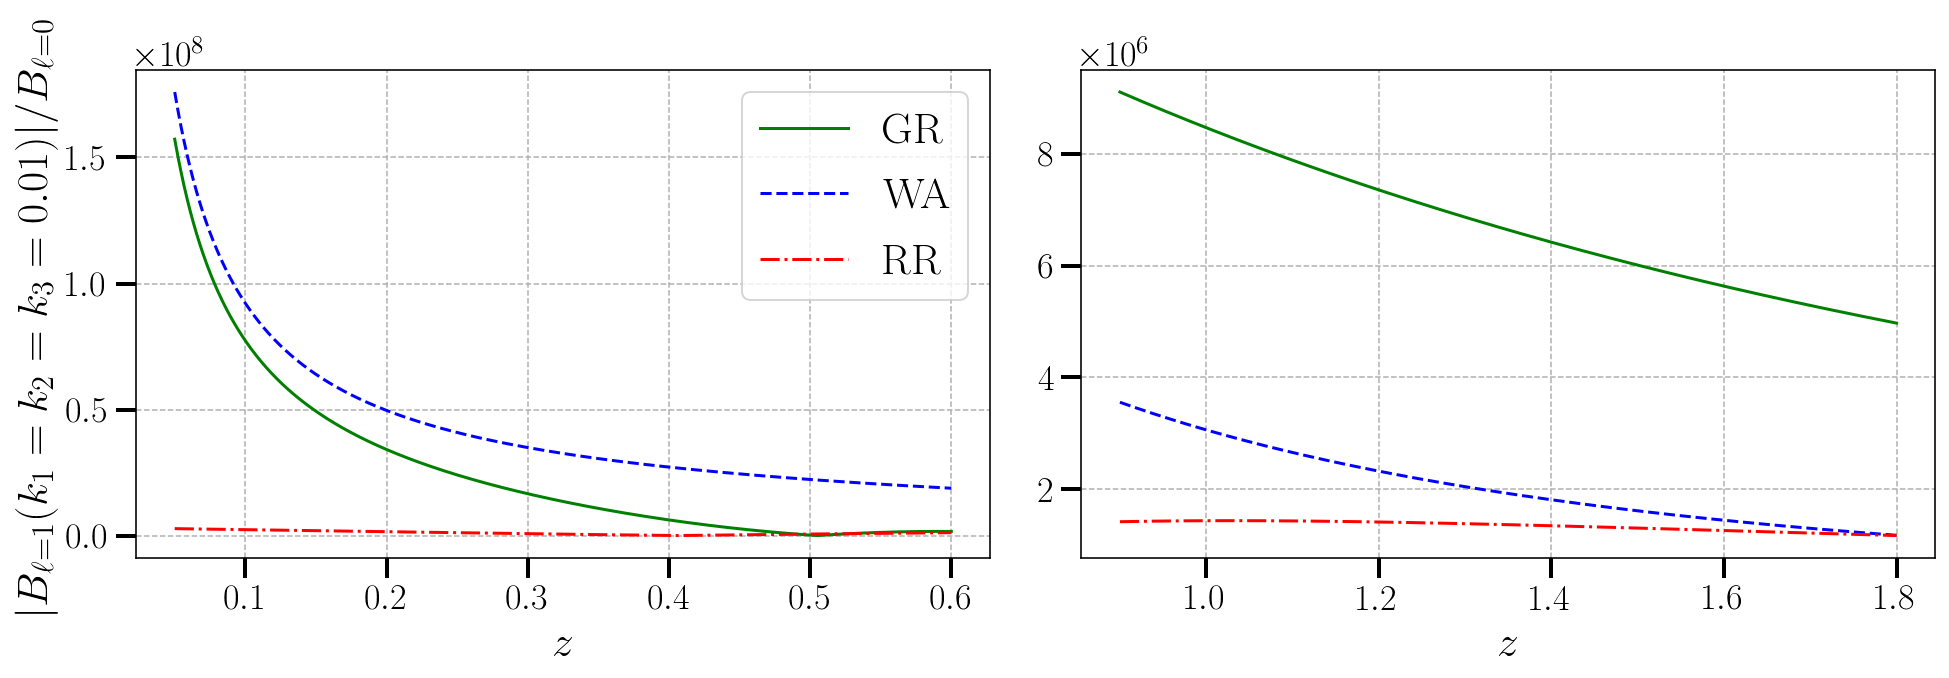

In [30]:
#plt.xlim(0,1)
z_plot = np.linspace(0.05,0.6,1000)#np.linspace(0.8,1.9,1000)#

k1 = 0.10
k2= k1
k3=0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,z_plot)
derivs = cosmo_functions.get_derivs(z_plot)
betas = cosmo_functions.get_beta_funcs(z_plot)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0

norm = C

if False:
    #totalwa = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
    #total = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)+GR2.l0(params,betas)

    plt.plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
    plt.plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
    #plt.plot(z_plot,(WA2.l0(params,r,s)/norm),'--',label='Wide-angle',color='blue')
    #plt.plot(z_plot,(RR2.l0(params,derivs,r,s)/norm),'--',label='redshift derivative',color='red')
    #plt.plot(z_plot,(WARR.l0(params,derivs,r,s)/norm),'-.',label='Mixed',color='orange')
    #plt.plot(z_plot,np.abs(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/norm,'--',color='grey')
    #plt.plot(z_plot,(WAGR.l0(params,betas,r,s)/norm),'--',label='',color='purple')
    #plt.plot(z_plot,(RRGR.l0(params,derivs,betas,r,s)/norm),'--',label='',color='lime')
    plt.legend()
    plt.grid(ls='--',lw=0.75)
    plt.xlabel('$z$')
    
else:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    for i in range(2):
        if i == 0:
            cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
            z_plot = np.linspace(0.05,0.6,1000)
        else:
            cosmo_functions = CosmologicalFunctions(cosmo)
            z_plot = np.linspace(0.9,1.8,1000)#np.linspace(0.05,0.6,1000)
      
        params = cosmo_functions.get_params(k1,k2,theta,z_plot)
        derivs = cosmo_functions.get_derivs(z_plot)
        betas = cosmo_functions.get_beta_funcs(z_plot)

        axs[i].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',label='GR',color='green')
        axs[i].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'--',label='WA',color='blue')
        axs[i].plot(z_plot,np.abs(RR1.l1(params,derivs,r,s)/norm),'-.',label='RR',color='red')
        axs[i].set_xlabel('$z$')
        axs[i].grid(ls='--',lw=0.75)
        #axs[i].set_yscale('log')
        
    axs[0].legend()
    axs[0].set_ylabel('$  |B_{\ell=1}(k_1=k_2= k_3=0.01)|/B_{\ell=0}$')
    plt.tight_layout()
    #plt.savefig('plots/redshift_first.png', bbox_inches='tight', dpi=400)
    
#plt.ylabel('$  B_{\ell=1}(k_1=k_2= k_3=0.01)\,\,[\mathrm{Mpc}/h]^6$')

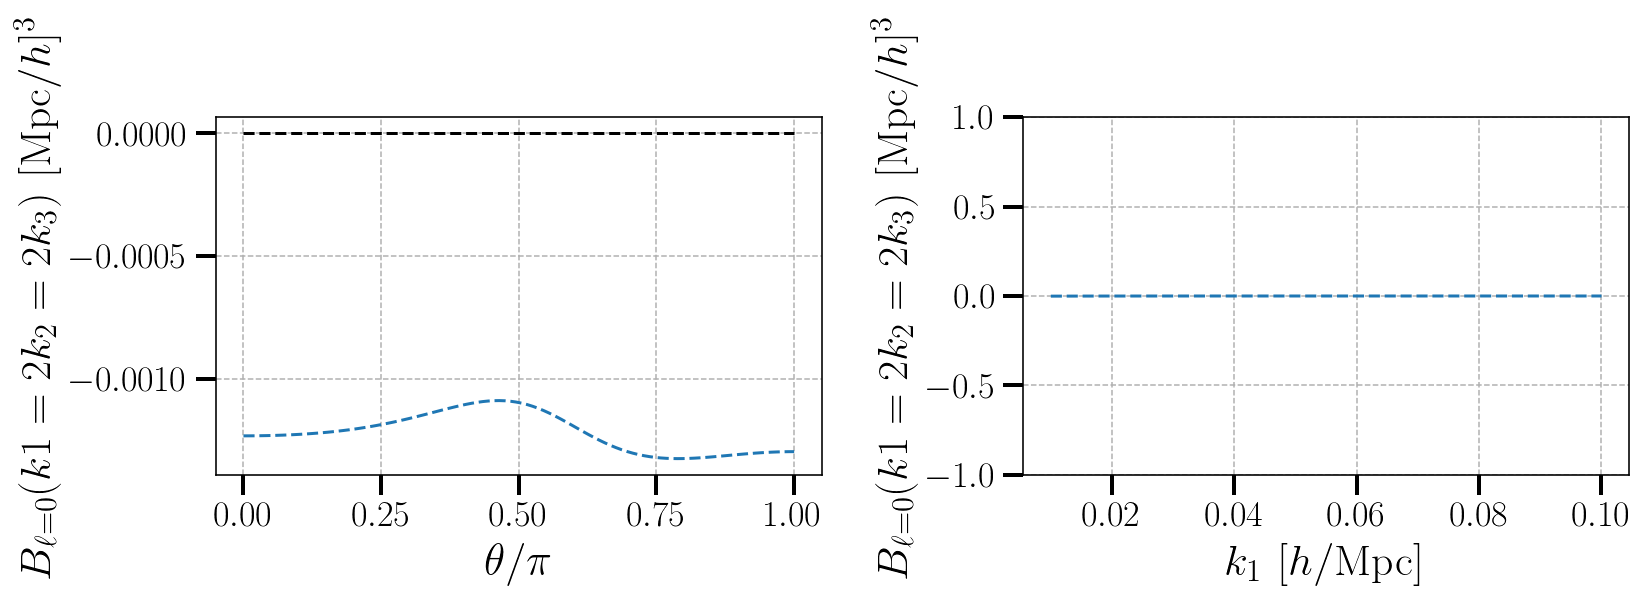

In [31]:
#for quadrupole

# Create a figure and a gridspec
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, width_ratios=[4,4])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])

zz=0.5;k1=0.04;k2=k1/4
theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0
#comb = WA2.l2(params,r,s)+RR2.l2(params,derivs,r,s)+WARR.l2(params,derivs,r,s)

norm = GR0.l0(params)
# Plot on each subplot
#ax1.plot(theta/np.pi,WA2.l2(params,r,s)/norm)
#ax1.plot(theta/np.pi,comb/norm)
ax1.plot(theta/np.pi,GR2.l2(params,betas)/norm,'--')

ax1.set_xlabel(r'$ \theta /\pi$')
ax1.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
ax1.plot(theta/np.pi,np.zeros_like(theta),'--', color='black')
ax1.grid(ls='--',lw=0.75)


k1=np.linspace(0.01,0.1,100);k2=k1;k3=1*k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)


# Plot on each subplot
#ax2.plot(k1,WA2.l2(params,r,s)/norm)
ax2.plot(k1,GR2.l2(params,betas)/norm,'--')
#ax2.plot(k1,comb/norm)
ax2.set_xlabel(r'$ k_1 \,\, [h/\mathrm{Mpc}]$')
ax2.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
#ax2.plot(k1,np.zeros_like(k1),'--', color='black')
ax2.set_ylim(-1,1)
ax2.grid(ls='--',lw=0.75)

plt.tight_layout()
plt.show()

In [33]:
#for sciccimarro comparison...
zz=1
k1=0.05#np.linspace(0.01,0.1)#
k2=k1/3
theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo)#'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)


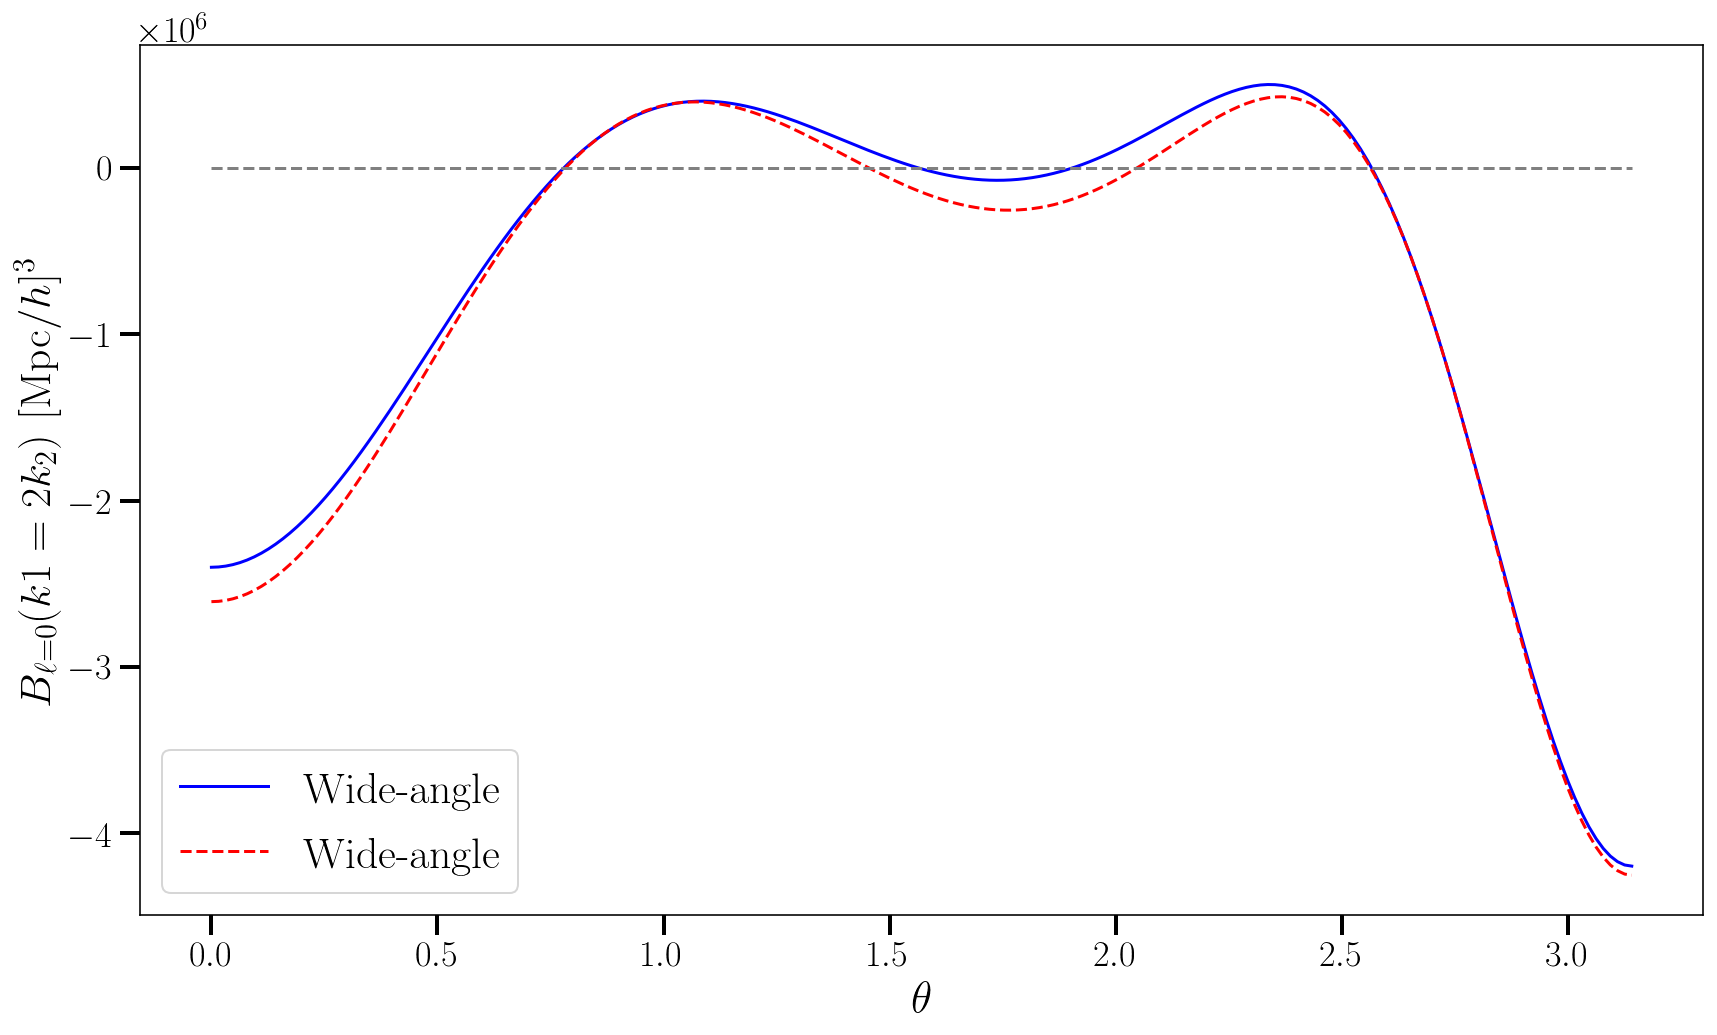

In [34]:
plt.figure(figsize=(14,8))
r=1/2;s=1/2

#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='redshift derivative')
plt.plot(theta,WA2.l0(params,r,s).real,'-',color='blue',label='Wide-angle')

plt.plot(theta,((1-r-s)*WA2.l0(params,0,0)+r*WA2.l0(params,1,0)+s*WA2.l0(params,0,1)).real,'--',color='red',label='Wide-angle')

"""
r=0;s=0
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')

r=1;s=0
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'--',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'--',color='blue',label='Wide-angle')

r=0;s=1
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-.',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-.',color='blue',label='Wide-angle')
#plt.plot(theta,GR1.l1(params,betas).imag/GR0.l0(params),'-',color='green',label='GR')
"""

#plt.plot(theta,(WA1.l1(params,r,s).imag+GR1.l1(params,betas).imag+RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='black')
plt.plot(theta,np.zeros_like(theta),'--',color='grey')
plt.xlabel(r'$ \theta $')
plt.ylabel('$ B_{\ell=0}(k1= 2 k_2) \,\,[\mathrm{Mpc}/h]^3$')
plt.legend()
#plt.xlim(1.5,2)
#plt.plot(theta,testoldder/d)
#plt.plot(theta,testold.real/(d),'-.',color='black')
#plt.plot(theta,testold.real/(d),'-.',color='grey')

In [33]:
def flat_bool(arr,slice_=None):#make flat and impose condtion k1>k2>k3
    if slice_ == None:
        return arr.flatten()[tri_bool.flatten()]
    else:
        return np.abs(arr[slice_].flatten()[tri_bool[slice_].flatten()])
#plots over all triangles     
def plot_all(ymin=1e+5,ymax=1e+10):
    zz=1
    cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)

    # define bins centres
    bin_width = 0.005
    k_bin = np.arange(bin_width,0.08,bin_width)

    k1,k2,k3 = np.meshgrid(k_bin,k_bin,k_bin,indexing='ij')

    #get theta from triagle condition - this create warnings from non-closed triangles
    # Handle cases where floating-point errors might cause cos_theta to go slightly beyond [-1, 1]
    cos_theta = (k3**2 - k1**2 - k2**2)/(2*k1*k2)
    cos_theta = np.where(np.isclose(np.abs(cos_theta), 1), np.sign(cos_theta), cos_theta) #need to get rid of rounding errors

    #if we want to suprress warnings from invalid values we can reset cos(theta) these terms are ignored anyway
    cos_theta = np.where(np.logical_or(cos_theta < -1, cos_theta > 1), 0, cos_theta)
    theta = np.arccos(cos_theta)
    
    params = cosmo_functions.get_params(k1,k2,theta,zz)

    #create bool for closed traingles with k1>k2>k3...
    tri_bool = np.full_like(k1,False).astype(np.bool_)
    fake_k = np.zeros_like(k1)# also create fake k- to plot over as in we define k1 then allow space to fill for all triangles there
    mesh_index = np.zeros_like(k1)
    tri_num = 0
    for i in range(k1.shape[0]+1):
        if i == 0:
            continue
        for j in range(i+1):#enforce k1>k2
            if j == 0:
                continue
            for k in range(i-j,j+1):# enforce k2>k3 and triangle condition |k1-k2|<k3
                if k==0:
                    continue

                #for indexing
                ii = i-1
                jj = j-1
                kk = k-1
                
                #print(ii,jj,kk)
                tri_bool[ii,jj,kk] = True
                mesh_index[ii,jj,kk] = tri_num
                tri_num +=1
                fake_k[ii,ii,ii] = 1 

    def flat_bool(arr):#make flat and impose condtion k1>k2>k3
        return np.abs(arr.flatten()[tri_bool.flatten()])

    plt.figure(figsize=(14,6))
    for i in range(len(flat_bool(fake_k))):
        if flat_bool(fake_k)[i]>0:
            plt.vlines(i+1,-1e+10,1e+10,linestyles='--',color='grey',alpha=0.6)

    def thin_xticks(arr,split=7,frac=3):#there are too many xticks at the start
        return np.concatenate((arr[:split][::frac],arr[split:]))
    
    tri_index = np.arange(len(flat_bool(k1))) 
    index_ticks = tri_index[flat_bool(fake_k)>0]+1#+1 as get where k1 steps not the equalateral before...
    ticks = k_bin
    _ = plt.xticks(thin_xticks(index_ticks)[1:], [round(i, 3) for i in thin_xticks(ticks)[1:]])
    
    plt.yscale('log')
    plt.ylim(ymin,ymax)
    plt.xlim(0,tri_index[-1])
    plt.xlabel('$k_1$ [h/Mpc]')
    
    #np.array([flat_bool(k1/bin_width),flat_bool(k2/bin_width),flat_bool(k3/bin_width)]).astype(np.int_).T
    
    #plot where k2 steps..
    for i in range(mesh_index.shape[0]):
        for j in range(mesh_index.shape[0]):
            plt.vlines(mesh_index[i,j,j]+1,0,1e+10,linestyles='--',color='grey',alpha=0.2)
    
    if False:
        #so lets find and shade squeezed limit
        is_squeeze = np.zeros_like(mesh_index)
        for i in range(mesh_index.shape[0]):
            for j in range(i+1):
                for k in range(i-j-1,j+1):
                    if k < 0:
                        continue
                    if i+1 > 3*(k+1) and j+1 > 3*(k+1):
                        is_squeeze[i,j,k] = 1e+8

        plt.fill_between(flat_bool(mesh_index), 0,1e+10, where=flat_bool(is_squeeze), color='gray', alpha=0.5)

    return params,derivs,betas,mesh_index,tri_bool

In [34]:
def plot_slice(contribution,which_slice=(10,10,10)):
    """plot triangles at correct triangle number"""
    x_tmp = mesh_index[which_slice]
    x = x_tmp[x_tmp>0]# remove triangles we are not considering 
    y = flat_bool(contribution,(which_slice))
    return x,y

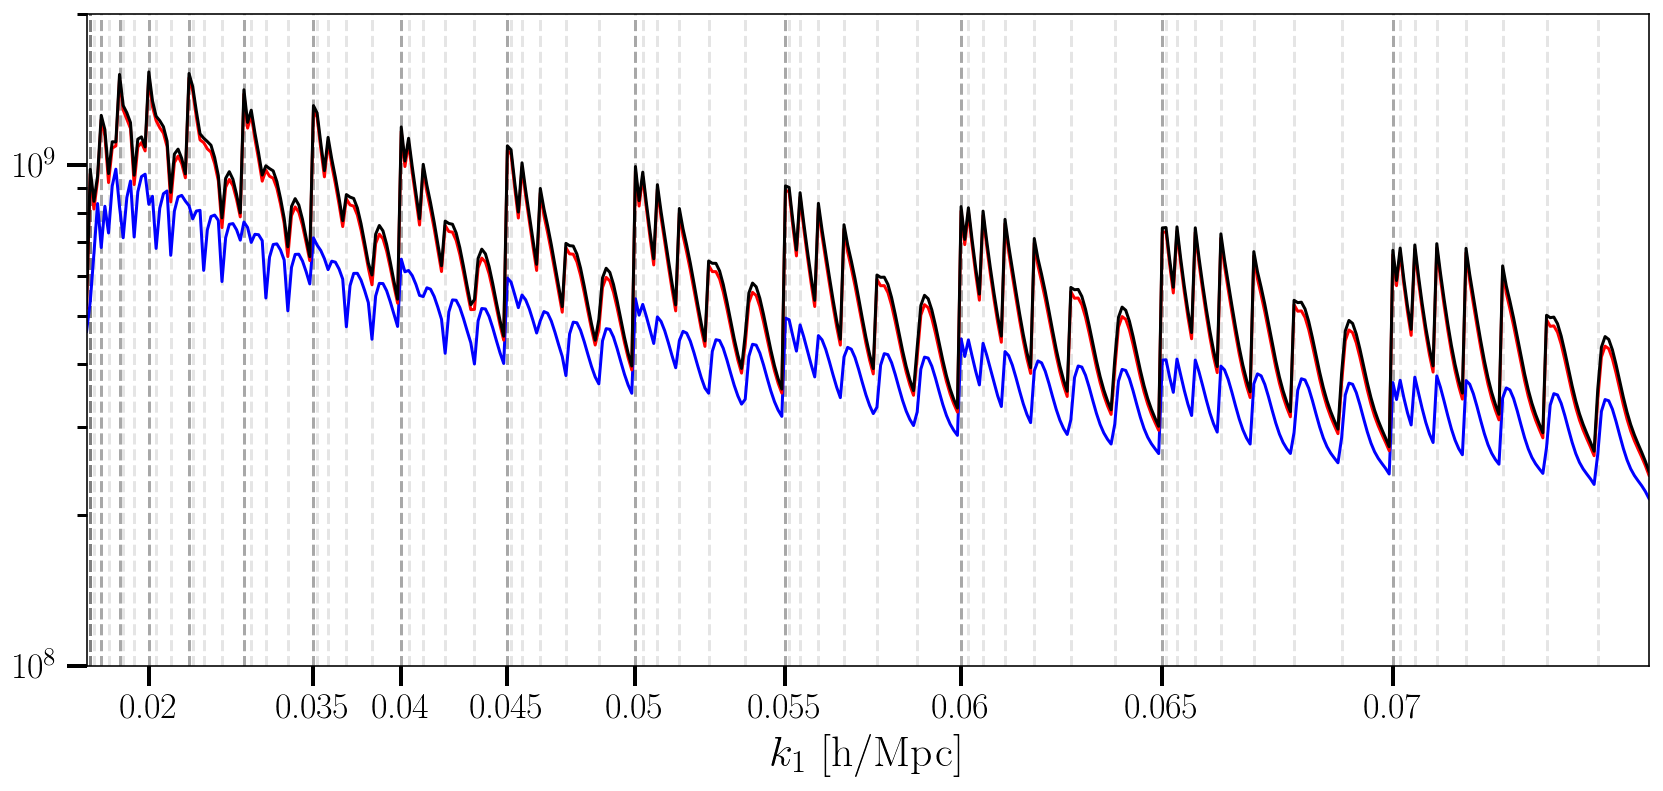

In [81]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+8,2e+9)

#plt.plot(flat_bool(np.sqrt(COV.N11(params,1e+3,V123))),'-',label='GR',color='blue')
plt.plot(flat_bool(np.sqrt(COV1.N11(params,1e+3,V123))),'-',label='GR',color='blue')
plt.plot(flat_bool(np.sqrt(COV1.N30(params,1e+3,V123))),'-',label='GR',color='red')
plt.plot(flat_bool(np.sqrt(COV1.N10(params,1e+3,V123))),'-',label='GR',color='black')



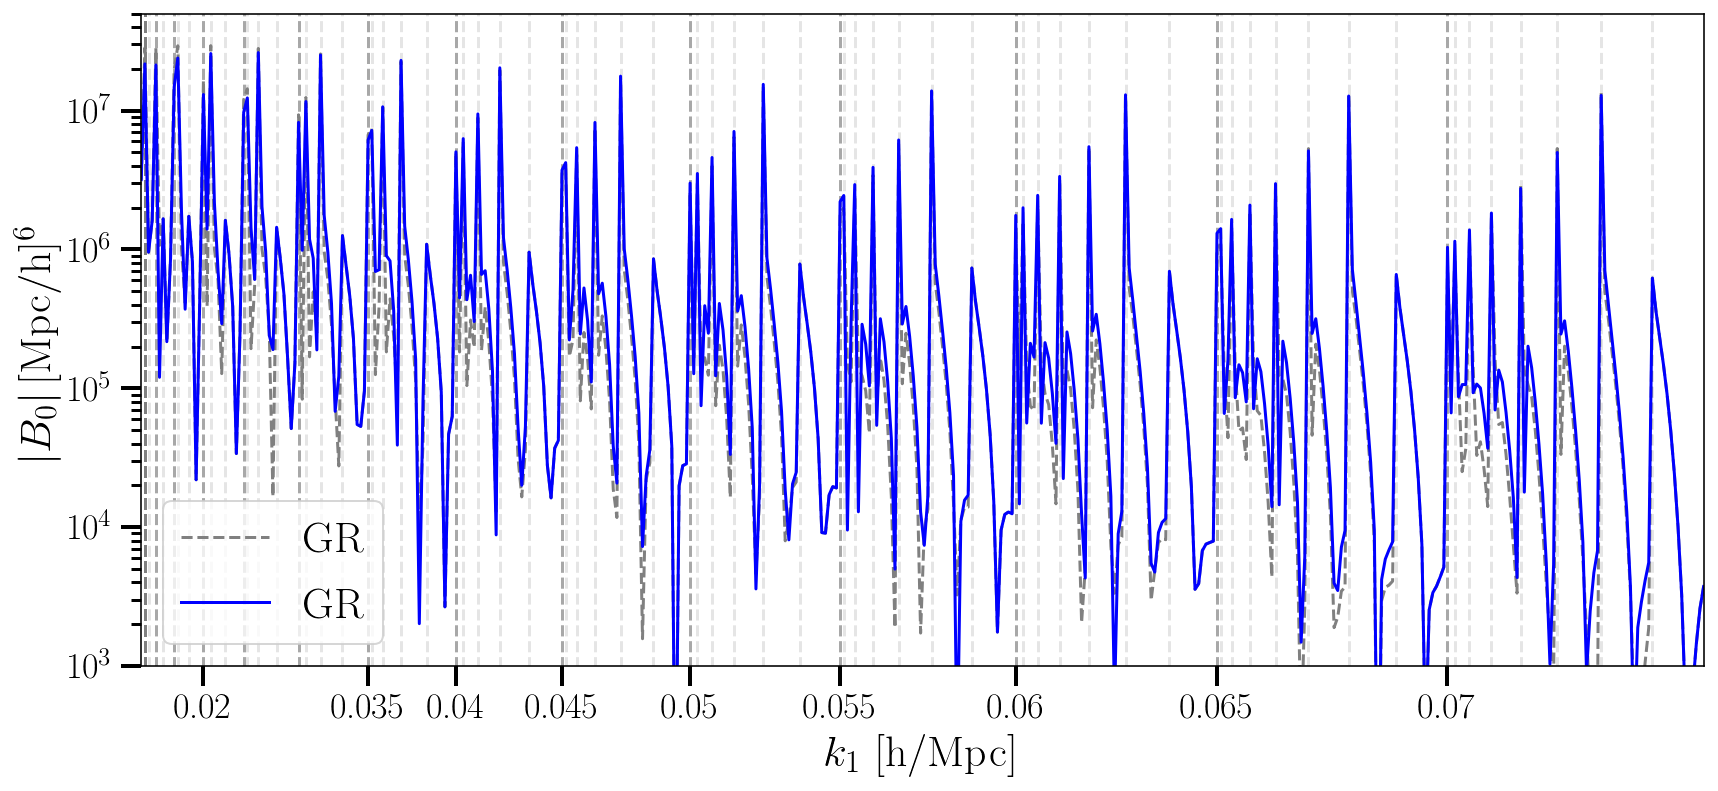

In [33]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+3,5e+7)

#so plot actual stuff
x,y = plot_slice(GR0.l0(params),(4,3,0))
#plt.plot(x,y,'o',label='N',color='black')

#plt.plot(flat_bool(is_squeeze),'o',label='N',color='black')

r=s=1/3
#plt.plot(flat_bool(GR0.l0(params)),'-',label='N',color='black')

r=0;s=0
#plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='GR',color='blue')
r=1;s=0
plt.plot(flat_bool(WA2.l0(params,r,s)),'--',label='GR',color='grey')
r=0;s=1
plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='GR',color='blue')


#plt.plot(flat_bool(GR2.l0(params,betas)),'-',label='GR',color='green')
#WAtot = WA2.l0(params,r,s)+WAGR.l0(params,betas,r,s)
#plt.plot(flat_bool(WAtot),'-',label='WA',color='blue')
#RRtot = RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
#plt.plot(flat_bool(RRtot),'-',label='RR',color='red')

#plt.plot(flat_bool(WAtot+RRtot),'-',label='WS',color='black')
#plt.plot(flat_bool(RR2.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(flat_bool(WARR.l0(params,derivs,r,s)),'-',label='WARR',color='green')
#plt.plot(flat_bool(WAGR.l0(params,betas,r,s)))
#plt.plot(flat_bool(RRGR.l0(params,derivs,betas,r,s)))

plt.ylabel(r'$|B_0| \, [\rm Mpc/h]^6$')
plt.legend()
plt.savefig('plots/monopole_all.png', bbox_inches='tight', dpi=400)

In [ ]:
params,derivs,betas,mesh_index,tri_bool = plot_all(2e-1,1e+2)
r=s=1/3
#plt.plot(flat_bool(is_squeeze),'o',label='N',color='black')

r=0;s=1
plt.plot(flat_bool(RR2.l0(params,derivs,1,0)/RR2.l0(params,derivs,0,0)),'-',label='GR',color='blue')

#plt.plot(flat_bool(GR2.l0(params,betas)/GR0.l0(params)),'-',label='GR',color='green')
#WAtot = WA2.l0(params,r,s)+WAGR.l0(params,betas,r,s)
#plt.plot(flat_bool(WAtot/GR0.l0(params)),'-',label='GR',color='blue')
#RRtot = RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
#plt.plot(flat_bool(RRtot/GR0.l0(params)),'-',label='GR',color='red')

#plt.plot(flat_bool((GR2.l0(params,betas)+WAtot+RRtot)/GR0.l0(params)),'-',label='WS',color='black')
plt.ylabel(r'$|\Delta B_0|/B_{N,0}$')

#plt.savefig('plots/monopole_all_norm.png', bbox_inches='tight', dpi=400)

In [ ]:
plt.plot(flat_bool((WAtot+RRtot)/GR0.l0(params))-flat_bool((WAtot)/GR0.l0(params)),'-',label='WS',color='black')
plt.xscale('log')

In [ ]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+5,1e+10)

plt.plot(flat_bool(GR0.l0(params)),'o',label='N',color='black')
#plt.plot(160,1e+9,'o')
if False:
    plt.plot(flat_bool(GR1.l1(params,betas)),'-',label='GR',color='green')
    plt.plot(flat_bool(GR2.l0(params,betas)),'-',label='GR',color='orange')
else:
    r=s=0
    #plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='blue')
    #plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='WA',color='orange')#plt.plot(flat_bool(R#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='red')R2.l0(params,derivs,r,s)),'-',label='RR',color='orange')
    plt.plot(flat_bool(WA1.l1(params,r,s)+RR1.l1(params,derivs,r,s)),'o',label='1st order WS',color='forestgreen')
    r=s=1/3
    plt.plot(flat_bool(WAtot+RRtot),'-',label='2nd order WS',color='royalblue')

plt.ylabel(r'$|B_0| \, [\rm Mpc/h]^6$')
plt.legend()
plt.savefig('plots/firstandsecond.png', bbox_inches='tight', dpi=400)

Text(0, 0.5, '$|B_1| \\, [\\rm Mpc/h]^6$')

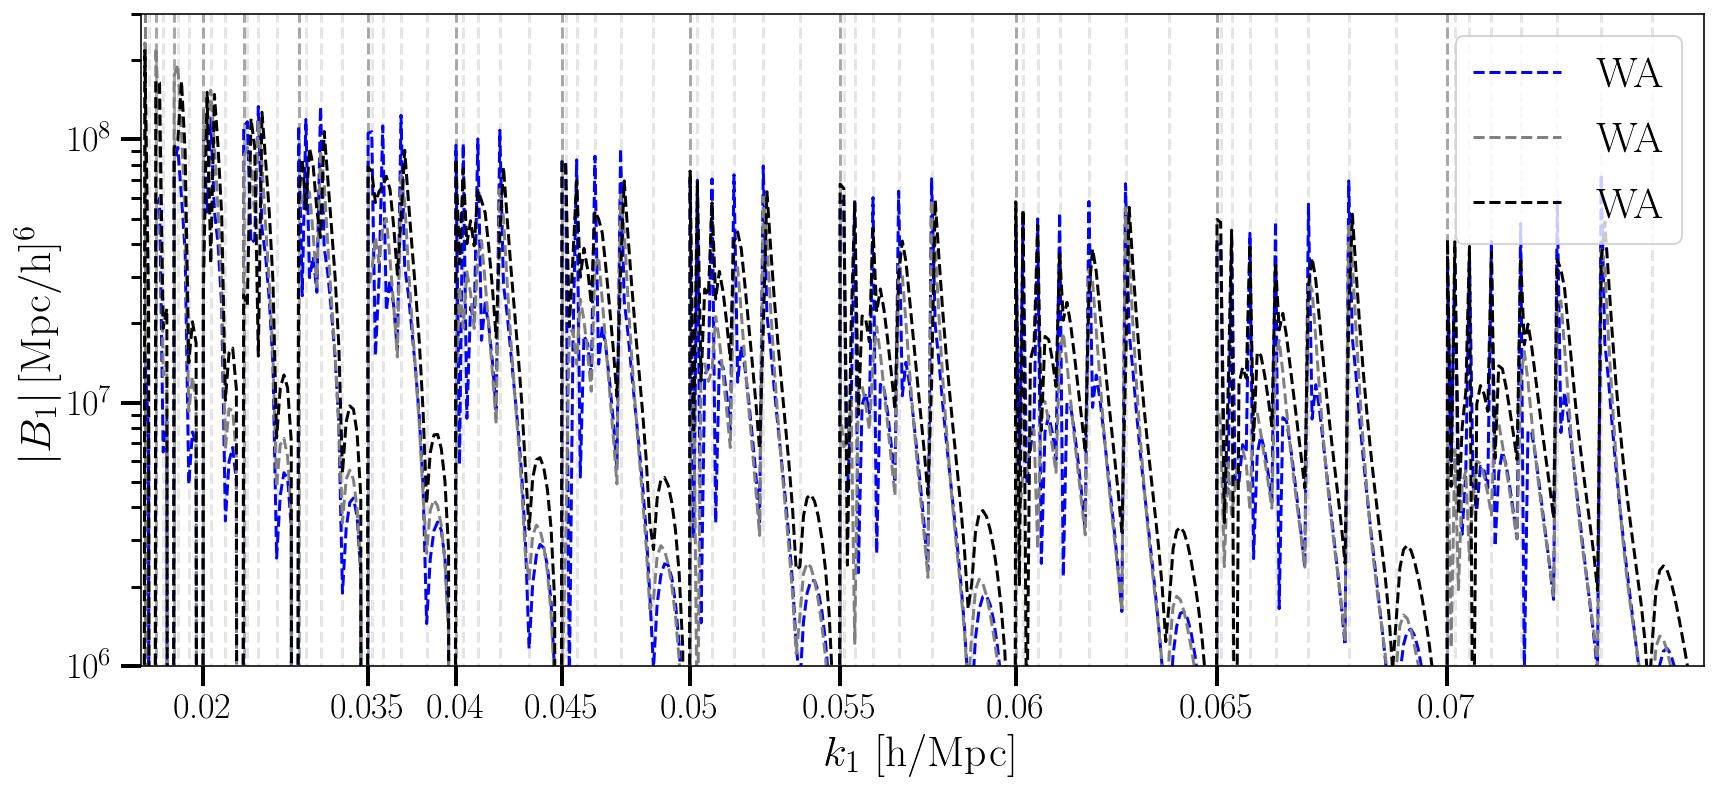

In [120]:
params,derivs,betas,all_k,tri_bool = plot_all(1e+6,3e+8)#-2e+8,2e+8
r=0;s=0
#plt.plot(flat_bool(GR1.l1(params,betas)),'-',label='GR',color='green')

#plt.plot(np.abs(flat_bool(WA1.l1(params,r,s).imag)),'-',label='WA',color='red',alpha=1)

#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='red')
r=1/3;s=1/3
plt.plot(np.abs(flat_bool(WA1.l1(params,r,s).imag)),'--',label='WA',color='blue',alpha=1)

#plt.plot(np.abs(flat_bool(WA1test.l1(params,r,s).imag)),'--',label='WA',color='grey',alpha=1)#d.e - smaller for x1
#plt.plot(np.abs(flat_bool(WA1test1.l1(params,r,s).imag)),'--',label='WA',color='black',alpha=1)#q.e

#plt.plot(flat_bool(WA1test1.l1(params,r,s))-flat_bool(WA1test.l1(params,r,s)),'--',label='WA',color='black',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s).imag),'-',label='RR',color='red')
r=1;s=0
#plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='red',alpha=1)
#plt.plot(flat_bool(WA1test.l1(params,r,s)),'--',label='WA',color='yellow',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='black')
r=0;s=1
#plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='red',alpha=1)
#plt.plot(flat_bool(WA1test.l1(params,r,s)),'-',label='WA',color='orange',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'--',label='RR',color='brown')
plt.legend()
plt.ylabel(r'$|B_1| \, [\rm Mpc/h]^6$')
#plt.savefig('plots/dipole_all.png', bbox_inches='tight', dpi=400)

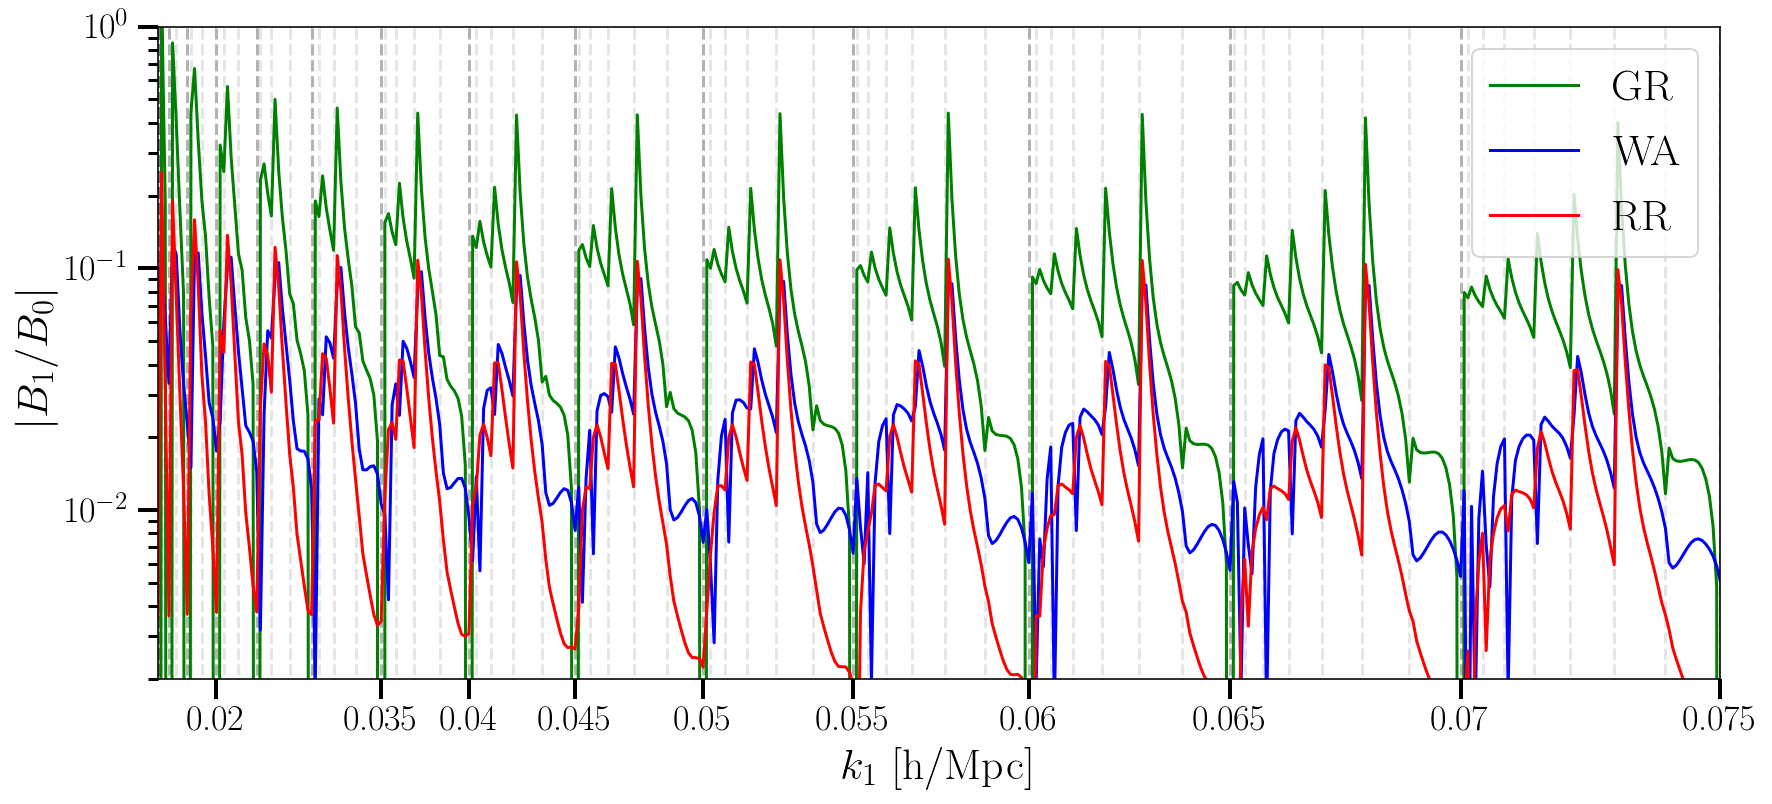

In [205]:
params,derivs,betas,all_k,tri_bool = plot_all(2e-3,1e+0)
r=0;s=0
plt.plot(flat_bool((GR1.l1(params,betas))/GR0.l0(params)),'-',label='GR',color='green')
#plt.plot(flat_bool((WA1.l1(params,r,s)+RR1.l1(params,derivs,r,s))/GR0.l0(params)),'-',label='WS',color='black')
plt.plot(flat_bool(WA1.l1(params,r,s)/GR0.l0(params)),'-',label='WA',color='blue')
plt.plot(flat_bool(RR1.l1(params,derivs,r,s)/GR0.l0(params)),'-',label='RR',color='red')
plt.legend()
plt.ylabel(r'$|B_1/B_0|$')
plt.savefig('plots/dipole_all_norm.png', bbox_inches='tight', dpi=400)

In [206]:
def plot_rs(bk,vmax=0.1,vmin=1): #plot triangle with mask!
    plt.figure(figsize=(14,6))
    # Create the colormap plot
    im = plt.imshow(np.abs(bk.T), extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(np.abs(bk[np.abs(bk)>0]).min(), vmax=np.abs(bk).max()))#,vmin=0,vmax=vmax)#
    #im = plt.imshow((bk.T), extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#
    
    cbar = plt.colorbar(im)#format='%.0e'
    cbar.set_label(r"$B_{\ell=1}(k_1=0.1,k_2,k_3)$")
    
    # Add labels and title
    plt.xlabel('$r$')
    plt.ylabel('$s$')

    #so masking 
    # Create a mask for the triangular region
    size = int(1e+3)
    r = np.linspace(0.0, 1, size,dtype=np.float32)
    s = np.linspace(0.0, 1,  size,dtype=np.float32)
    rr,ss = np.meshgrid(r,s)
    mask = np.where((rr + ss <= 1),np.nan,1)
    im = plt.imshow(mask, extent=[0, 1, 0.0, 1], interpolation='bilinear', origin='lower', cmap='binary')
    
    plt.grid(ls='--',lw=0.75,color='k',alpha=0.1)
    plt.plot(1/3,1/3,'x',markersize=10,color='black')
    x_bound = [0,1]
    y_bound = [1,0]#
    #plt.text(0.06,0.55,'$r=s=1/3$')
    plt.plot(x_bound,y_bound,'k',linewidth=3)
    # Show the plot
    plt.show()

In [207]:
def plot_rs_multi(bk,vmin,vmax): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(12, 5))

    # Define gridspec with 1 rows and 3 columns
    gs = GridSpec(1, 3, width_ratios=[3, 3, 3])

    # Create subplots with custom aspect ratios
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]  # Subplots in the first row

    fig.subplots_adjust(wspace=0)
    # Create the colormap plot
    im0 = axs[0].imshow(np.abs((bk[0]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im1 = axs[1].imshow(np.abs((bk[1]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im2 = axs[2].imshow(np.abs((bk[2]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#

    #im0 = axs[0].imshow(((bk[0]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im1 = axs[1].imshow(((bk[1]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im2 = axs[2].imshow(((bk[2]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.81, 0.25, 0.02, 0.5])
    cbar = fig.colorbar(im2, cax=cbar_ax,ticks=[0.01, 0.1, 1])
    #cbar.set_label(r"$ |B^{\rm wa}_{\ell=1}(k_1=0.05)|/B^{\rm pp}_{\ell=0}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    cbar.set_label(r"$ |B^{\rm WA_2}_{(0,0)}|/B^{\rm N}_{(0,0)}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    
    x_bound = [0,1]
    y_bound = [1,0]
    
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    base_x,base_y = 0.55,0.85
    # Plot the triangles on the additional axis
    for i in range(3):
        triangle = Polygon(triple_triangle_coords(base_x,base_y)[i], closed=True, fill=None, edgecolor='black')
        axs[i].add_patch(triangle)
        #axs[i].text(base_x-0.1, base_y+0.15, triangle_labels[i])
       
    
    axs[0].set_ylabel('$s$')
    for i in range(3):
        
        axs[i].plot(x_bound,y_bound,'k',linewidth=3)
        #axs[i].text(0.08,0.55,r'$\boldsymbol{d}=\boldsymbol{x}_%d$'%(i+1),fontsize=20)
        axs[i].set_xlabel('$r$')
        axs[i].set_xticks(np.arange(0.2, 0.8, 0.2))
        axs[i].plot(1/3,1/3,'x',markersize=10,color='black')
        #axs[i].set_box_aspect(aspect=0.8)
        #axs[i].set_xlim(0,1)
        #axs[i].set_ylim(0.5,1)
        #axs[i].grid(ls='--',lw=0.75,color='k',alpha=0.1)
        
        if i!=0:
            axs[i].yaxis.set_major_locator(plt.NullLocator())
            
    axs[0].set_yticks(np.arange(0, 1.01, 0.2))
    # Show the plot
    plt.savefig('plots/rs_tri.png', bbox_inches='tight', dpi=400)
    plt.show()

In [ ]:
#bk_rs_WA2 = np.zeros((3,500,500))
#bk_rs_RR2 = np.zeros((3,500,500))
#bk_rs_RRGR = np.zeros((3,500,500))
bk_rs_WARR = np.zeros((3,500,500))
#bk_mono = np.zeros(3)

In [1715]:
#lets plot as a function of r and s
def rs_plot(r, s, zz):
    """Get array of"""
    bk = np.zeros((len(r),len(s)))
    
    #set triangle
    if type_tri ==0: #equilateral
        k1 = 0.01
        k2 = k3 = k1
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    elif type_tri==1: # folded
        k1 = 0.02
        k3 = k2 = k1/2
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    else: #squeezed
        k1 = k2 = 0.05
        k3 = 0.005
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    
    cosmo_functions = CosmologicalFunctions(cosmo)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)
    params = cosmo_functions.get_params(k1,k2,theta,zz)
    
    bk_mono = GR0.l0(params)
    print(bk_mono)
    rr,ss = np.meshgrid(r,s,indexing='ij')
    if False:
        bk_temp = RR1.l1(params,derivs, rr, ss).imag
        #bk_temp = WA1.l1(params, rr, ss).imag
    else:
        #bk_temp = RR2.l0(params,derivs, rr, ss)
        #bk_temp = WAGR.l0(params,betas, rr, ss)
        bk_temp = WARR.l0(params,derivs, rr, ss)
        #bk_temp = WA2.l0(params, rr, ss)

    which_rs = (rr + ss <= 1)#restrict to r+s \leq 1
    return np.where(which_rs,bk_temp,0),bk_mono

r = np.linspace(0, 1, 500)
s = np.linspace(0, 1, 500)

for type_tri in range(3):
    #bk_rs_RR2[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)
    bk_rs_WARR[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)
    #bk_rs_WA2[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)

In [1726]:
plot_rs_multi(bk_rs_WAGR,1e+6,1e+8)#this is interesting

In [1719]:
plot_rs_multi(bk_rs_WARR/bk_mono[:,np.newaxis,np.newaxis],5e-3,1e-2)#this is interesting
#plot_rs_multi(bk_rs_RRGR/bk_mono[:,np.newaxis,np.newaxis],5e-4,1e-2)#this is interesting
#plot_rs_multi(bk_rs_WAGR/bk_mono[:,np.newaxis,np.newaxis],1e-3,5e-2)#this is interesting

In [1709]:
#plot_rs_multi((bk_rs_WA1)/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)

#plot_rs_multi(bk_rs_RR1/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)
#plot_rs_multi((bk_rs_WA1+bk_rs_RR1)/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)

plot_rs_multi(bk_rs_WA2/bk_mono[:,np.newaxis,np.newaxis],1e-3,7e-3)
plot_rs_multi(bk_rs_RR2/bk_mono[:,np.newaxis,np.newaxis],2e-4,5e-3)

In [662]:
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])

plot_rs(bk_rs_RR2[0]/bk_mono[0])#,2e+7,vmin=8e+6)
plot_rs(bk_rs_RR2[1]/bk_mono[1])
plot_rs(bk_rs_RR2[2]/bk_mono[2])
#plot_rs(bk_rs_RR1,1e+7,vmin=1e+5)

In [102]:
#bk_0 = {}
#bk_1 = {}
#bk_2 = {}
bk_wa ={}#for x1,x2,x3 plot

In [426]:
bk_png = {}

In [138]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", message="invalid value encountered in divide")#hack
warnings.filterwarnings("ignore", message="invalid value encountered in arccos")

# Define the function
#@jit
def triangle_plot(x, y, zz,r=0,s=0):
    """Get array of"""
    bk_temp = np.zeros((len(x),len(y)))
    
    cosmo_functions = CosmologicalFunctions(cosmo)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)

    xx,yy = np.meshgrid(x,y,indexing='ij')#create meshgrid where xx= k3/k1, yy= k2/k1
    
    #array version:
    k1 = 0.05 
    k3 = xx*k1
    k2 = yy*k1
    #get theta from triagle condition - this create warnings from non-closed triangles
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    
    params = cosmo_functions.get_params(k1,k2,theta,zz)
    
    #bk_temp = RR1.l1(params,derivs, r, s).imag
    bk_temp = WA1.l1(params, r, s).imag
    #bk_temp = GR1.l1(params,betas).imag
    #bk_temp = GR0.l0(params).real
    
    #bk_temp = WA2.l0(params, r, s).real
    #bk_temp = WARR.l0(params,derivs, r, s).real
    #bk_temp = WAGR.l0(params,betas, r, s).real
    #bk_temp = RR2.l0(params,derivs, r, s).real
    #bk_temp = RRGR.l0(params,derivs,betas, r, s).real
    #bk_temp = GR2.l0(params,betas).real
    if False:
        PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2_,k3)
        bk[i][which_k2] = GR0PNG.l0(params,PNGparams).real
        
    which_k2 = np.logical_and((yy > 1 - xx), (yy>xx))#restrict to closed triangles
    
    print("done")
    return np.where(which_k2,bk_temp,0)#bk_temp#

xx = np.linspace(0.01, 1, 500)
yy = np.linspace(0.495, 1, 500)

zz=1.0
if False:
    r=0;s=0
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)#so lets get key 
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)
    r=1;s=0
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)
    r=0;s=1
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)

else:
    r=0;s=0
    mono_key = "z=%.2f"% (zz)
    #bk_0[mono_key] = triangle_plot(xx,yy,zz,r,s)
    key = mono_key + "_WA"
    bk_1[key] = triangle_plot(xx,yy,zz,r,s)
    #k2_mesh = triangle_plot(xx,yy,zz,r,s)
    #bk_png[mono_key] = triangle_plot(xx,yy,zz,r,s)

In [62]:
print(bk_1.keys())

In [165]:
def plot_triangle(bk,vmax=1,vmin=1): #plot triangle with mask!
    plt.figure(figsize=(12,4))
    # Create the colormap plot
    im = plt.imshow(np.abs(bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(1e-2*np.max(np.abs(bk)[np.abs(bk)>0]), vmax=np.max(np.abs(bk))))#,vmin=0,vmax=vmax)#
    #im = plt.imshow((bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#
    
    cbar = plt.colorbar(im)#format='%.0e'
    cbar.set_label(r"$B_{\ell=1}(k_1=0.1,k_2,k_3)$")#P_{HI}(k1=0.05, \mu_1)P_{HI}(k2, \mu_2)P_{HI}(k3, \mu_3)B_{\text{Gravitational}(k1=0.05)}

    # Add labels and title
    plt.xlabel('$k_3/k_1$')
    plt.ylabel('$k_2/k_1$')

    #so masking 
    # Create a mask for the triangular region
    size = int(1e+3)
    x = np.linspace(0.0, 1, size,dtype=np.float32)
    y = np.linspace(0.5, 1,  size,dtype=np.float32)
    xx,yy = np.meshgrid(x,y)
    mask = np.where(np.logical_and((yy > 1 - xx), (yy>xx)),np.nan,1)
    #im = plt.imshow(mask, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='binary')
    
    plt.grid(ls='--',lw=0.75,color='k',alpha=0.1)
    
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#
    #plt.text(0.06,0.55,'$r=s=1/3$')
    plt.plot(x_bound,y_bound,'k',linewidth=3)
    plt.show()

In [169]:
#plot_triangle(bk_0['z=1.00'],1e+10,1e+8)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_WA'],1e+5,1e+3)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_RR'],1e+5,1e+3)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_GR'],1e+6,1e+5)
plot_triangle(k2_mesh*k3_mesh,1e+6,1e+5)


#plot_triangle(bk_wa['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.1,1e-3)#d = x1
#plot_triangle(bk_wa['z=1.00, r=1, s=0']/bk_0['z=1.00'],0.1,1e-3)
#plot_triangle(bk_wa['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.1,1e-3)
#plot_triangle(bk_rr1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)
#plot_triangle((bk_png['z=1.00']-bk_0['z=1.00'])/bk_0['z=1.00'],1e-2,5e-4)

In [75]:
def plot_triangle_multi(bk0,bk1,bk2,vmax,vmin=5e-3): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(12, 5))

    # Define gridspec with 1 rows and 3 columns
    gs = GridSpec(1, 3)

    # Create subplots with custom aspect ratios
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]  # Subplots in the first row

    #fig, axs = plt.subplots(1, 3,figsize=(14,5),sharey=True)
    fig.subplots_adjust(wspace=0)
    # Create the colormap plot
    im0 = axs[0].imshow(np.abs((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im1 = axs[1].imshow(np.abs((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im2 = axs[2].imshow(np.abs((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#

    #im0 = axs[0].imshow(((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im1 = axs[1].imshow(((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im2 = axs[2].imshow(((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#

    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.81, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(im2, cax=cbar_ax,ticks=[0.01, 0.1, 1])
    cbar.set_label(r"$ |B_{(1,0)}(k_1=0.05)|/B^{\rm N}_{\ell=0}$")
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#

    for i in range(3):
        
        axs[i].plot(x_bound,y_bound,'k',linewidth=3)
        #axs[i].text(0.08,0.55,r'$\boldsymbol{d}=\boldsymbol{x}_%d$'%(i+1),fontsize=20)
        axs[i].set_xlabel('$k_3/k_1$')
        axs[i].set_xticks(np.arange(0.1, 0.91, 0.2))
        
        if i!=0:
            axs[i].yaxis.set_major_locator(plt.NullLocator())
            
    """       
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    pos_x = [0.8,0.4,0.4]
    pos_y = [0.8,0.4,0.4]
    # Plot the triangles on the additional axis
    for i in range(1):
        
        triangle = Polygon(triple_triangle_coords(pos_x[i],pos_y[i])[i], closed=True, fill=None, edgecolor='black')
        axs[0].add_patch(triangle)
        #axs[i].text(base_x-0.1, base_y+0.15, triangle_labels[i])
    """         
    axs[0].text(0.08,0.55,'WA',fontsize=20)
    axs[1].text(0.08,0.55,'RR',fontsize=20)
    axs[2].text(0.08,0.55,'GR',fontsize=20)
    
    # Show the plot
    plt.savefig('plots/endpoint_triangles.png', bbox_inches='tight', dpi=400)
    plt.show()

In [135]:
#plot_triangle_multi(bk_0['z=1.00'],bk_0['z=1.00'],bk_0['z=1.00'],5e+9,1e+8)#newtonain
#plot_triangle_multi(bk_1['z=1.00_WA'],bk_1['z=1.00_RR'],bk_1['z=1.00_GR'],1e+8,1e+6)#corections
plot_triangle_multi(bk_1['z=1.00_WA']/bk_0['z=1.00'],bk_1['z=1.00_RR']/bk_0['z=1.00'],bk_1['z=1.00_GR']/bk_0['z=1.00'],3e-1,1e-2)#ratio

In [109]:
plot_triangle_multi(bk_wa['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_wa['z=1.00, r=0, s=1']/bk_0['z=1.00'],bk_wa['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.1)
#plot_triangle_multi(bk_rr1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_rr1['z=1.00, r=0, s=1']/bk_0['z=1.00'],bk_rr1['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.2)

In [ ]:
plot_triangle_multi(bk_rr2['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_rr2['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_rr2['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)

In [1187]:
#so what about a trriangle plots for cross terms at second order....
def plot_multi2(bk0,bk1,bk2,bk3,bk4,bk5,vmax,vmin=5e-3): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(10, 5))

    # Define gridspec with 3 rows and 3 columns
    gs = GridSpec(3, 3)
    
    # Create subplots with custom aspect ratios
    axs = []
    for i in range(3):
        for j in range(i+1):
            ax = fig.add_subplot(gs[i, j])
            axs.append(ax)
        
    for i, ax in enumerate(axs):
        aspect =1
        if i == 0:
            im = ax.imshow(np.abs(bk0.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 1:
            im = ax.imshow(np.abs(bk1.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 2:
            im = ax.imshow(np.abs(bk2.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 3:
            im = ax.imshow(np.abs(bk3.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 4:
            im = ax.imshow(np.abs(bk4.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        else:
            im = ax.imshow(np.abs(bk5.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))

        ax.plot([0,0.4965,1], [1,0.5,1], color='black', linewidth=3)  # Plotting the triangle boundary

        if i in [0,1,3]:
            ax.set_ylabel('$k_2/k_1$')
    
        if i in [3,4,5]:
            ax.set_xlabel('$k_3/k_1$')

        ax.set_xticks(np.arange(0.1, 1.1, 0.2))
        ax.set_yticks(np.arange(0.5, 1.0, 0.3))
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1)
    
    #add row labels
    axs[0].text(-0.3, 0.5, 'WA', ha='right', va='center', rotation='vertical', transform=axs[0].transAxes,fontsize=20)
    axs[1].text(-0.3, 0.5, 'RR', ha='right', va='center', rotation='vertical', transform=axs[1].transAxes,fontsize=20)
    axs[3].text(-0.3, 0.5, 'GR', ha='right', va='center', rotation='vertical', transform=axs[3].transAxes,fontsize=20)
    
    # Add column labels
    axs[0].text(0.5, 1.08, 'WA', ha='center', va='bottom', transform=axs[0].transAxes,fontsize=20)
    axs[2].text(0.5, 1.08, 'RR', ha='center', va='bottom', transform=axs[2].transAxes,fontsize=20)
    axs[5].text(0.5, 1.08, 'GR', ha='center', va='bottom', transform=axs[5].transAxes,fontsize=20)
    
    left = 0.05
    right = 0.95
    bottom = +0.1
    top = 0.95
    wspace = 0
    hspace = 0
    plt.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)#

    for i in [2,4,5]:
        axs[i].yaxis.set_major_locator(plt.NullLocator())
    cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.85])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0.001,0.01, 0.1, 1])
    cbar.set_label(r"$ |B_{(1,0)}(k_1=0.05)|/B^{\rm N}_{\ell=0}$")
    fig.subplots_adjust(right=0.9)
    plt.savefig('plots/endpoint_triangles2.png', bbox_inches='tight', dpi=400)
    plt.show()


In [1340]:
plot_triangle(bk_0['z=1.00'],5e+9,1e+8)
#plot_triangle(bk_2['z=1.00_WAGR']/bk_2['z=1.00_GR'],5,1e-2)
#plot_triangle(bk_2['z=1.00_RRGR']/bk_2['z=1.00_GR'],5,1e-2)

In [1189]:
#plot_multi2(bk_2['z=1.00_WA'],bk_2['z=1.00_WARR'],bk_2['z=1.00_RR'],bk_2['z=1.00_WAGR'],bk_2['z=1.00_RRGR'],bk_2['z=1.00_GR'],5e+6,1e+4)
plot_multi2(bk_2['z=1.00_WA']/bk_0['z=1.00'],bk_2['z=1.00_WARR']/bk_0['z=1.00'],bk_2['z=1.00_RR']/bk_0['z=1.00'],bk_2['z=1.00_WAGR']/bk_0['z=1.00'],bk_2['z=1.00_RRGR']/bk_0['z=1.00'],bk_2['z=1.00_GR']/bk_0['z=1.00'],1e-1,1e-4)



In [1318]:
def add_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict
def minus_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict

In [1332]:
plot_triangle_multi(bk1_deriv['0.1']/bk_mono['0.1'],bk2_deriv['0.1']/bk_mono['0.1'],bk3_deriv['0.1']/bk_mono['0.1'],0.2)

In [1304]:
plot_triangle_multi(bk1,bk2,bk3,0.6)

In [24]:
z = np.linspace(0.1,2)
b1= 0.9 + 0.4 * z
b_1 = np.sqrt(1+z)
b11 = 1.34/cosmo_functions.D_intp(z)

g2 = -(2/7)*(b1-1) #
g21 = 0.524-0.547*b1+0.046*b1**2 # excursion set pardede

b2 =0.412 - 2.143*b1 +0.929*b1**2 + 0.008*b1**3 + 4/3 * g2
b21= -0.741-0.125*z+0.123*z**2+0.00637*z**3

plt.plot(z,b_1)
plt.plot(z,b1)
plt.plot(z,b11)

plt.plot(z,g2)
plt.plot(z,g21)
plt.show()
plt.plot(z,b2)
plt.plot(z,b21)
plt.show()

### In Eds - u= v =1

$$v=\frac{7 K}{3} =\frac{7 F}{3D^2}$$

$$u = \frac{7 C}{3} \equiv \frac{7}{3}\frac{\dot{F}}{2\dot{D}D}$$


$$\ddot{F}+\mathcal{H} \dot{f}=\frac{3 H_0^2 \Omega_m}{2 a} (F+D^2)$$
$$\mathcal{H}^2(1+z)^2 F''+(\mathcal{H'}\mathcal{H}(1+z)^2) F'=\frac{3 H_0^2 \Omega_{m,0}}{2 a} (F+D^2)$$

$$\alpha(k,z)= \frac{2 k^2 c^2 D(z) T(k)}{3 H^2_0 \Omega_m}$$